<a href="https://colab.research.google.com/github/ys5591/Yunsu-Shin/blob/main/GLMHMM_Trial_by_Trial_State_Dynamics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# STEP 1
# Unzip previous GLM-HMM results and load frozen-state data
# ============================================================

from pathlib import Path
import zipfile
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Find uploaded ZIP automatically
# ------------------------------------------------------------

content = Path("/content")

zip_files = list(content.glob("*.zip"))

print("ZIP files found:")
for z in zip_files:
    print(" -", z.name)

if len(zip_files) == 0:
    raise FileNotFoundError("No ZIP file found in /content.")

# Prefer the GLM-HMM results ZIP if its name contains 'results'
results_zips = [
    z for z in zip_files
    if "result" in z.name.lower()
]

ZIP_PATH = (
    results_zips[0]
    if len(results_zips) > 0
    else zip_files[0]
)

print("\nUsing ZIP:")
print(ZIP_PATH)


# ------------------------------------------------------------
# 2. Extract ZIP
# ------------------------------------------------------------

EXTRACT_DIR = Path("/content/glmhmm_saved_results")
EXTRACT_DIR.mkdir(exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

print("\nZIP extracted to:")
print(EXTRACT_DIR)


# ------------------------------------------------------------
# 3. Find frozen-state CSV
# ------------------------------------------------------------

matches = list(
    EXTRACT_DIR.rglob(
        "all_trials_with_frozen_reference_states.csv"
    )
)

if len(matches) == 0:
    raise FileNotFoundError(
        "Could not find all_trials_with_frozen_reference_states.csv"
    )

STATE_FILE = matches[0]

print("\nFrozen-state file:")
print(STATE_FILE)


# ------------------------------------------------------------
# 4. Load
# ------------------------------------------------------------

df = pd.read_csv(STATE_FILE)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst rows:")
display(df.head())


# ------------------------------------------------------------
# 5. Basic checks
# ------------------------------------------------------------

print("\nNumber of mice:")
print(df["mouse_id"].nunique())

print("\nNumber of sessions:")
print(df["session_id"].nunique())

print("\nGenotype:")
print(df["genotype"].value_counts())

print("\nStress:")
print(df["stress"].value_counts())

print("\nDelay:")
print(df["delay_s"].value_counts().sort_index())

print("\nOriginal state labels:")
print(df["state"].value_counts())

print("\nstate_raw values:")
print(df["state_raw"].value_counts().sort_index())


# ------------------------------------------------------------
# 6. Check session lengths
# ------------------------------------------------------------

session_lengths = (
    df
    .groupby(["mouse_id", "session_id"])
    .size()
    .rename("n_trials")
    .reset_index()
)

print("\nSession length counts:")
print(
    session_lengths["n_trials"]
    .value_counts()
    .sort_index()
)

print("\nSessions that are NOT 30 trials:")
display(
    session_lengths[
        session_lengths["n_trials"] != 30
    ]
)

ZIP files found:
 - drive-download-20260823T231859Z-1-001.zip
 - results-20260903T171510Z-1-001 (1).zip

Using ZIP:
/content/results-20260903T171510Z-1-001 (1).zip

ZIP extracted to:
/content/glmhmm_saved_results

Frozen-state file:
/content/glmhmm_saved_results/results/all_trials_with_frozen_reference_states.csv

Shape:
(12150, 37)

Columns:
['mouse_id', 'session_id', 'session_index', 'testing_label', 'testing_num', 'trial_in_session', 'sample_side', 'choice', 'sample_right', 'choice_right', 'correct_side_right', 'correct', 'trial_correct', 'delay_s', 'session_date', 'model_output_choice_right', 'model_x_correct_side_signed', 'model_x_prev_choice_signed', 'model_x_prev_reward_signed', 'model_x_intercept', 'model_predictor_set', 'delay_role', 'metadata_status', 'genotype', 'stress', 'group', 'model_role', 'sample_signed', 'choice_signed', 'correct_side_signed', 'reward_signed', 'prev_choice_signed', 'prev_reward_signed', 'intercept', 'state_raw', 'state', 'state_probability']

First ro

,mouse_id,session_id,session_index,testing_label,testing_num,trial_in_session,sample_side,choice,sample_right,choice_right,...,sample_signed,choice_signed,correct_side_signed,reward_signed,prev_choice_signed,prev_reward_signed,intercept,state_raw,state,state_probability
0,Sd101,Sd101_Testing1-10_360,360,Testing1-10,1,0,right,right,1,1,...,1.0,1.0,-1.0,-1.0,0.0,0.0,1.0,2,S3: DNMS-rule (rule-following),0.759062
1,Sd101,Sd101_Testing1-10_360,360,Testing1-10,1,1,right,left,1,0,...,1.0,-1.0,-1.0,1.0,1.0,-1.0,1.0,2,S3: DNMS-rule (rule-following),0.730824
2,Sd101,Sd101_Testing1-10_360,360,Testing1-10,1,2,right,left,1,0,...,1.0,-1.0,-1.0,1.0,-1.0,1.0,1.0,2,S3: DNMS-rule (rule-following),0.694628
3,Sd101,Sd101_Testing1-10_360,360,Testing1-10,1,3,left,right,0,1,...,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0,2,S3: DNMS-rule (rule-following),0.641082
4,Sd101,Sd101_Testing1-10_360,360,Testing1-10,1,4,left,left,0,0,...,-1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,2,S3: DNMS-rule (rule-following),0.566928



Number of mice:
45

Number of sessions:
405

Genotype:
genotype
WT           6210
Setd1a+/-    5940
Name: count, dtype: int64

Stress:
stress
Stress     6210
Control    5940
Name: count, dtype: int64

Delay:
delay_s
10    4050
30    4050
60    4050
Name: count, dtype: int64

Original state labels:
state
S3: DNMS-rule (rule-following)    4912
S2: side-bias (right)             4111
S1: side-bias (left)              3127
Name: count, dtype: int64

state_raw values:
state_raw
0    3127
1    4111
2    4912
Name: count, dtype: int64

Session length counts:
n_trials
29      1
30    403
31      1
Name: count, dtype: int64

Sessions that are NOT 30 trials:


,mouse_id,session_id,n_trials
182,Sd43,Sd43_Testing1-60_006,31
187,Sd43,Sd43_Testing3-30_005,29


In [ ]:
# ============================================================
# STEP 2
# Prepare data for trial-by-trial state dynamics
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

# Output folder
OUT = Path("/content/state_dynamics_results")
OUT.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. Relabel states for the new interpretation
#
# Original:
# raw 0 = S1 side-bias left
# raw 1 = S2 side-bias right
# raw 2 = S3 DNMS-rule
#
# New working labels:
# raw 0 = Biased
# raw 1 = Mixed
# raw 2 = Engaged
# ------------------------------------------------------------

STATE_MAP = {
    0: "Biased",
    1: "Mixed",
    2: "Engaged"
}

df["state_simple"] = df["state_raw"].map(STATE_MAP)


# ------------------------------------------------------------
# 2. Convert trial index 0-29 -> Trial 1-30
# ------------------------------------------------------------

df["trial_position"] = df["trial_in_session"] + 1


# ------------------------------------------------------------
# 3. Identify exactly 30-trial sessions
# ------------------------------------------------------------

session_info = (
    df.groupby(["mouse_id", "session_id"])
      .agg(
          n_trials=("trial_in_session", "size"),
          genotype=("genotype", "first"),
          stress=("stress", "first"),
          delay_s=("delay_s", "first")
      )
      .reset_index()
)

good_sessions = session_info.loc[
    session_info["n_trials"] == 30,
    "session_id"
]


# ------------------------------------------------------------
# 4. Make clean dataset ONLY for positional Trial 1-30 analysis
# ------------------------------------------------------------

plot_df = df[
    df["session_id"].isin(good_sessions)
].copy()

plot_df = plot_df[
    plot_df["trial_position"].between(1, 30)
].copy()


# Sort consistently
plot_df = (
    plot_df
    .sort_values([
        "genotype",
        "stress",
        "mouse_id",
        "delay_s",
        "session_id",
        "trial_position"
    ])
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 5. QC
# ------------------------------------------------------------

print("=== CLEAN TRIAL-POSITION DATA ===")
print("Mice:", plot_df["mouse_id"].nunique())
print("Sessions:", plot_df["session_id"].nunique())
print("Trials:", len(plot_df))

print("\nState counts:")
print(plot_df["state_simple"].value_counts())

print("\nSessions by genotype × delay:")
display(
    plot_df[
        ["mouse_id", "session_id", "genotype", "stress", "delay_s"]
    ]
    .drop_duplicates()
    .groupby(["genotype", "delay_s"])
    .size()
    .unstack()
)

print("\nSessions by genotype × stress × delay:")
display(
    plot_df[
        ["mouse_id", "session_id", "genotype", "stress", "delay_s"]
    ]
    .drop_duplicates()
    .groupby(["genotype", "stress", "delay_s"])
    .size()
    .unstack(fill_value=0)
)

# Save clean dataset
plot_df.to_csv(
    OUT / "clean_30trial_state_dynamics.csv",
    index=False
)

=== CLEAN TRIAL-POSITION DATA ===
Mice: 45
Sessions: 403
Trials: 12089

State counts:
state_simple
Engaged    4883
Mixed      4087
Biased     3119
Name: count, dtype: int64

Sessions by genotype × delay:


delay_s,10,30,60
genotype,,,
Setd1a+/-,66,66,66
WT,69,69,68



Sessions by genotype × stress × delay:


delay_s            10  30  60
genotype  stress             
Setd1a+/- Control  30  30  30
          Stress   36  36  36
WT        Control  36  36  35
          Stress   33  33  33

In [ ]:
# ============================================================
# QC: Find 30-row sessions that are NOT exactly trials 0-29
# ============================================================

expected_trials = set(range(30))

trial_structure_qc = []

for (mouse, session), s in df.groupby(["mouse_id", "session_id"]):

    trials = s["trial_in_session"].tolist()
    unique_trials = set(trials)

    trial_structure_qc.append({
        "mouse_id": mouse,
        "session_id": session,
        "n_rows": len(s),
        "n_unique_trials": len(unique_trials),
        "min_trial": min(trials),
        "max_trial": max(trials),
        "missing_trials": sorted(expected_trials - unique_trials),
        "extra_trials": sorted(unique_trials - expected_trials),
        "duplicate_trials": sorted(
            s.loc[
                s["trial_in_session"].duplicated(keep=False),
                "trial_in_session"
            ].unique().tolist()
        )
    })

trial_structure_qc = pd.DataFrame(trial_structure_qc)

# Sessions with 30 rows but not exactly trial 0-29
problem_30row_sessions = trial_structure_qc[
    (trial_structure_qc["n_rows"] == 30)
    &
    (
        (trial_structure_qc["n_unique_trials"] != 30)
        |
        (trial_structure_qc["min_trial"] != 0)
        |
        (trial_structure_qc["max_trial"] != 29)
        |
        (trial_structure_qc["missing_trials"].astype(str) != "[]")
        |
        (trial_structure_qc["extra_trials"].astype(str) != "[]")
    )
]

print("30-row sessions with abnormal trial numbering:")
display(problem_30row_sessions)

# Show every row from the problematic session(s)
if len(problem_30row_sessions) > 0:

    problem_ids = problem_30row_sessions["session_id"].tolist()

    display(
        df[
            df["session_id"].isin(problem_ids)
        ][
            [
                "mouse_id",
                "session_id",
                "trial_in_session",
                "delay_s",
                "genotype",
                "stress",
                "state_raw",
                "state"
            ]
        ].sort_values(
            ["session_id", "trial_in_session"]
        )
    )

30-row sessions with abnormal trial numbering:


,mouse_id,session_id,n_rows,n_unique_trials,min_trial,max_trial,missing_trials,extra_trials,duplicate_trials
371,Sd82,Sd82_Testing1-60_195,30,30,0,31,[29],[31],[]


,mouse_id,session_id,trial_in_session,delay_s,genotype,stress,state_raw,state
11130,Sd82,Sd82_Testing1-60_195,0,60,Setd1a+/-,Control,2,S3: DNMS-rule (rule-following)
11131,Sd82,Sd82_Testing1-60_195,1,60,Setd1a+/-,Control,2,S3: DNMS-rule (rule-following)
11132,Sd82,Sd82_Testing1-60_195,2,60,Setd1a+/-,Control,1,S2: side-bias (right)
11133,Sd82,Sd82_Testing1-60_195,3,60,Setd1a+/-,Control,1,S2: side-bias (right)
11134,Sd82,Sd82_Testing1-60_195,4,60,Setd1a+/-,Control,1,S2: side-bias (right)
11135,Sd82,Sd82_Testing1-60_195,5,60,Setd1a+/-,Control,1,S2: side-bias (right)
11136,Sd82,Sd82_Testing1-60_195,6,60,Setd1a+/-,Control,1,S2: side-bias (right)
11137,Sd82,Sd82_Testing1-60_195,7,60,Setd1a+/-,Control,1,S2: side-bias (right)
11138,Sd82,Sd82_Testing1-60_195,8,60,Setd1a+/-,Control,1,S2: side-bias (right)
11139,Sd82,Sd82_Testing1-60_195,9,60,Setd1a+/-,Control,1,S2: side-bias (right)


In [ ]:
# ============================================================
# CORRECTED STEP 2
# Prepare clean 30-trial dataset using actual sequence order
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd

OUT = Path("/content/state_dynamics_results")
OUT.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. Working state labels
# ------------------------------------------------------------

STATE_MAP = {
    0: "Biased",
    1: "Mixed",
    2: "Engaged"
}

df["state_simple"] = df["state_raw"].map(STATE_MAP)


# ------------------------------------------------------------
# 2. Preserve current row order
#
# IMPORTANT:
# We are NOT changing trial_in_session.
# We create a separate positional variable for this analysis.
# ------------------------------------------------------------

df = df.copy()

df["_sequence_order"] = np.arange(len(df))


# ------------------------------------------------------------
# 3. Count actual rows in each session
# ------------------------------------------------------------

session_info = (
    df.groupby(["mouse_id", "session_id"])
      .agg(
          n_trials=("state_raw", "size"),
          genotype=("genotype", "first"),
          stress=("stress", "first"),
          delay_s=("delay_s", "first")
      )
      .reset_index()
)


# Only sessions with exactly 30 actual observations
good_sessions = session_info.loc[
    session_info["n_trials"] == 30,
    "session_id"
]


# ------------------------------------------------------------
# 4. Keep exactly-30-row sessions
# ------------------------------------------------------------

plot_df = (
    df[df["session_id"].isin(good_sessions)]
    .copy()
)


# ------------------------------------------------------------
# 5. Reconstruct Trial Position 1-30 from sequence order
#
# This does NOT alter original trial_in_session.
# ------------------------------------------------------------

plot_df = (
    plot_df
    .sort_values(
        ["session_id", "_sequence_order"]
    )
    .copy()
)

plot_df["trial_position"] = (
    plot_df
    .groupby("session_id")
    .cumcount()
    + 1
)


# ------------------------------------------------------------
# 6. Sort for figures
# ------------------------------------------------------------

plot_df = (
    plot_df
    .sort_values([
        "genotype",
        "stress",
        "mouse_id",
        "delay_s",
        "session_id",
        "trial_position"
    ])
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. QC
# ------------------------------------------------------------

print("=== CLEAN 30-TRIAL POSITIONAL DATA ===")

print("Mice:", plot_df["mouse_id"].nunique())
print("Sessions:", plot_df["session_id"].nunique())
print("Trials:", len(plot_df))

print("\nTrial positions:")
print(
    plot_df["trial_position"]
    .value_counts()
    .sort_index()
)

print("\nState counts:")
print(
    plot_df["state_simple"]
    .value_counts()
)

print("\nSessions by genotype × delay:")
display(
    plot_df[
        ["session_id", "genotype", "delay_s"]
    ]
    .drop_duplicates()
    .groupby(["genotype", "delay_s"])
    .size()
    .unstack()
)

print("\nSessions by genotype × stress × delay:")
display(
    plot_df[
        ["session_id", "genotype", "stress", "delay_s"]
    ]
    .drop_duplicates()
    .groupby(["genotype", "stress", "delay_s"])
    .size()
    .unstack(fill_value=0)
)


# ------------------------------------------------------------
# 8. Verify every retained session now has positions 1-30
# ------------------------------------------------------------

position_check = (
    plot_df
    .groupby(["mouse_id", "session_id"])
    .agg(
        n_rows=("trial_position", "size"),
        min_position=("trial_position", "min"),
        max_position=("trial_position", "max"),
        unique_positions=("trial_position", "nunique")
    )
    .reset_index()
)

bad_position_sessions = position_check[
    (position_check["n_rows"] != 30)
    |
    (position_check["min_position"] != 1)
    |
    (position_check["max_position"] != 30)
    |
    (position_check["unique_positions"] != 30)
]

print("\nAbnormal sessions AFTER reconstruction:")
display(bad_position_sessions)


# Save
plot_df.to_csv(
    OUT / "clean_30trial_state_dynamics.csv",
    index=False
)

=== CLEAN 30-TRIAL POSITIONAL DATA ===
Mice: 45
Sessions: 403
Trials: 12090

Trial positions:
trial_position
1     403
2     403
3     403
4     403
5     403
6     403
7     403
8     403
9     403
10    403
11    403
12    403
13    403
14    403
15    403
16    403
17    403
18    403
19    403
20    403
21    403
22    403
23    403
24    403
25    403
26    403
27    403
28    403
29    403
30    403
Name: count, dtype: int64

State counts:
state_simple
Engaged    4883
Mixed      4088
Biased     3119
Name: count, dtype: int64

Sessions by genotype × delay:


delay_s,10,30,60
genotype,,,
Setd1a+/-,66,66,66
WT,69,69,68



Sessions by genotype × stress × delay:


delay_s            10  30  60
genotype  stress             
Setd1a+/- Control  30  30  30
          Stress   36  36  36
WT        Control  36  36  35
          Stress   33  33  33


Abnormal sessions AFTER reconstruction:


,mouse_id,session_id,n_rows,min_position,max_position,unique_positions


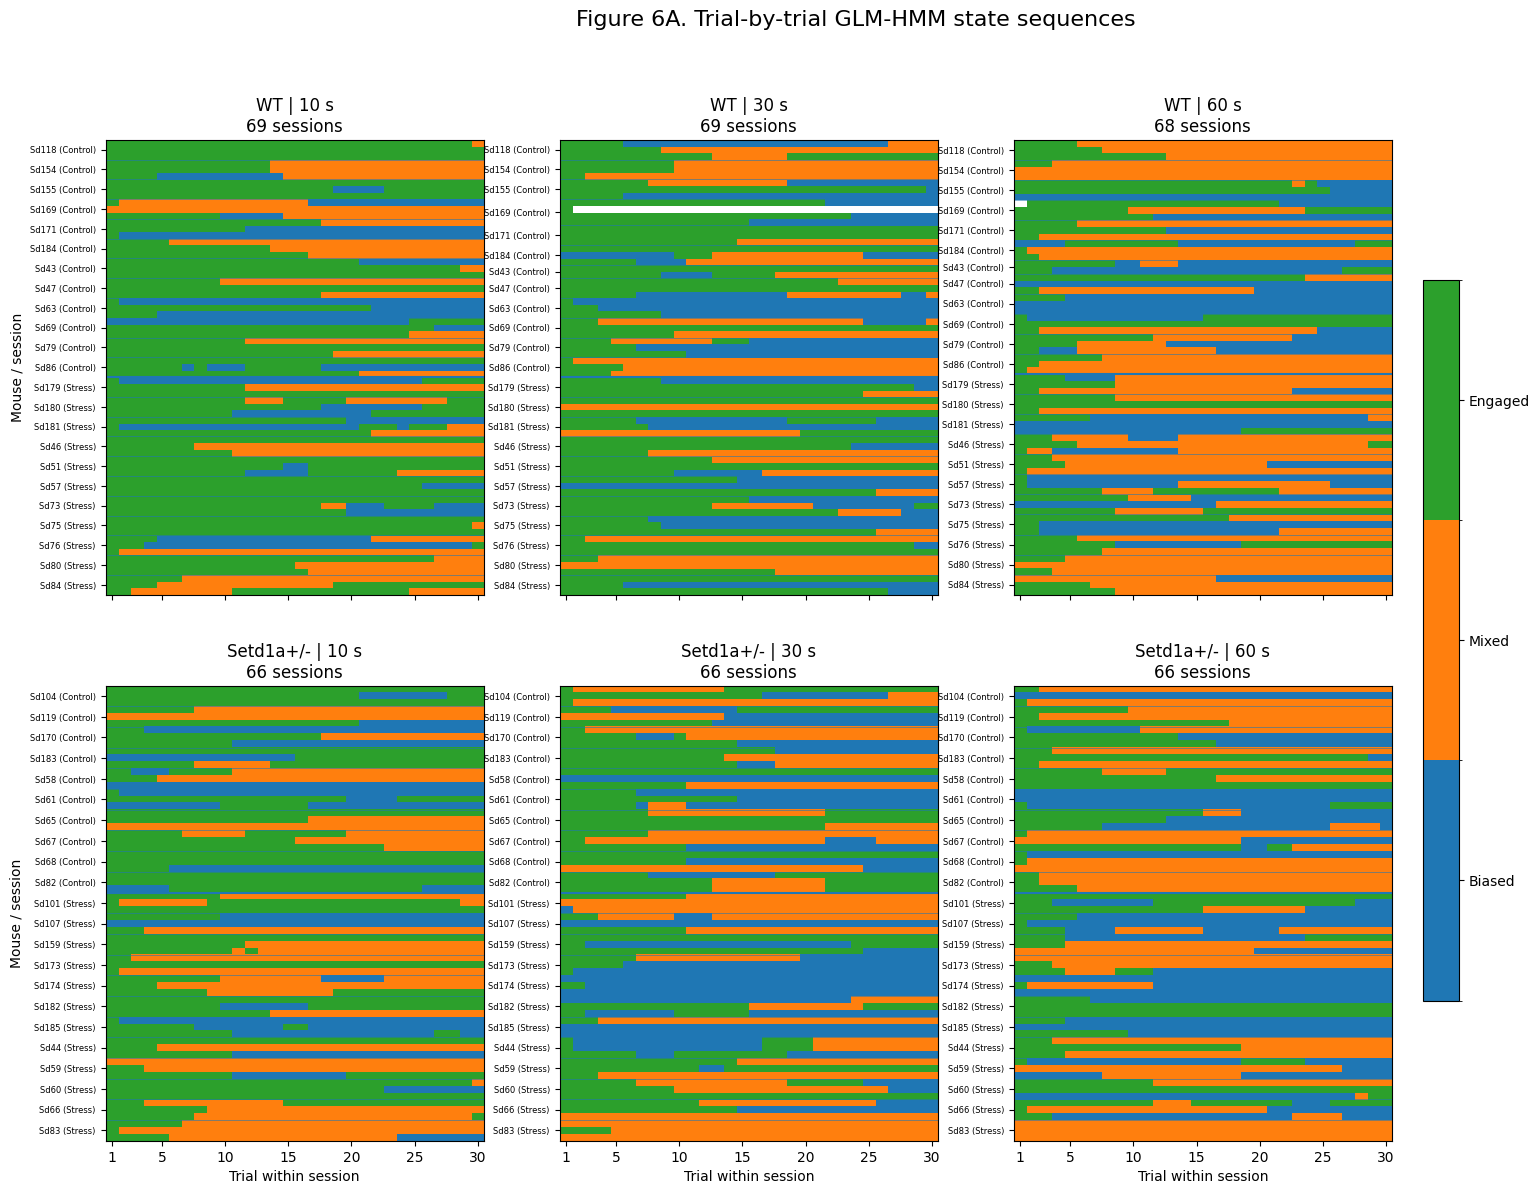

In [ ]:
# ============================================================
# STEP 3
# Figure 6A
# Trial-by-trial GLM-HMM state sequences
#
# Rows:
#   WT
#   Setd1a+/-
#
# Columns:
#   10 s
#   30 s
#   60 s
#
# Each horizontal row = one 30-trial session
# X-axis = Trial 1-30
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm


# ------------------------------------------------------------
# 1. Convert state labels to numbers for plotting
# ------------------------------------------------------------

STATE_NUM = {
    "Biased": 0,
    "Mixed": 1,
    "Engaged": 2
}

plot_df["state_num"] = (
    plot_df["state_simple"]
    .map(STATE_NUM)
)


# Use standard matplotlib colors
default_colors = (
    plt.rcParams["axes.prop_cycle"]
    .by_key()["color"]
)

cmap = ListedColormap(
    default_colors[:3]
)

norm = BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5],
    cmap.N
)


# ------------------------------------------------------------
# 2. Function to create one raster panel
# ------------------------------------------------------------

def make_raster(data):

    # One row = one session
    # Sessions are grouped by stress, mouse, then session
    session_order = (
        data[
            [
                "stress",
                "mouse_id",
                "session_id"
            ]
        ]
        .drop_duplicates()
        .sort_values(
            [
                "stress",
                "mouse_id",
                "session_id"
            ]
        )
        .reset_index(drop=True)
    )

    session_order["row"] = np.arange(
        len(session_order)
    )


    temp = data.merge(
        session_order,
        on=[
            "stress",
            "mouse_id",
            "session_id"
        ],
        how="left"
    )


    # rows = sessions
    # columns = Trials 1-30
    matrix = np.full(
        (
            len(session_order),
            30
        ),
        np.nan
    )


    for _, r in temp.iterrows():

        row = int(r["row"])
        trial = int(r["trial_position"]) - 1

        matrix[
            row,
            trial
        ] = r["state_num"]


    return matrix, session_order


# ------------------------------------------------------------
# 3. Create 2 × 3 panels
# ------------------------------------------------------------

GENOTYPES = [
    "WT",
    "Setd1a+/-"
]

DELAYS = [
    10,
    30,
    60
]


fig, axes = plt.subplots(
    2,
    3,
    figsize=(20, 13),
    sharex=True
)


for i, genotype in enumerate(GENOTYPES):

    for j, delay in enumerate(DELAYS):

        ax = axes[i, j]


        # Select genotype + delay
        sub = plot_df[
            (
                plot_df["genotype"]
                == genotype
            )
            &
            (
                plot_df["delay_s"]
                == delay
            )
        ].copy()


        matrix, session_order = (
            make_raster(sub)
        )


        im = ax.imshow(
            matrix,
            aspect="auto",
            interpolation="nearest",
            cmap=cmap,
            norm=norm
        )


        # ----------------------------------------------------
        # Mouse boundaries
        # ----------------------------------------------------

        mouse_blocks = (
            session_order
            .groupby(
                [
                    "stress",
                    "mouse_id"
                ]
            )["row"]
            .agg(
                ["min", "max"]
            )
            .reset_index()
            .sort_values("min")
        )


        # thin line between mice
        for _, b in (
            mouse_blocks
            .iloc[1:]
            .iterrows()
        ):

            ax.axhline(
                b["min"] - 0.5,
                linewidth=0.4
            )


        # ----------------------------------------------------
        # Mouse labels at center of their session block
        # ----------------------------------------------------

        mouse_blocks["center"] = (
            mouse_blocks["min"]
            +
            mouse_blocks["max"]
        ) / 2


        mouse_labels = [
            f"{r['mouse_id']} ({r['stress']})"
            for _, r
            in mouse_blocks.iterrows()
        ]


        ax.set_yticks(
            mouse_blocks["center"]
        )

        ax.set_yticklabels(
            mouse_labels,
            fontsize=6
        )


        # ----------------------------------------------------
        # Stronger boundary between Control and Stress
        # ----------------------------------------------------

        stress_blocks = (
            session_order
            .groupby("stress")["row"]
            .agg(
                ["min", "max"]
            )
            .sort_values("min")
        )


        if len(stress_blocks) > 1:

            for _, b in (
                stress_blocks
                .iloc[1:]
                .iterrows()
            ):

                ax.axhline(
                    b["min"] - 0.5,
                    linewidth=1.5
                )


        # ----------------------------------------------------
        # Formatting
        # ----------------------------------------------------

        ax.set_title(
            f"{genotype} | {delay} s\n"
            f"{len(session_order)} sessions"
        )


        ax.set_xticks(
            [
                0,
                4,
                9,
                14,
                19,
                24,
                29
            ]
        )

        ax.set_xticklabels(
            [
                1,
                5,
                10,
                15,
                20,
                25,
                30
            ]
        )


        if i == 1:

            ax.set_xlabel(
                "Trial within session"
            )


        if j == 0:

            ax.set_ylabel(
                "Mouse / session"
            )


# ------------------------------------------------------------
# 4. State legend
# ------------------------------------------------------------

cbar = fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    ticks=[
        0,
        1,
        2
    ],
    shrink=0.72,
    pad=0.02
)

cbar.ax.set_yticklabels(
    [
        "Biased",
        "Mixed",
        "Engaged"
    ]
)


fig.suptitle(
    "Figure 6A. Trial-by-trial GLM-HMM state sequences",
    fontsize=16
)


# ------------------------------------------------------------
# 5. Save
# ------------------------------------------------------------

plt.savefig(
    OUT /
    "Figure6A_trial_by_trial_state_raster.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

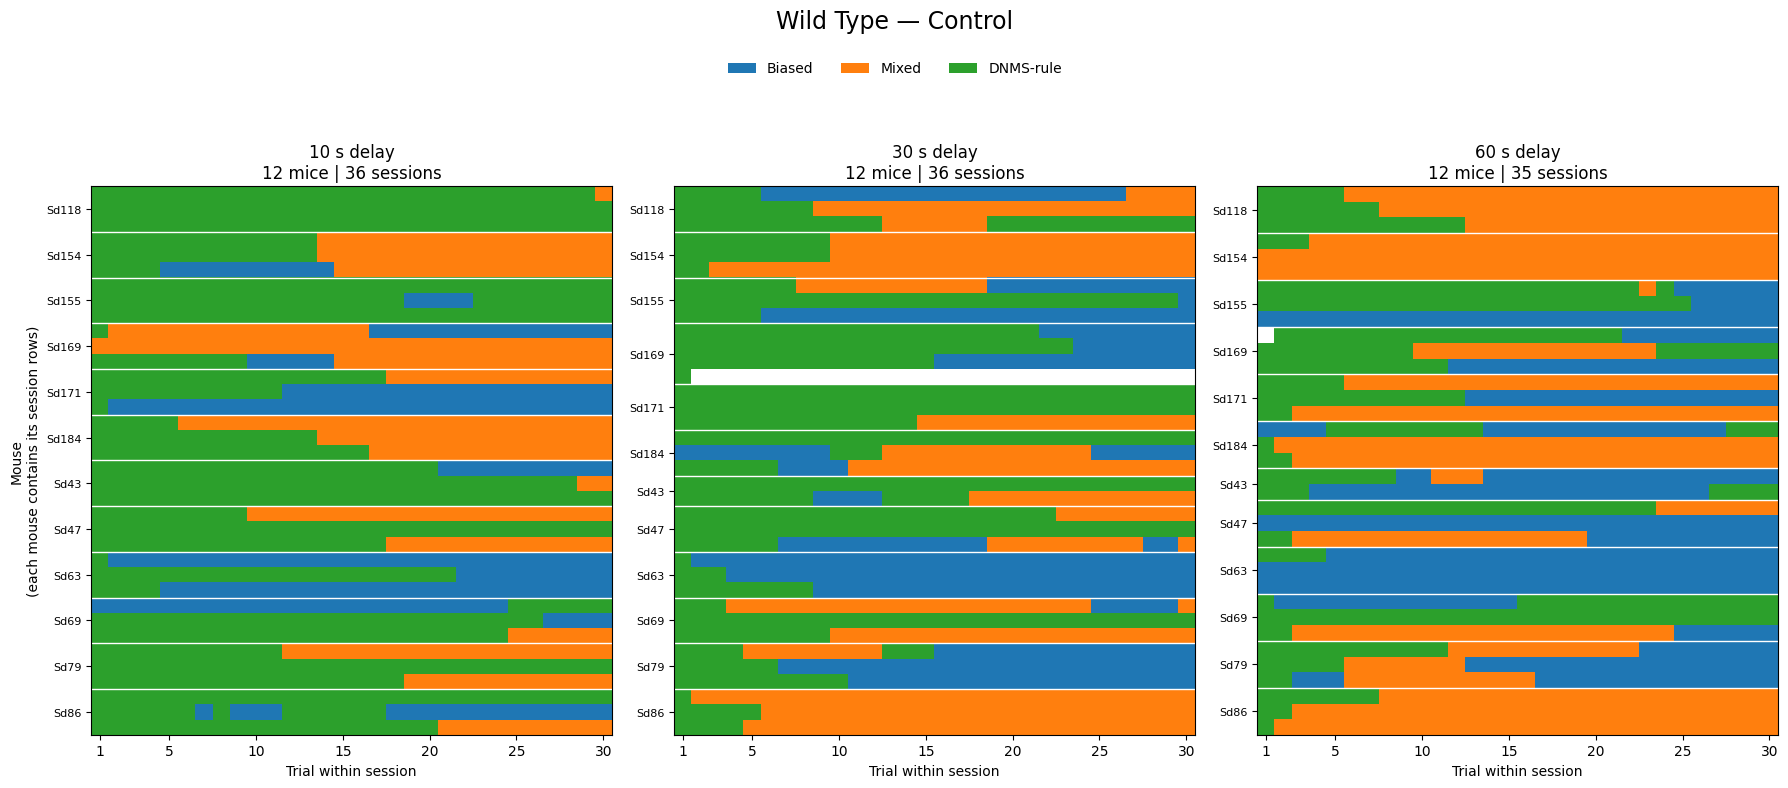

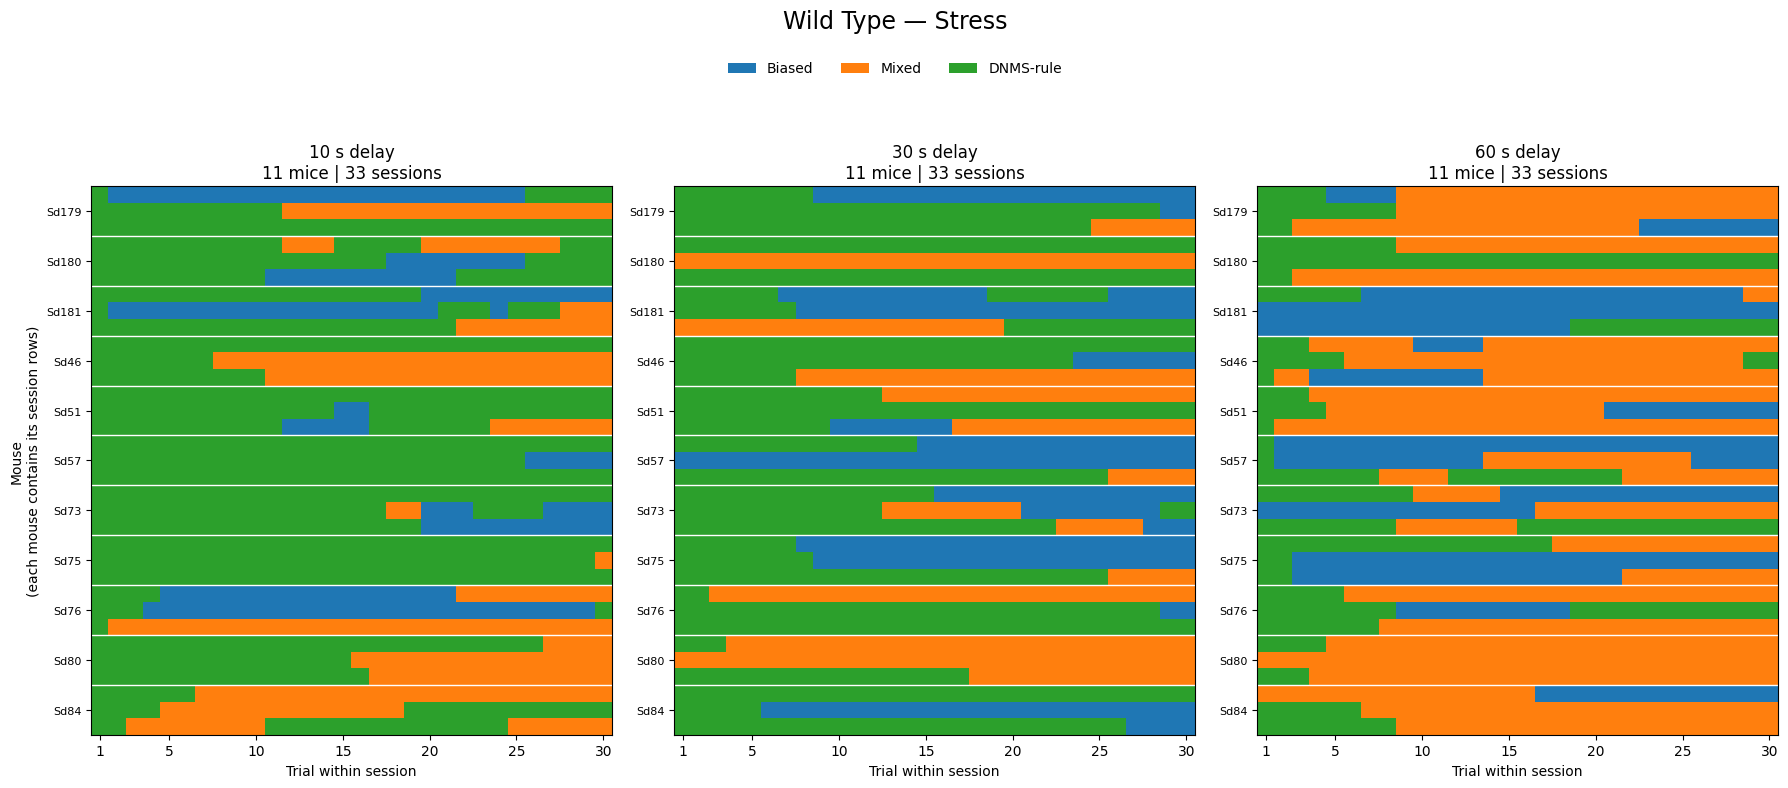

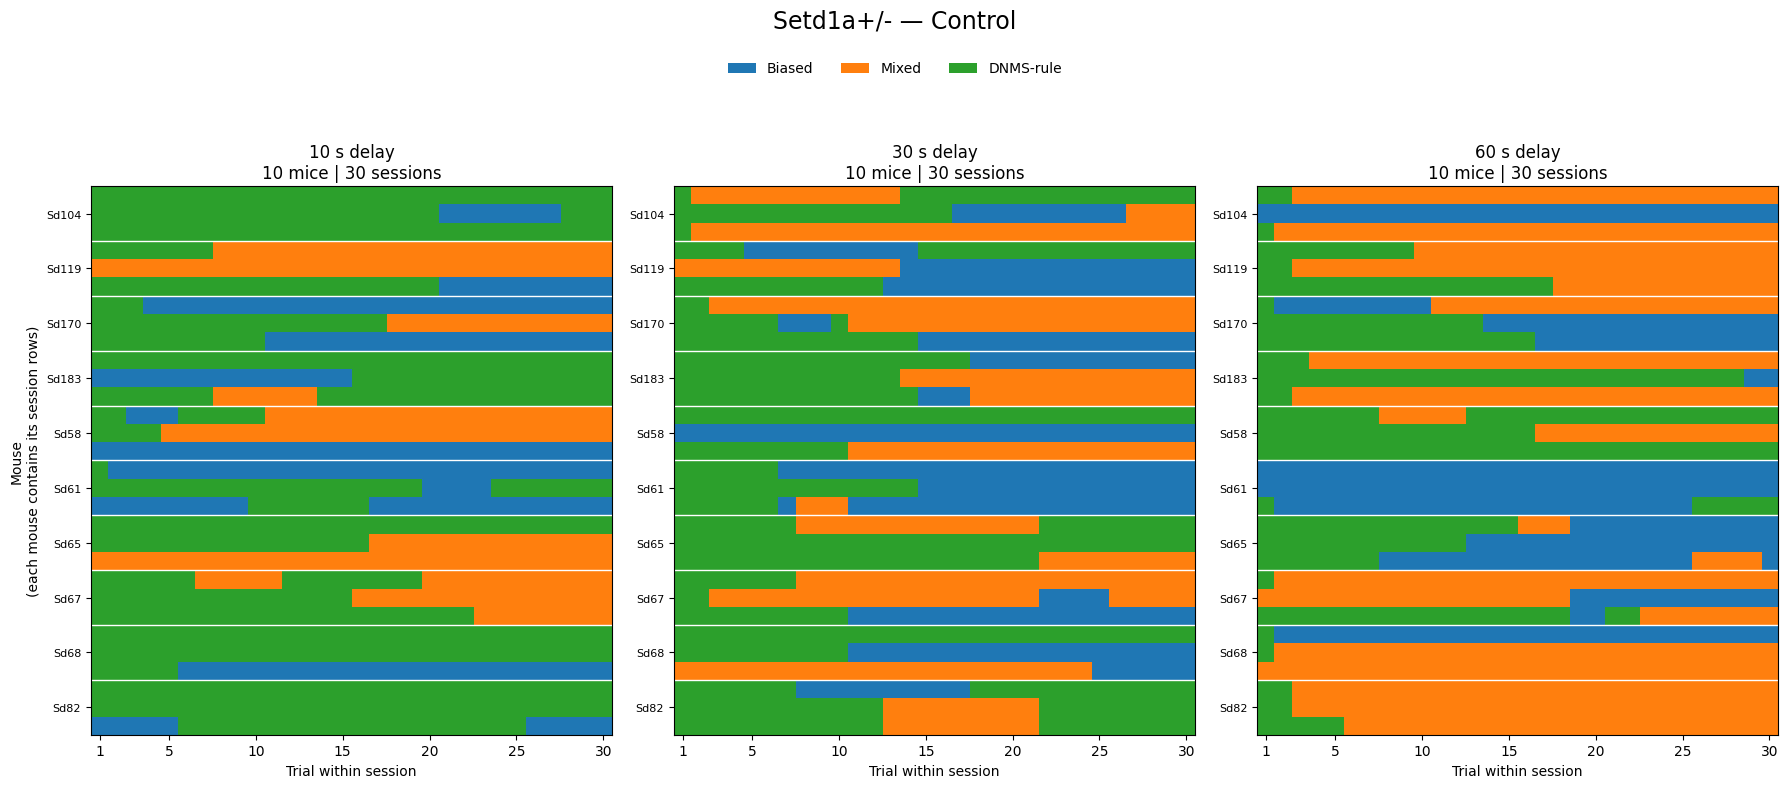

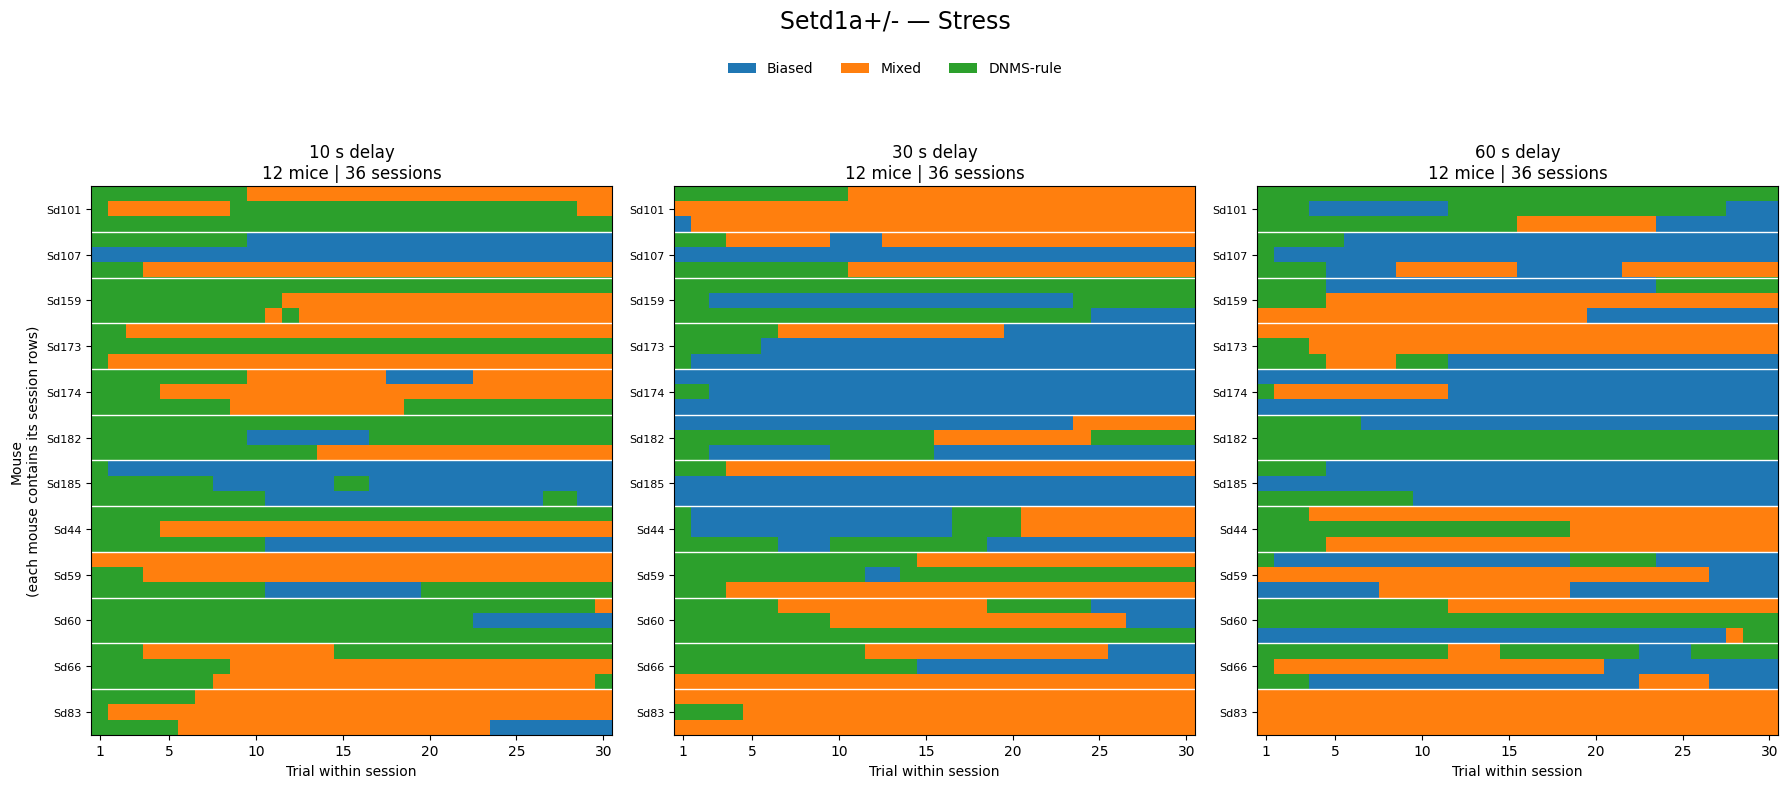

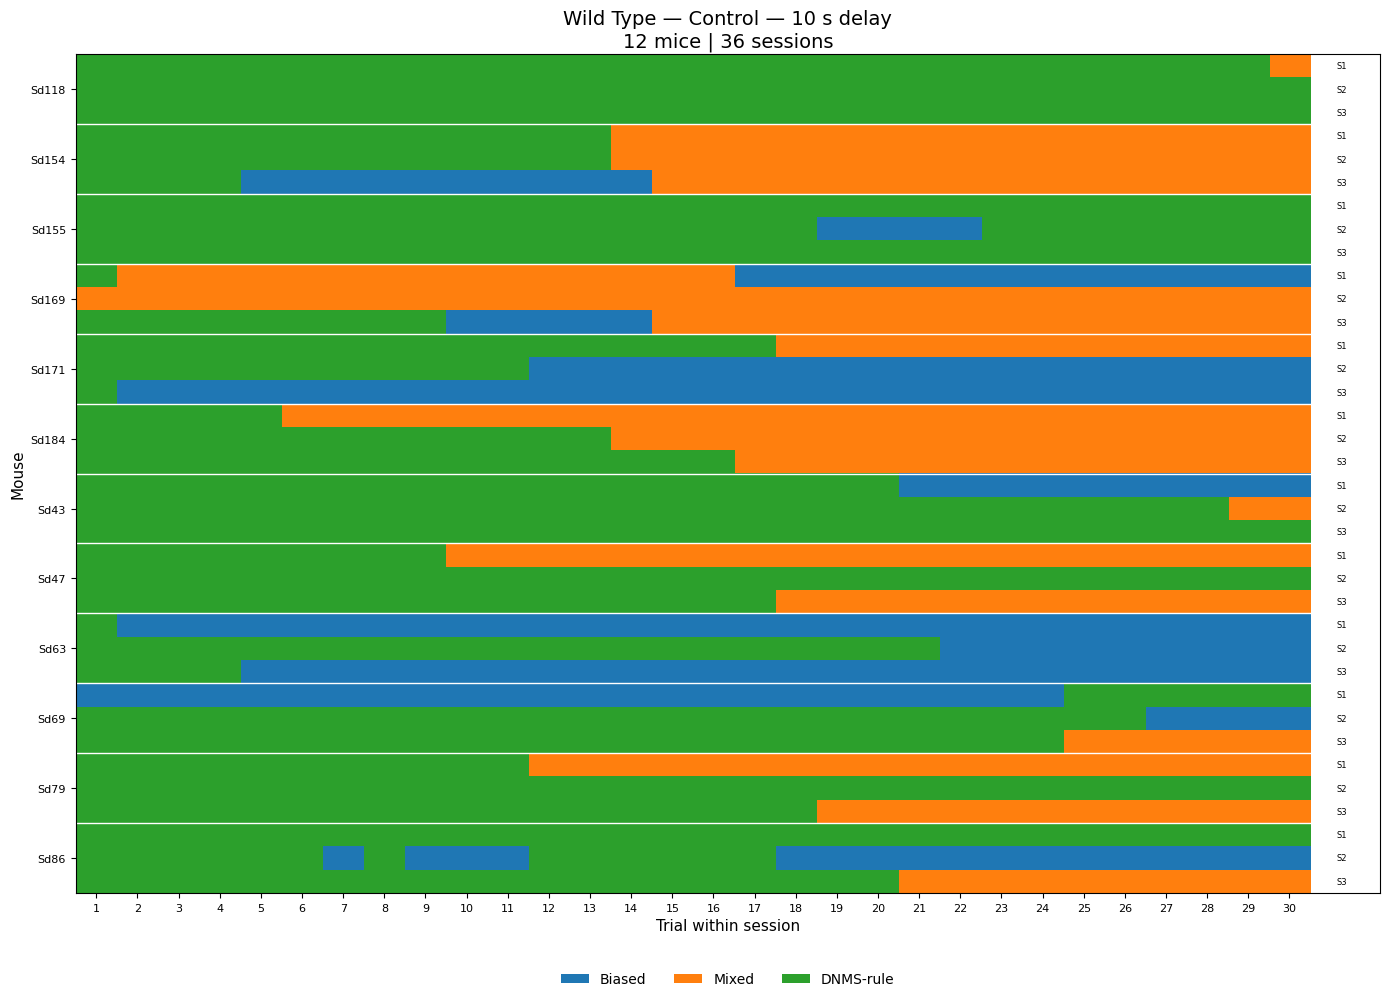

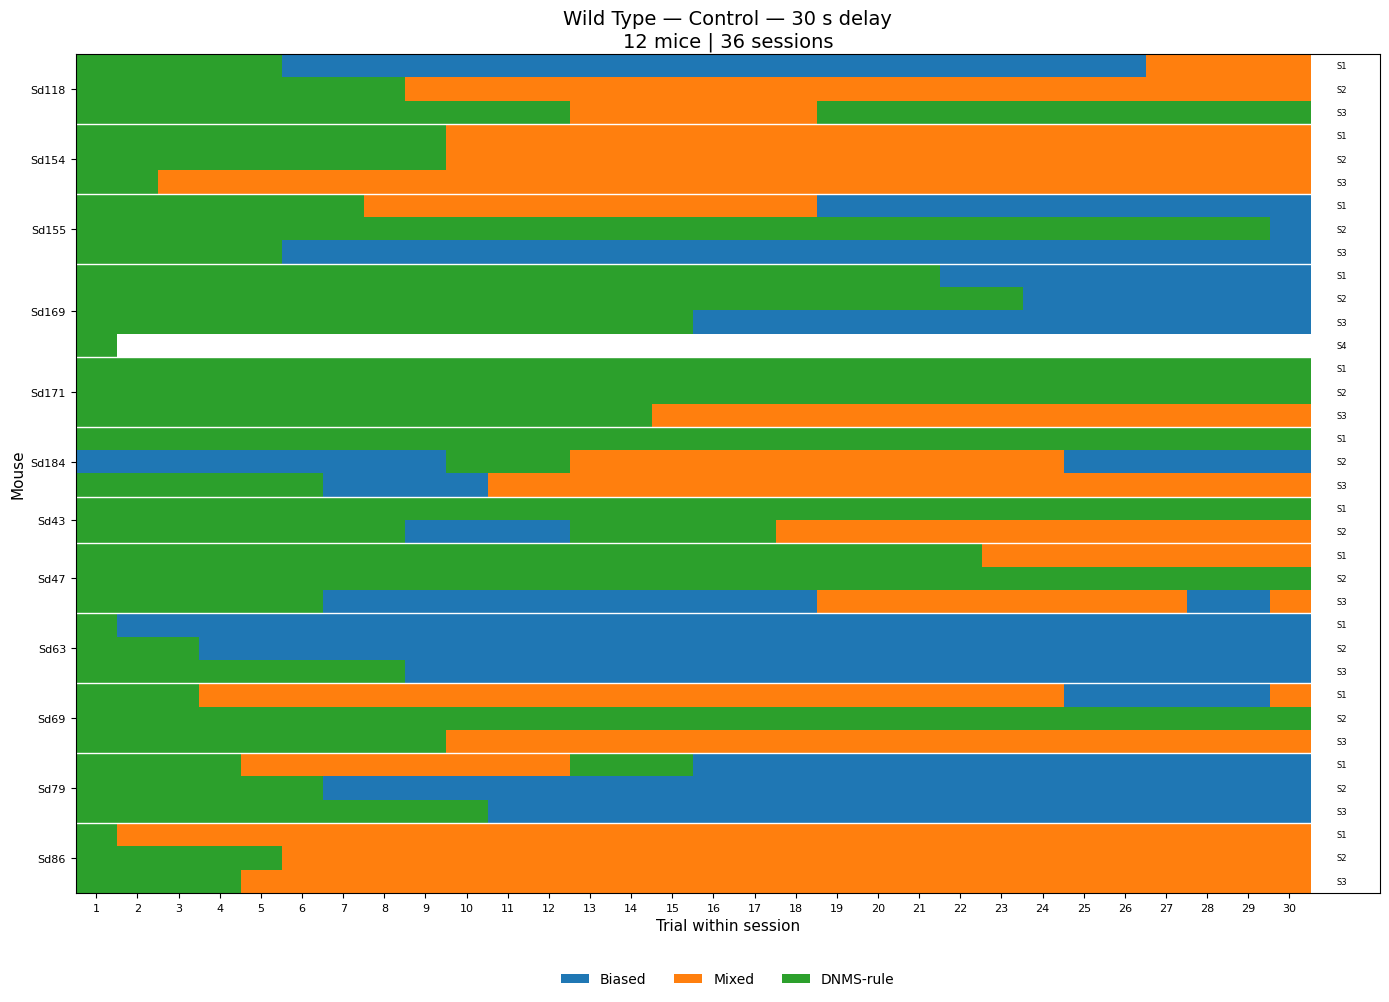

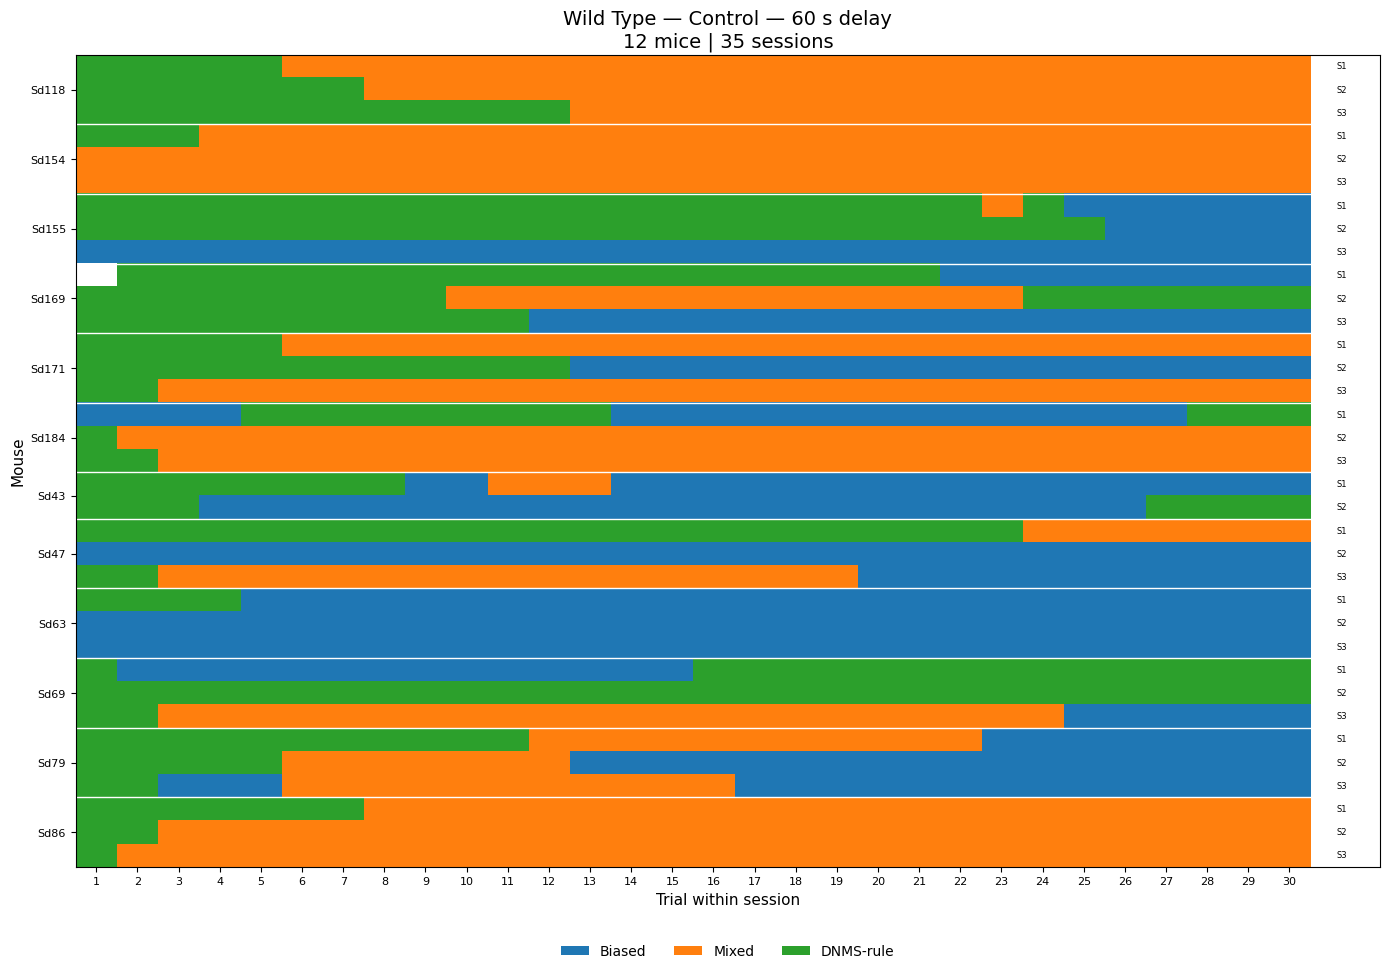

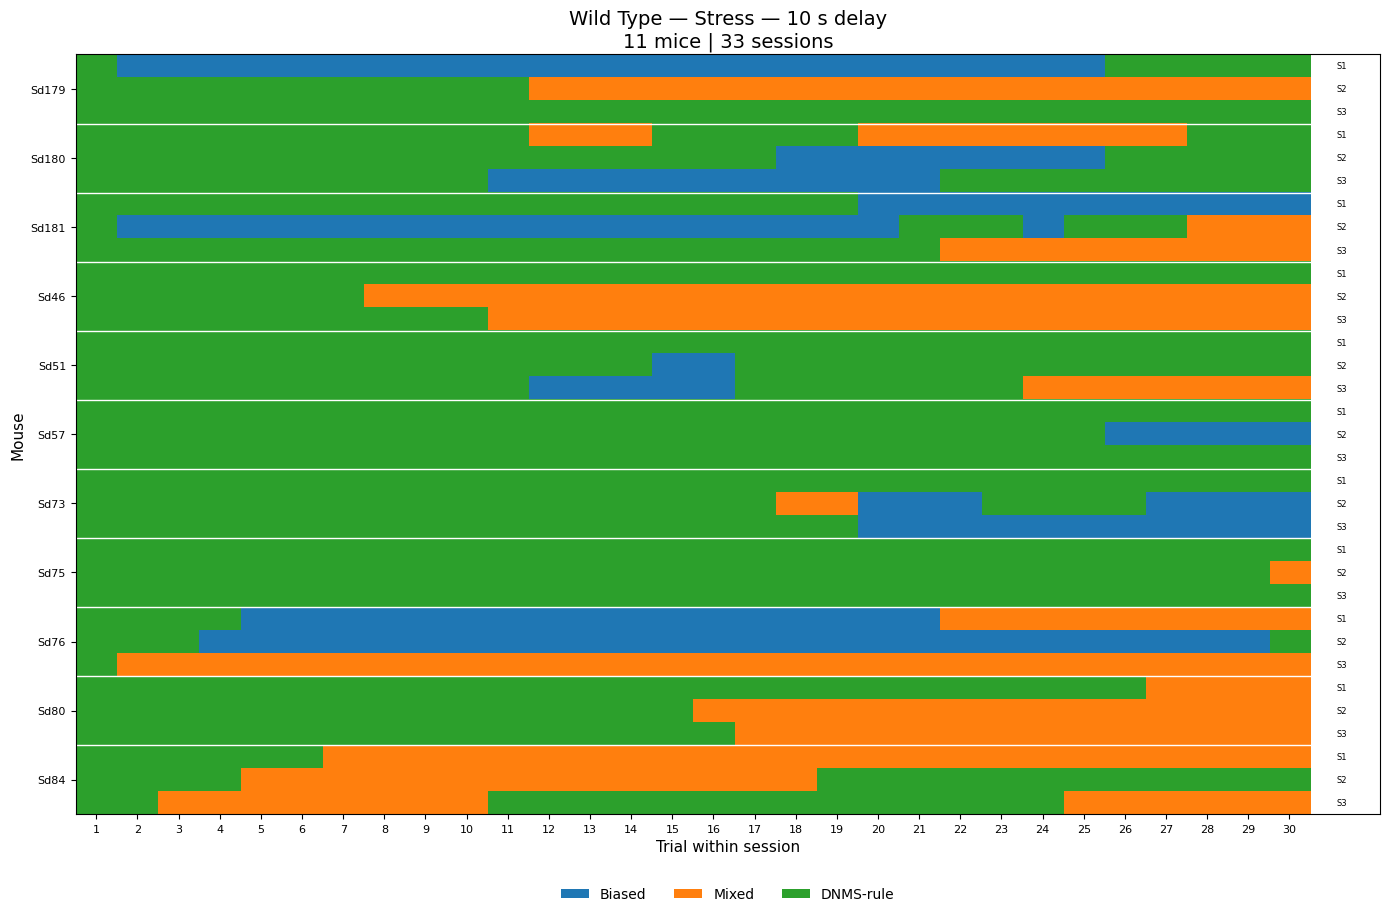

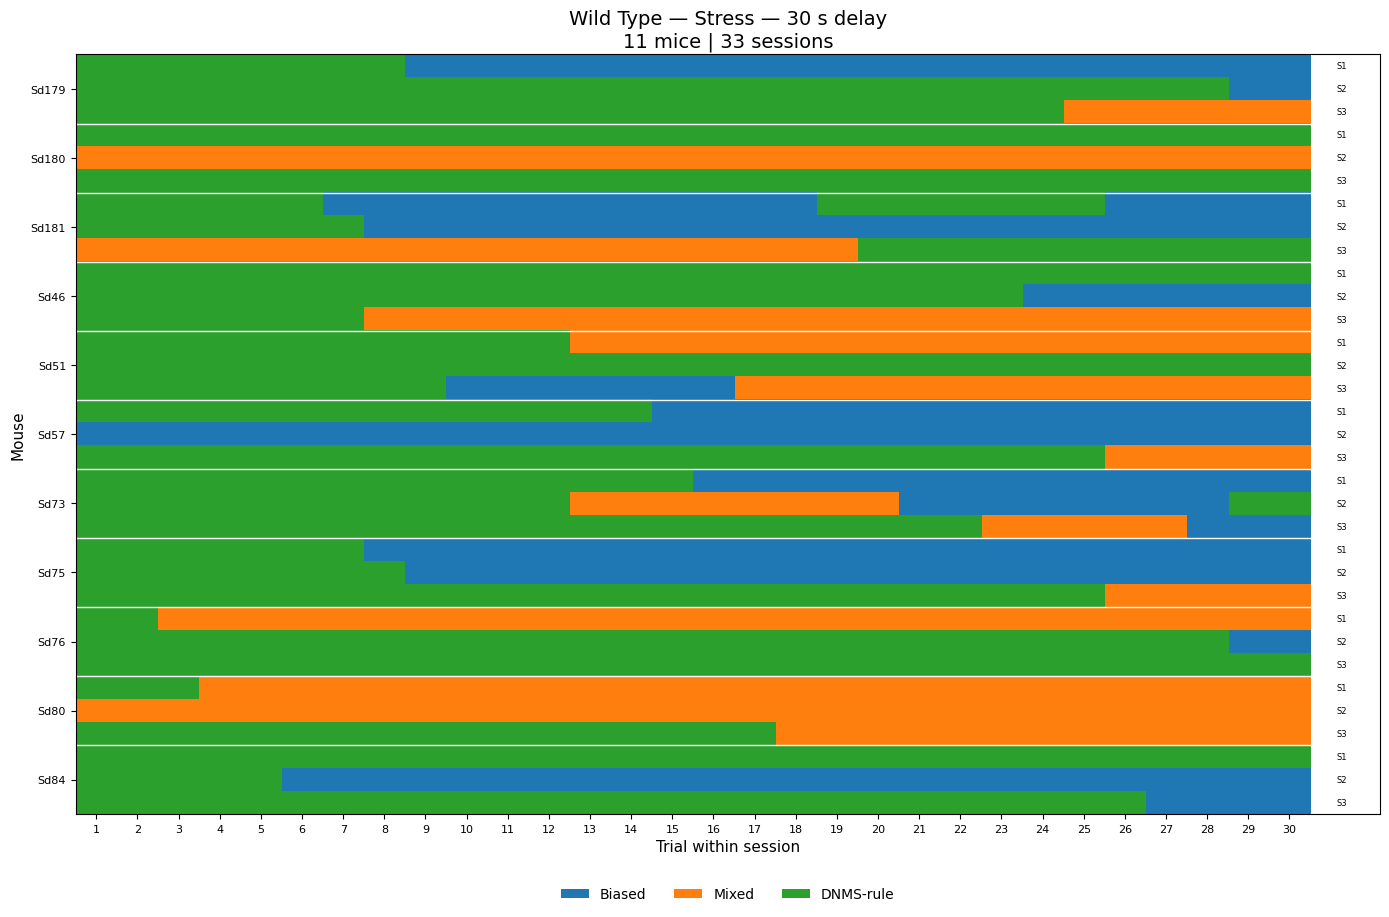

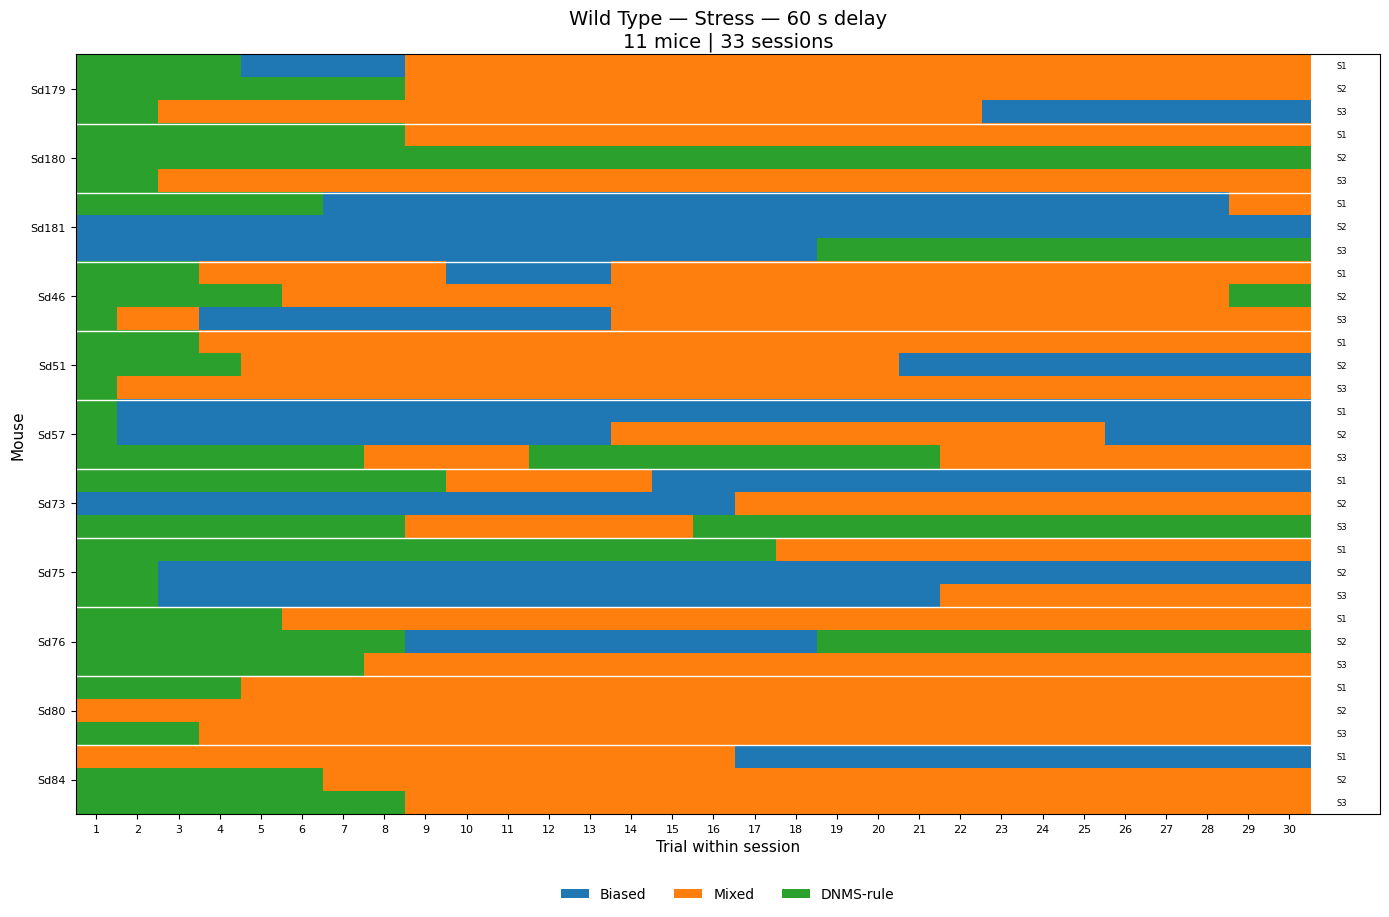

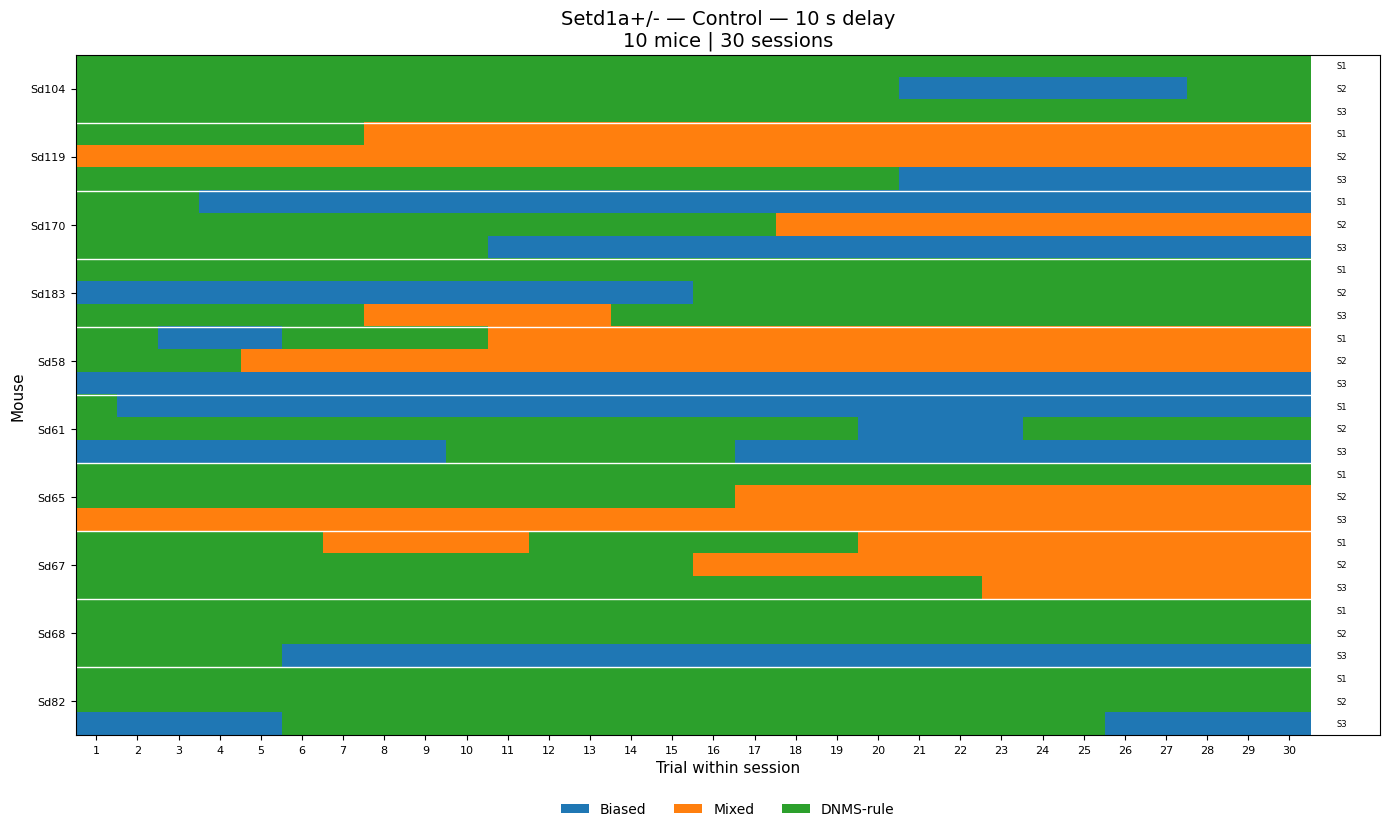

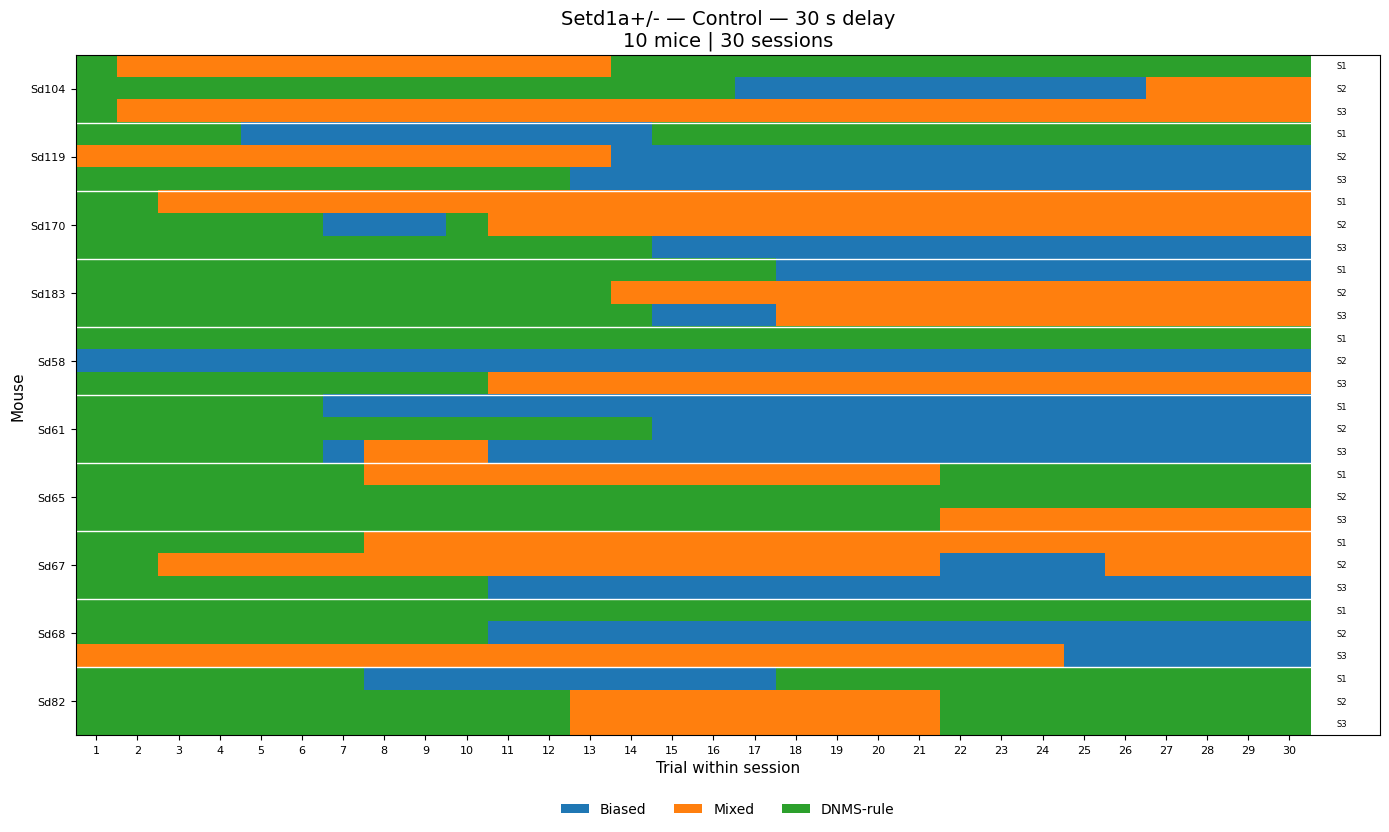

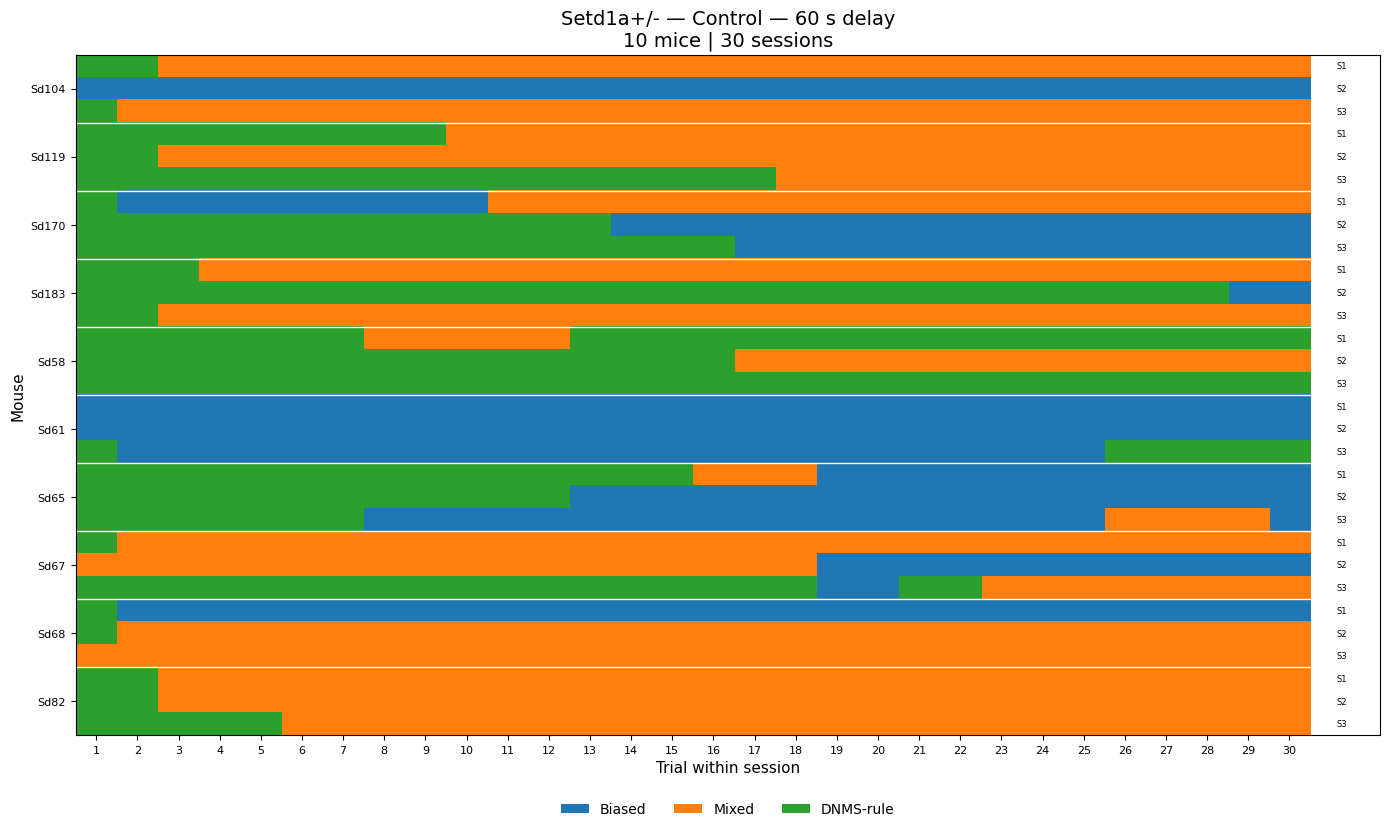

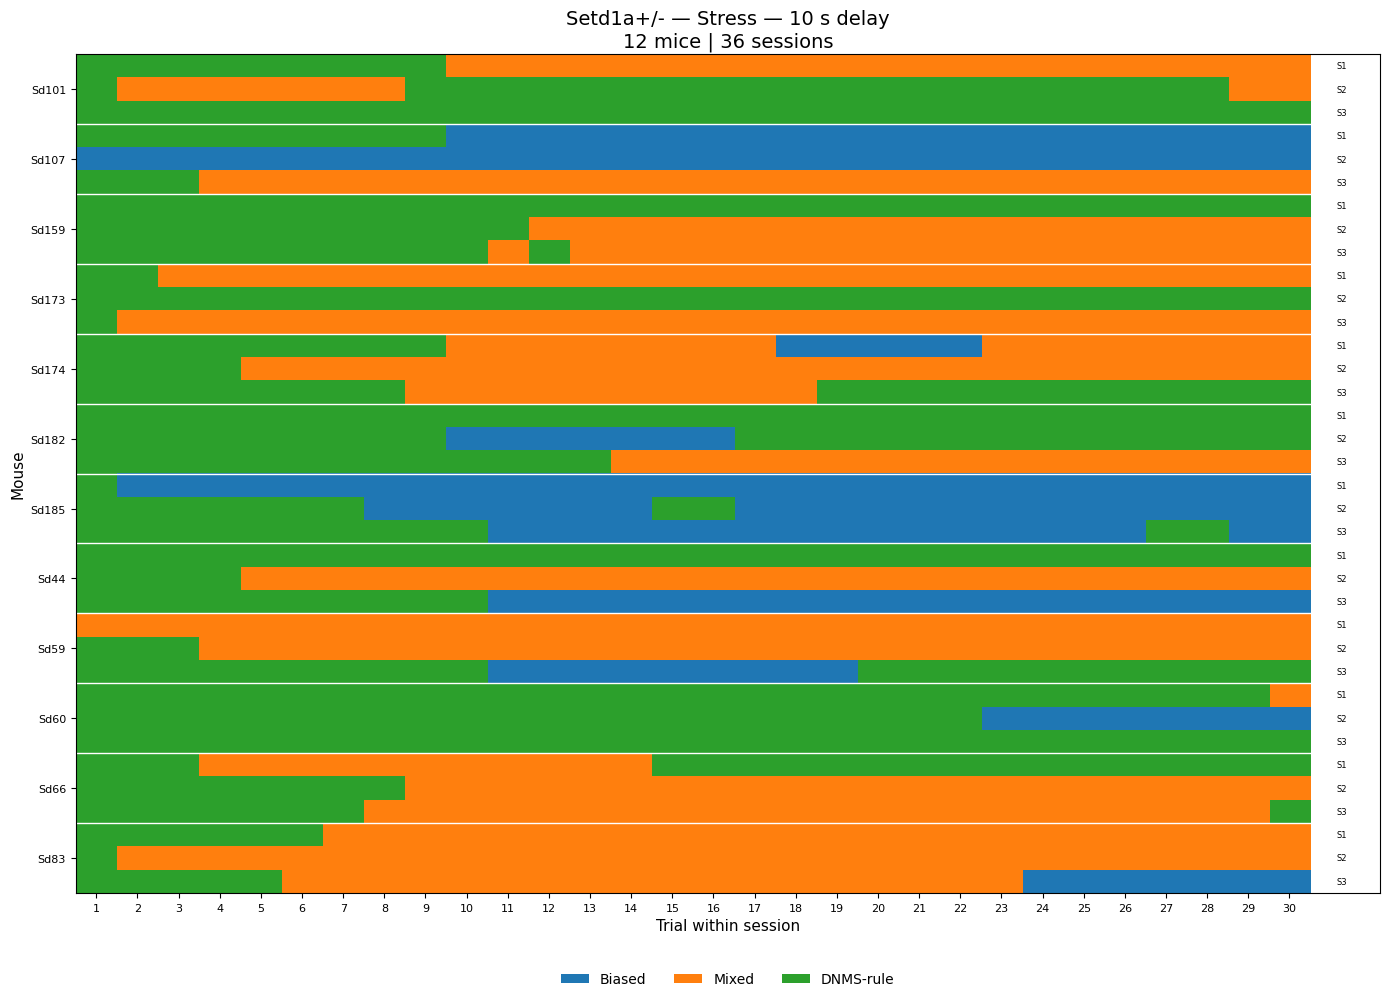

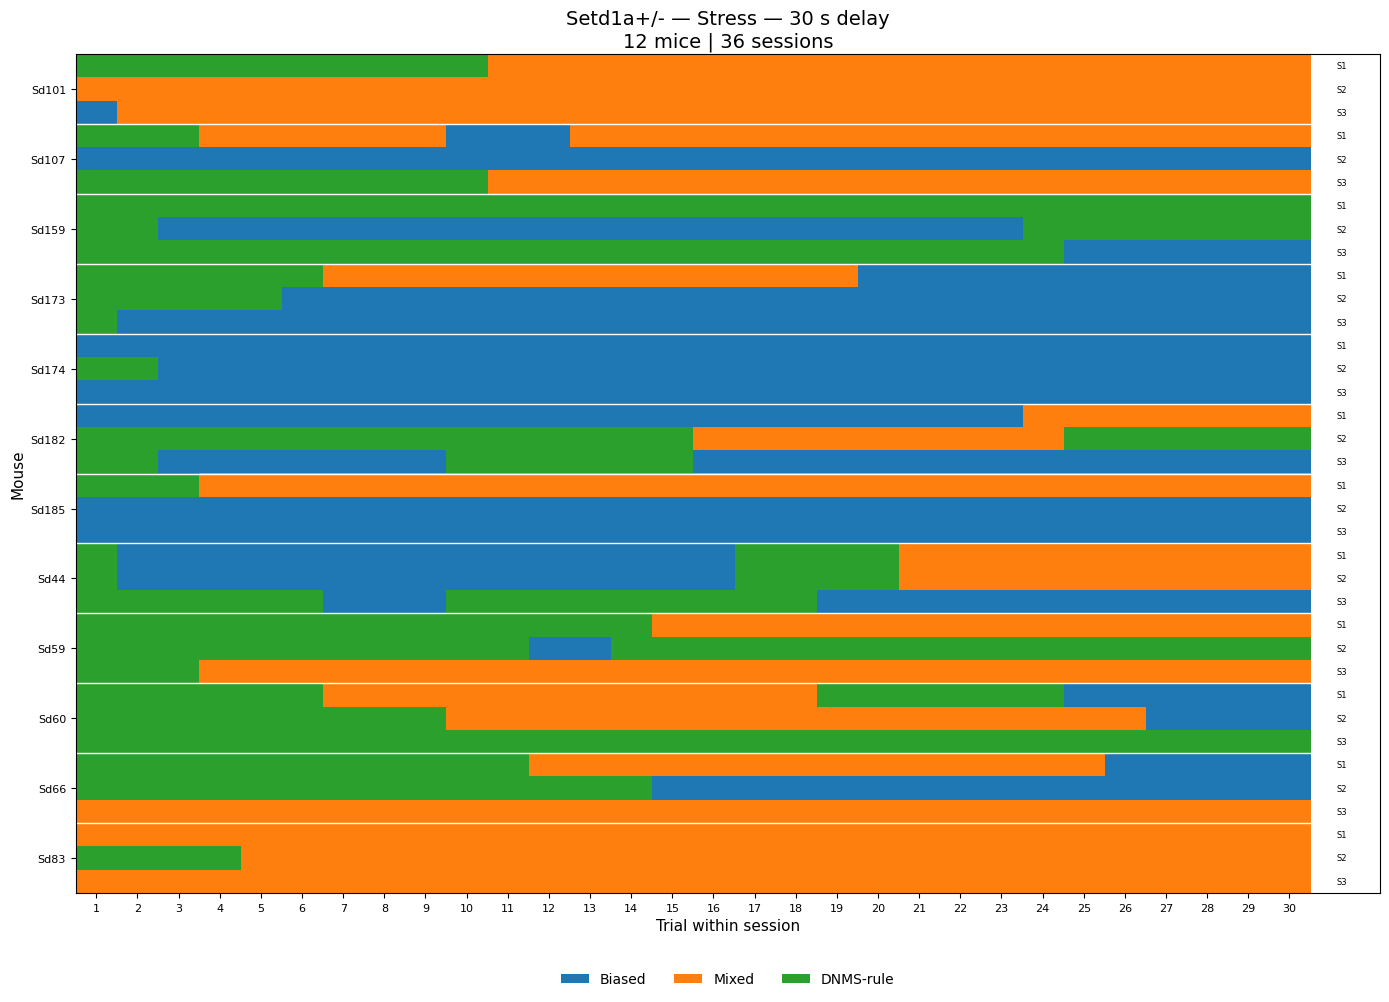

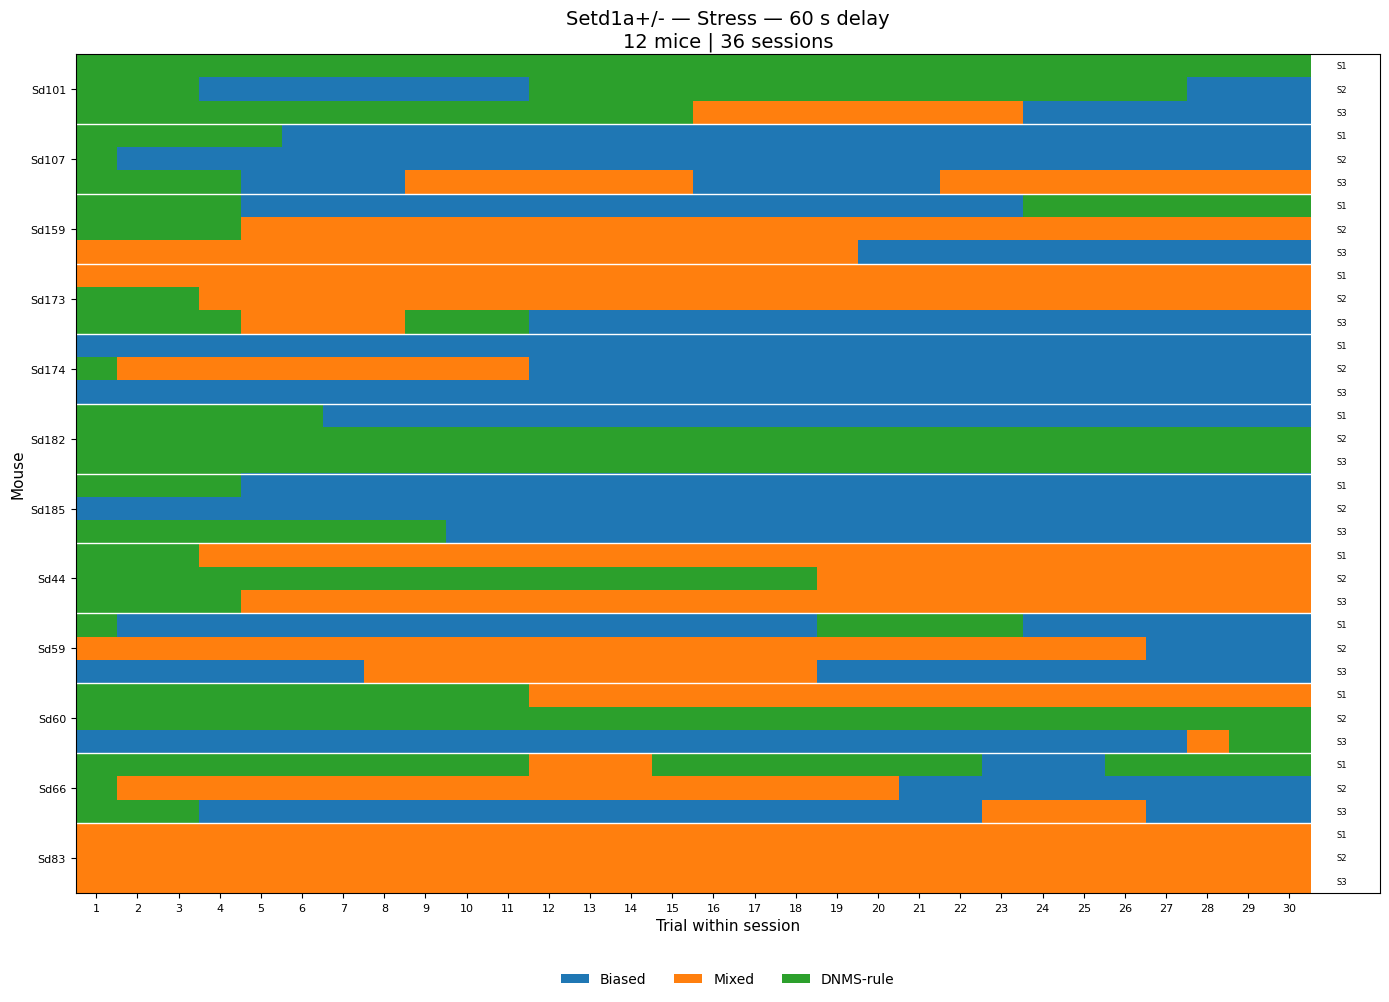


DONE
All clean raster figures saved to:
/content/state_dynamics_results/clean_rasters


In [ ]:
# ============================================================
# CLEANER TRIAL-BY-TRIAL STATE RASTERS
#
# Version A:
#   4 figures
#   WT-Control
#   WT-Stress
#   Setd1a-Control
#   Setd1a-Stress
#
#   Each figure:
#   10 s | 30 s | 60 s
#
# Version B:
#   12 detailed figures
#   one genotype × stress × delay per figure
#
# Each mouse usually has 3 session rows.
# Mouse name is shown only once at the center of its block.
# ============================================================

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch


# ============================================================
# 0. OUTPUT DIRECTORY
# ============================================================

OUT_CLEAN = Path(
    "/content/state_dynamics_results/clean_rasters"
)

OUT_CLEAN.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 1. STATE SETUP
# ============================================================

# NOTE:
# Internally we keep your current state_simple labels:
# Biased / Mixed / Engaged
#
# For display, I recommend "DNMS-rule" instead of "Engaged"
# because this is more directly supported by the GLM weights.

STATE_NUM = {
    "Biased": 0,
    "Mixed": 1,
    "Engaged": 2
}

DISPLAY_STATE = {
    "Biased": "Biased",
    "Mixed": "Mixed",
    "Engaged": "DNMS-rule"
}


plot_df = plot_df.copy()

plot_df["state_num"] = (
    plot_df["state_simple"]
    .map(STATE_NUM)
)


# Keep same intuitive colors as your previous figure:
#
# blue   = Biased
# orange = Mixed
# green  = DNMS-rule

tab10 = plt.get_cmap("tab10")

STATE_COLORS = [
    tab10(0),   # Biased
    tab10(1),   # Mixed
    tab10(2)    # DNMS-rule
]

cmap = ListedColormap(
    STATE_COLORS
)

norm = BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5],
    cmap.N
)


legend_handles = [
    Patch(
        facecolor=STATE_COLORS[0],
        label="Biased"
    ),

    Patch(
        facecolor=STATE_COLORS[1],
        label="Mixed"
    ),

    Patch(
        facecolor=STATE_COLORS[2],
        label="DNMS-rule"
    )
]


# ============================================================
# 2. HELPER FUNCTION:
# BUILD SESSION MATRIX
# ============================================================

def build_session_matrix(data):
    """
    Each row = one actual 30-trial session.
    Rows grouped by mouse.
    """

    data = data.copy()

    # Order sessions by mouse, then session index if available
    sort_cols = ["mouse_id"]

    if "session_index" in data.columns:
        sort_cols.append("session_index")
    else:
        sort_cols.append("session_id")


    session_order = (
        data[
            list(dict.fromkeys(
                ["mouse_id", "session_id"] + sort_cols
            ))
        ]
        .drop_duplicates(
            ["mouse_id", "session_id"]
        )
        .sort_values(sort_cols)
        .reset_index(drop=True)
    )


    session_order["row"] = np.arange(
        len(session_order)
    )


    temp = data.merge(
        session_order[
            [
                "mouse_id",
                "session_id",
                "row"
            ]
        ],
        on=[
            "mouse_id",
            "session_id"
        ],
        how="left"
    )


    matrix = np.full(
        (
            len(session_order),
            30
        ),
        np.nan
    )


    for _, r in temp.iterrows():

        rr = int(
            r["row"]
        )

        tt = int(
            r["trial_position"]
        ) - 1

        if (
            0 <= tt < 30
            and
            pd.notna(
                r["state_num"]
            )
        ):

            matrix[
                rr,
                tt
            ] = r["state_num"]


    return matrix, session_order


# ============================================================
# 3. HELPER FUNCTION:
# FORMAT MOUSE BLOCKS
# ============================================================

def format_mouse_axis(
    ax,
    session_order,
    show_mouse_labels=True
):
    """
    Groups the 3 session rows from each mouse visually.
    """

    mouse_blocks = (
        session_order
        .groupby("mouse_id")["row"]
        .agg(
            ["min", "max", "count"]
        )
        .reset_index()
        .sort_values("min")
    )


    mouse_blocks["center"] = (
        mouse_blocks["min"]
        +
        mouse_blocks["max"]
    ) / 2


    # --------------------------------------
    # Strong line between different mice
    # --------------------------------------

    for _, b in (
        mouse_blocks
        .iloc[1:]
        .iterrows()
    ):

        ax.axhline(
            b["min"] - 0.5,
            linewidth=1.0,
            color="white"
        )


    # --------------------------------------
    # Mouse label only once
    # centered across its sessions
    # --------------------------------------

    if show_mouse_labels:

        ax.set_yticks(
            mouse_blocks["center"]
        )

        ax.set_yticklabels(
            mouse_blocks["mouse_id"],
            fontsize=8
        )

    else:

        ax.set_yticks([])


    return mouse_blocks


# ============================================================
# VERSION A
#
# FOUR CLEAN FIGURES
#
# Figure A1 = WT Control
# Figure A2 = WT Stress
# Figure A3 = Setd1a Control
# Figure A4 = Setd1a Stress
#
# Each figure has:
# 10 s | 30 s | 60 s
# ============================================================

GROUPS = [
    ("WT", "Control"),
    ("WT", "Stress"),
    ("Setd1a+/-", "Control"),
    ("Setd1a+/-", "Stress")
]

DELAYS = [
    10,
    30,
    60
]


for genotype, stress in GROUPS:

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 8),
        sharex=True
    )


    for j, delay in enumerate(DELAYS):

        ax = axes[j]


        sub = plot_df[
            (
                plot_df["genotype"]
                == genotype
            )
            &
            (
                plot_df["stress"]
                == stress
            )
            &
            (
                plot_df["delay_s"]
                == delay
            )
        ].copy()


        matrix, session_order = (
            build_session_matrix(sub)
        )


        im = ax.imshow(
            matrix,
            aspect="auto",
            interpolation="nearest",
            cmap=cmap,
            norm=norm
        )


        mouse_blocks = format_mouse_axis(
            ax,
            session_order,
            show_mouse_labels=True
        )


        n_mice = (
            session_order[
                "mouse_id"
            ]
            .nunique()
        )

        n_sessions = len(
            session_order
        )


        ax.set_title(
            f"{delay} s delay\n"
            f"{n_mice} mice | {n_sessions} sessions",
            fontsize=12
        )


        ax.set_xticks(
            [
                0,
                4,
                9,
                14,
                19,
                24,
                29
            ]
        )

        ax.set_xticklabels(
            [
                1,
                5,
                10,
                15,
                20,
                25,
                30
            ]
        )

        ax.set_xlabel(
            "Trial within session"
        )


        if j == 0:

            ax.set_ylabel(
                "Mouse\n(each mouse contains its session rows)"
            )


    # --------------------------------------------------------
    # Clean overall title
    # --------------------------------------------------------

    genotype_title = (
        "Wild Type"
        if genotype == "WT"
        else "Setd1a+/-"
    )


    fig.suptitle(
        f"{genotype_title} — {stress}",
        fontsize=17,
        y=0.98
    )


    # One shared legend
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(
            0.5,
            0.93
        ),
        ncol=3,
        frameon=False
    )


    fig.tight_layout(
        rect=[
            0,
            0,
            1,
            0.88
        ]
    )


    safe_genotype = (
        genotype
        .replace("+/-", "Het")
        .replace("/", "_")
    )


    filename = (
        f"Raster_{safe_genotype}_{stress}_"
        f"10_30_60s.png"
    )


    plt.savefig(
        OUT_CLEAN / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# VERSION B
#
# 12 INDIVIDUAL DETAILED FIGURES
#
# One figure for each:
#
# genotype × stress × delay
#
# Examples:
# WT Control 10 s
# WT Control 30 s
# WT Control 60 s
# ...
#
# Useful for examining exact mouse/session patterns.
# ============================================================

for genotype, stress in GROUPS:

    for delay in DELAYS:

        sub = plot_df[
            (
                plot_df["genotype"]
                == genotype
            )
            &
            (
                plot_df["stress"]
                == stress
            )
            &
            (
                plot_df["delay_s"]
                == delay
            )
        ].copy()


        matrix, session_order = (
            build_session_matrix(sub)
        )


        # Larger vertical space because this is
        # the detailed inspection figure

        fig_height = max(
            5,
            len(
                session_order
            ) * 0.28
        )


        fig, ax = plt.subplots(
            figsize=(
                14,
                fig_height
            )
        )


        im = ax.imshow(
            matrix,
            aspect="auto",
            interpolation="nearest",
            cmap=cmap,
            norm=norm
        )


        mouse_blocks = format_mouse_axis(
            ax,
            session_order,
            show_mouse_labels=True
        )


        # --------------------------------------
        # Add tiny session number labels
        # to the right side
        # --------------------------------------

        session_counts = (
            session_order
            .groupby("mouse_id")
            .cumcount()
            + 1
        )


        # Place S1/S2/S3 on far right
        for row_i, session_num in enumerate(
            session_counts
        ):

            ax.text(
                30.15,
                row_i,
                f"S{session_num}",
                va="center",
                fontsize=6
            )


        # --------------------------------------
        # Axis formatting
        # --------------------------------------

        ax.set_xticks(
            np.arange(30)
        )

        ax.set_xticklabels(
            np.arange(
                1,
                31
            ),
            fontsize=8
        )


        ax.set_xlabel(
            "Trial within session",
            fontsize=11
        )

        ax.set_ylabel(
            "Mouse",
            fontsize=11
        )


        genotype_title = (
            "Wild Type"
            if genotype == "WT"
            else "Setd1a+/-"
        )


        ax.set_title(
            f"{genotype_title} — {stress} — {delay} s delay\n"
            f"{session_order['mouse_id'].nunique()} mice | "
            f"{len(session_order)} sessions",
            fontsize=14
        )


        ax.legend(
            handles=legend_handles,
            loc="upper center",
            bbox_to_anchor=(
                0.5,
                -0.08
            ),
            ncol=3,
            frameon=False
        )


        # More room on right for S1/S2/S3
        ax.set_xlim(
            -0.5,
            31.2
        )


        plt.tight_layout()


        safe_genotype = (
            genotype
            .replace("+/-", "Het")
            .replace("/", "_")
        )


        filename = (
            f"Detailed_{safe_genotype}_"
            f"{stress}_{delay}s.png"
        )


        plt.savefig(
            OUT_CLEAN / filename,
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()


print("\n===================================")
print("DONE")
print("===================================")

print(
    "All clean raster figures saved to:"
)

print(
    OUT_CLEAN
)

Mouse-level data:


,genotype,stress,mouse_id,delay_s,trial_position,state,state_pct
0,Setd1a+/-,Control,Sd104,10,1,Engaged,100.0
1,Setd1a+/-,Control,Sd104,10,1,Mixed,0.0
2,Setd1a+/-,Control,Sd104,10,1,Biased,0.0
3,Setd1a+/-,Control,Sd104,10,2,Engaged,100.0
4,Setd1a+/-,Control,Sd104,10,2,Mixed,0.0



Group-level data:


,genotype,stress,delay_s,trial_position,state,mean,sem,n_mice
0,Setd1a+/-,Control,10,1,Biased,13.333333,5.443311,10
1,Setd1a+/-,Control,10,1,Engaged,80.000000,5.443311,10
2,Setd1a+/-,Control,10,1,Mixed,6.666667,4.444444,10
3,Setd1a+/-,Control,10,2,Biased,16.666667,7.453560,10
4,Setd1a+/-,Control,10,2,Engaged,76.666667,7.114582,10


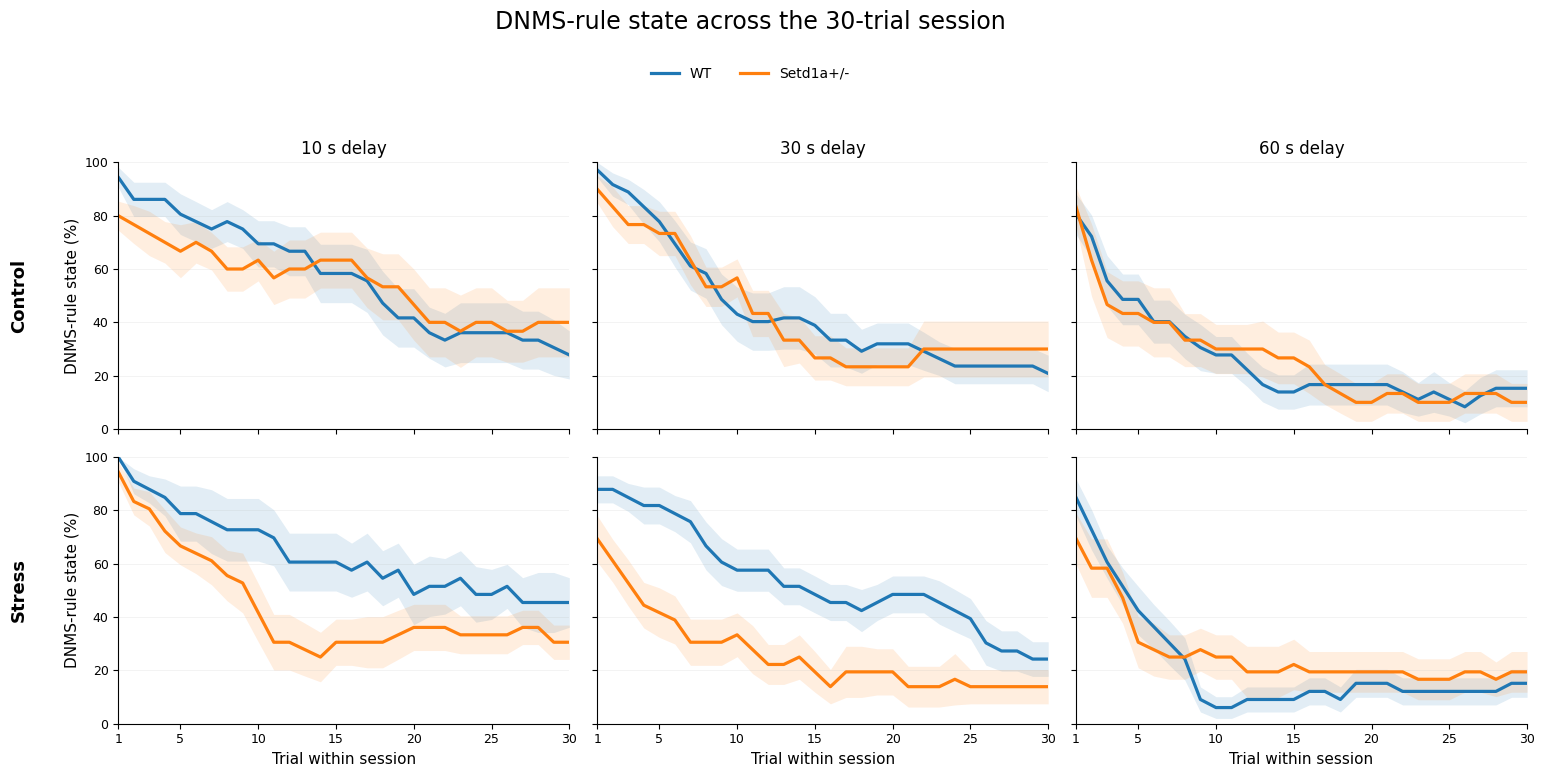

Saved: /content/state_dynamics_results/clean_line_figures/StateDynamics_DNMS-rule.png


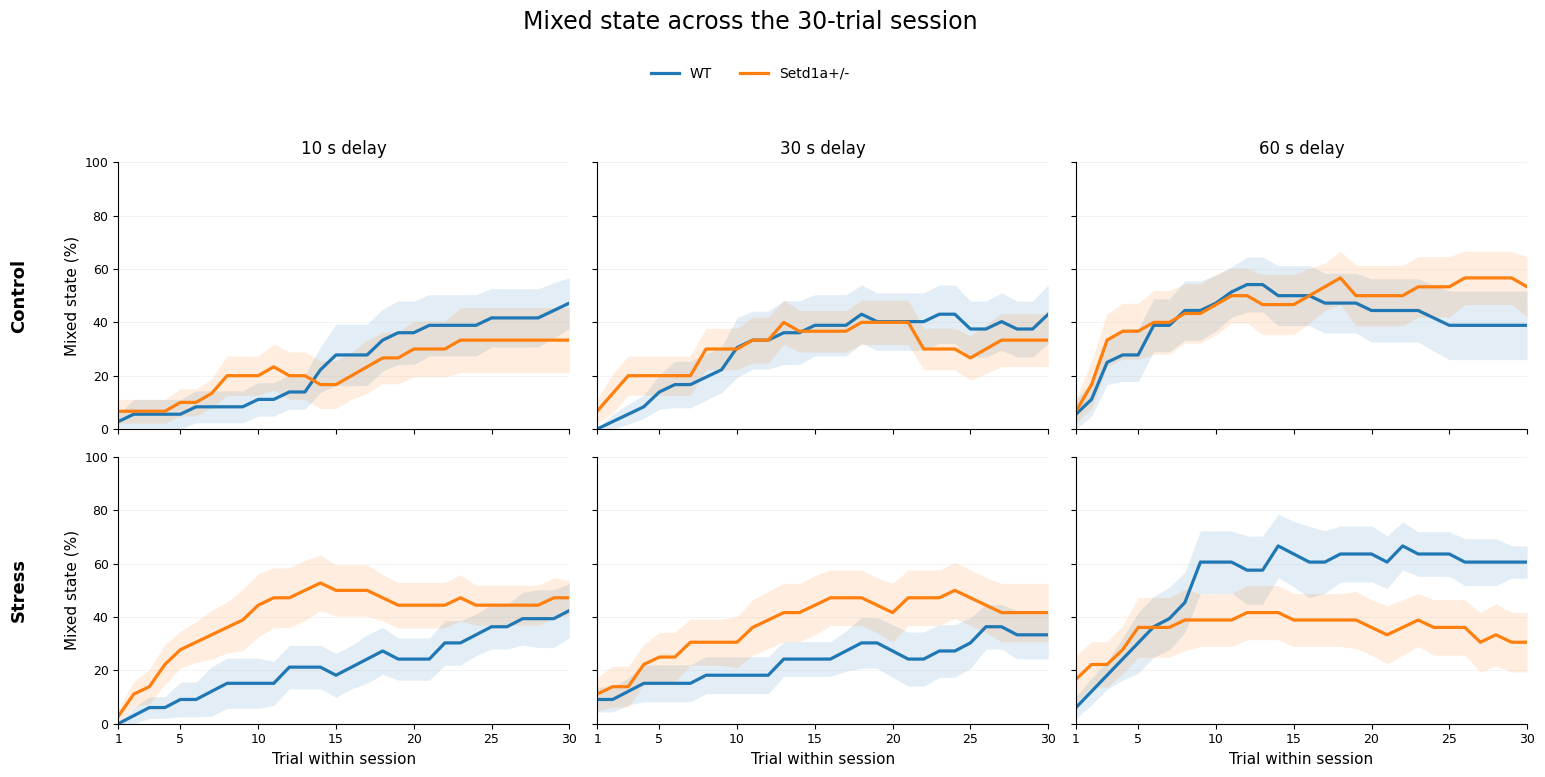

Saved: /content/state_dynamics_results/clean_line_figures/StateDynamics_Mixed.png


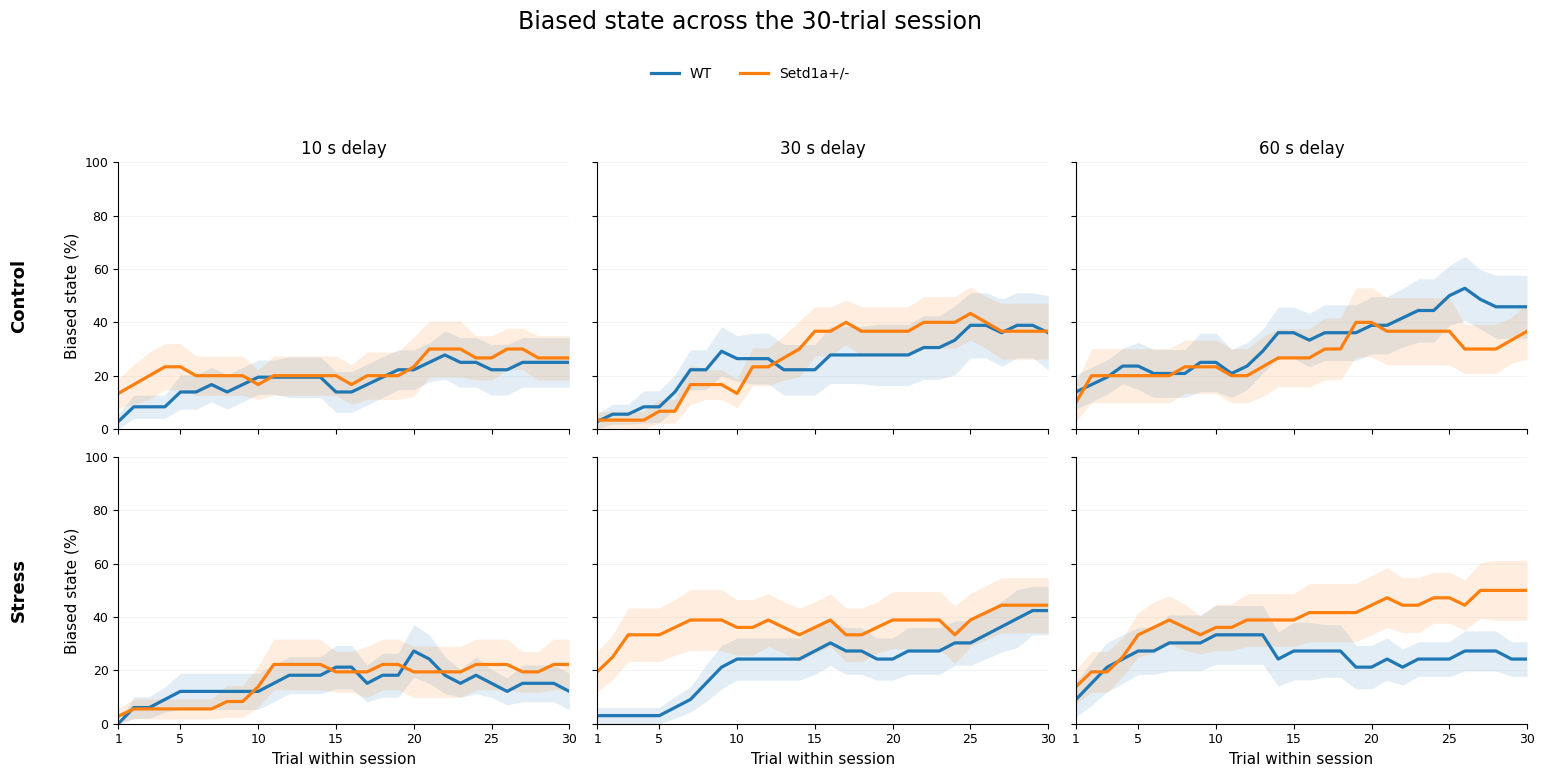

Saved: /content/state_dynamics_results/clean_line_figures/StateDynamics_Biased.png

DONE
Figures saved to:
/content/state_dynamics_results/clean_line_figures


In [ ]:
# ============================================================
# CLEAN STATE-SPECIFIC LINE FIGURES
#
# Creates 3 figures:
#
# 1. DNMS-rule
# 2. Mixed
# 3. Biased
#
# Layout of each figure:
#
#               10 s       30 s       60 s
# Control     WT vs Setd  WT vs Setd  WT vs Setd
# Stress      WT vs Setd  WT vs Setd  WT vs Setd
#
# Mouse-balanced:
# 1. Average repeated sessions within each mouse
# 2. Then average across mice
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 0. OUTPUT
# ============================================================

OUT_CLEAN_LINE = Path(
    "/content/state_dynamics_results/clean_line_figures"
)

OUT_CLEAN_LINE.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 1. SETTINGS
# ============================================================

GENOTYPES = [
    "WT",
    "Setd1a+/-"
]

STRESS_LEVELS = [
    "Control",
    "Stress"
]

DELAYS = [
    10,
    30,
    60
]

STATES = [
    "Engaged",
    "Mixed",
    "Biased"
]

STATE_DISPLAY = {
    "Engaged": "DNMS-rule",
    "Mixed": "Mixed",
    "Biased": "Biased"
}

GENOTYPE_DISPLAY = {
    "WT": "WT",
    "Setd1a+/-": "Setd1a+/-"
}


# Use standard matplotlib colors
default_colors = (
    plt.rcParams["axes.prop_cycle"]
    .by_key()["color"]
)

GENOTYPE_COLORS = {
    "WT": default_colors[0],
    "Setd1a+/-": default_colors[1]
}


# ============================================================
# 2. MOUSE-LEVEL STATE OCCUPANCY AT EACH TRIAL POSITION
#
# Example:
#
# Mouse A
# 60 s
# Trial 10
#
# Session 1 = DNMS-rule
# Session 2 = Mixed
# Session 3 = DNMS-rule
#
# Mouse A:
# DNMS-rule = 66.7%
# Mixed     = 33.3%
# Biased    = 0%
#
# Each mouse therefore contributes equally.
# ============================================================

mouse_rows = []


for (
    genotype,
    stress,
    mouse,
    delay
), mouse_data in (

    plot_df.groupby(
        [
            "genotype",
            "stress",
            "mouse_id",
            "delay_s"
        ]
    )
):

    for trial in range(1, 31):

        trial_data = mouse_data[
            mouse_data["trial_position"] == trial
        ]


        if len(trial_data) == 0:
            continue


        proportions = (
            trial_data["state_simple"]
            .value_counts(normalize=True)
            * 100
        )


        for state in STATES:

            mouse_rows.append(
                {
                    "genotype": genotype,
                    "stress": stress,
                    "mouse_id": mouse,
                    "delay_s": delay,
                    "trial_position": trial,
                    "state": state,

                    "state_pct": float(
                        proportions.get(
                            state,
                            0
                        )
                    )
                }
            )


mouse_trial_state = pd.DataFrame(
    mouse_rows
)


# ============================================================
# 3. GROUP SUMMARY
# ============================================================

group_trial_state = (
    mouse_trial_state
    .groupby(
        [
            "genotype",
            "stress",
            "delay_s",
            "trial_position",
            "state"
        ]
    )["state_pct"]
    .agg(
        mean="mean",
        sem="sem",
        n_mice="count"
    )
    .reset_index()
)


# Save numerical data
mouse_trial_state.to_csv(
    OUT_CLEAN_LINE /
    "mouse_level_state_dynamics.csv",
    index=False
)

group_trial_state.to_csv(
    OUT_CLEAN_LINE /
    "group_level_state_dynamics.csv",
    index=False
)


print("Mouse-level data:")
display(mouse_trial_state.head())

print("\nGroup-level data:")
display(group_trial_state.head())


# ============================================================
# 4. CLEAN MATPLOTLIB SETTINGS
# ============================================================

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9
    }
)


# ============================================================
# 5. FUNCTION TO DRAW ONE STATE
# ============================================================

def plot_one_state(state):

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(16, 8),
        sharex=True,
        sharey=True
    )


    # --------------------------------------------------------
    # Draw panels
    # --------------------------------------------------------

    for row_i, stress in enumerate(
        STRESS_LEVELS
    ):

        for col_i, delay in enumerate(
            DELAYS
        ):

            ax = axes[
                row_i,
                col_i
            ]


            for genotype in GENOTYPES:

                s = (
                    group_trial_state[
                        (
                            group_trial_state["state"]
                            == state
                        )
                        &
                        (
                            group_trial_state["stress"]
                            == stress
                        )
                        &
                        (
                            group_trial_state["delay_s"]
                            == delay
                        )
                        &
                        (
                            group_trial_state["genotype"]
                            == genotype
                        )
                    ]
                    .sort_values(
                        "trial_position"
                    )
                )


                if len(s) == 0:
                    continue


                x = (
                    s["trial_position"]
                    .to_numpy()
                )

                y = (
                    s["mean"]
                    .to_numpy()
                )

                sem = (
                    s["sem"]
                    .fillna(0)
                    .to_numpy()
                )


                # --------------------------------------------
                # Main trajectory
                # --------------------------------------------

                ax.plot(
                    x,
                    y,
                    linewidth=2.3,
                    label=GENOTYPE_DISPLAY[
                        genotype
                    ],
                    color=GENOTYPE_COLORS[
                        genotype
                    ]
                )


                # --------------------------------------------
                # SEM
                # --------------------------------------------

                lower = np.clip(
                    y - sem,
                    0,
                    100
                )

                upper = np.clip(
                    y + sem,
                    0,
                    100
                )


                ax.fill_between(
                    x,
                    lower,
                    upper,
                    alpha=0.13,
                    color=GENOTYPE_COLORS[
                        genotype
                    ],
                    linewidth=0
                )


            # ------------------------------------------------
            # Panel title = delay only
            # ------------------------------------------------

            if row_i == 0:

                ax.set_title(
                    f"{delay} s delay"
                )


            # ------------------------------------------------
            # Axes
            # ------------------------------------------------

            ax.set_xlim(
                1,
                30
            )

            ax.set_ylim(
                0,
                100
            )

            ax.set_xticks(
                [
                    1,
                    5,
                    10,
                    15,
                    20,
                    25,
                    30
                ]
            )

            ax.set_yticks(
                [
                    0,
                    20,
                    40,
                    60,
                    80,
                    100
                ]
            )


            # only horizontal grid
            ax.grid(
                axis="y",
                alpha=0.15,
                linewidth=0.7
            )


            # cleaner borders
            ax.spines["top"].set_visible(
                False
            )

            ax.spines["right"].set_visible(
                False
            )


            # ------------------------------------------------
            # X-axis labels only bottom row
            # ------------------------------------------------

            if row_i == 1:

                ax.set_xlabel(
                    "Trial within session"
                )


            # ------------------------------------------------
            # Y-axis label only first column
            # ------------------------------------------------

            if col_i == 0:

                ax.set_ylabel(
                    f"{STATE_DISPLAY[state]} state (%)"
                )


    # ========================================================
    # Row labels:
    # CONTROL / STRESS
    # ========================================================

    axes[0, 0].text(
        -0.22,
        0.5,
        "Control",
        transform=axes[0, 0].transAxes,
        rotation=90,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold"
    )


    axes[1, 0].text(
        -0.22,
        0.5,
        "Stress",
        transform=axes[1, 0].transAxes,
        rotation=90,
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold"
    )


    # ========================================================
    # Single legend for whole figure
    # ========================================================

    handles, labels = (
        axes[0, 0]
        .get_legend_handles_labels()
    )


    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(
            0.5,
            0.94
        ),
        ncol=2,
        frameon=False
    )


    # ========================================================
    # Main title
    # ========================================================

    fig.suptitle(
        (
            f"{STATE_DISPLAY[state]} state "
            "across the 30-trial session"
        ),
        fontsize=17,
        y=0.995
    )


    fig.tight_layout(
        rect=[
            0.04,
            0.03,
            1,
            0.90
        ]
    )


    # ========================================================
    # Save
    # ========================================================

    safe_state = (
        STATE_DISPLAY[state]
        .replace(" ", "_")
        .replace("/", "_")
    )


    save_path = (
        OUT_CLEAN_LINE /
        f"StateDynamics_{safe_state}.png"
    )


    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    print(
        "Saved:",
        save_path
    )


# ============================================================
# 6. GENERATE THREE FIGURES
# ============================================================

for state in [
    "Engaged",
    "Mixed",
    "Biased"
]:

    plot_one_state(
        state
    )


print("\n==============================")
print("DONE")
print("==============================")

print(
    "Figures saved to:"
)

print(
    OUT_CLEAN_LINE
)

,genotype,stress,delay_s,mean_switch_rate,sem_switch_rate,mean_n_switches,sem_n_switches,n_mice
0,Setd1a+/-,Control,10,3.218391,0.536398,0.933333,0.155556,10
1,Setd1a+/-,Control,30,4.597701,0.568291,1.333333,0.164804,10
2,Setd1a+/-,Control,60,3.793103,0.486152,1.100000,0.140984,10
3,Setd1a+/-,Stress,10,4.214559,0.554022,1.222222,0.160666,12
4,Setd1a+/-,Stress,30,4.118774,0.780840,1.194444,0.226443,12
5,Setd1a+/-,Stress,60,4.310345,0.826504,1.250000,0.239686,12
6,WT,Control,10,3.352490,0.435127,0.972222,0.126187,12
7,WT,Control,30,4.358238,0.409196,1.243056,0.124561,12
8,WT,Control,60,4.358238,0.661575,1.263889,0.191857,12
9,WT,Stress,10,4.806688,0.817455,1.393939,0.237062,11


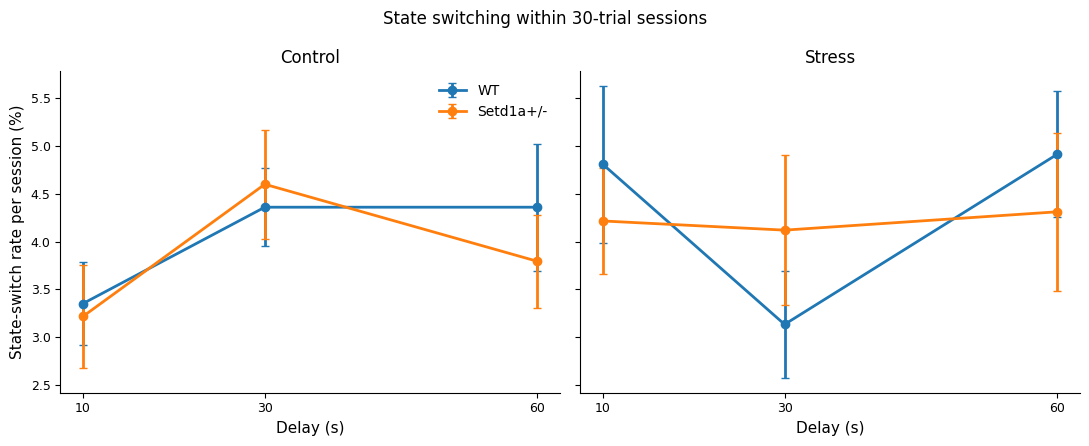

In [ ]:
# ============================================================
# STEP 4A
# STATE SWITCHING RATE
#
# How often does the decoded state change within a session?
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DYN = Path(
    "/content/state_dynamics_results/switch_dwell_analysis"
)
OUT_DYN.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. Sort trial sequence correctly
# ------------------------------------------------------------

seq_df = (
    plot_df
    .sort_values(
        [
            "mouse_id",
            "session_id",
            "trial_position"
        ]
    )
    .copy()
)


# ------------------------------------------------------------
# 2. Previous state
# ------------------------------------------------------------

seq_df["previous_state"] = (
    seq_df
    .groupby("session_id")["state_simple"]
    .shift(1)
)


# Trial 1 has no preceding trial
seq_df["state_switch"] = np.where(
    seq_df["previous_state"].isna(),
    np.nan,
    (
        seq_df["state_simple"]
        != seq_df["previous_state"]
    ).astype(float)
)


# ------------------------------------------------------------
# 3. Session-level switching
# ------------------------------------------------------------

session_switch = (
    seq_df
    .groupby(
        [
            "mouse_id",
            "session_id",
            "genotype",
            "stress",
            "delay_s"
        ]
    )
    .agg(
        n_switches=("state_switch", "sum"),
        n_possible=("state_switch", "count")
    )
    .reset_index()
)


session_switch["switch_rate_pct"] = (
    100
    * session_switch["n_switches"]
    / session_switch["n_possible"]
)


# ------------------------------------------------------------
# 4. Mouse-level mean
#
# First average sessions within each mouse.
# ------------------------------------------------------------

mouse_switch = (
    session_switch
    .groupby(
        [
            "mouse_id",
            "genotype",
            "stress",
            "delay_s"
        ]
    )
    .agg(
        mean_switches=("n_switches", "mean"),
        switch_rate_pct=("switch_rate_pct", "mean"),
        n_sessions=("session_id", "nunique")
    )
    .reset_index()
)


# ------------------------------------------------------------
# 5. Group summary across mice
# ------------------------------------------------------------

group_switch = (
    mouse_switch
    .groupby(
        [
            "genotype",
            "stress",
            "delay_s"
        ]
    )
    .agg(
        mean_switch_rate=("switch_rate_pct", "mean"),
        sem_switch_rate=("switch_rate_pct", "sem"),
        mean_n_switches=("mean_switches", "mean"),
        sem_n_switches=("mean_switches", "sem"),
        n_mice=("mouse_id", "nunique")
    )
    .reset_index()
)


display(group_switch)


# ------------------------------------------------------------
# 6. Plot
#
# Control top / Stress bottom
# WT vs Setd1a across delay
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
    sharey=True
)

for ax, stress in zip(
    axes,
    ["Control", "Stress"]
):

    temp = group_switch[
        group_switch["stress"] == stress
    ]

    for genotype in [
        "WT",
        "Setd1a+/-"
    ]:

        s = (
            temp[
                temp["genotype"] == genotype
            ]
            .sort_values("delay_s")
        )

        ax.errorbar(
            s["delay_s"],
            s["mean_switch_rate"],
            yerr=s["sem_switch_rate"],
            marker="o",
            linewidth=2,
            capsize=3,
            label=genotype
        )

    ax.set_title(stress)

    ax.set_xticks([10, 30, 60])
    ax.set_xlabel("Delay (s)")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

axes[0].set_ylabel(
    "State-switch rate per session (%)"
)

axes[0].legend(
    frameon=False
)

fig.suptitle(
    "State switching within 30-trial sessions"
)

fig.tight_layout()

plt.savefig(
    OUT_DYN / "Figure_state_switch_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


session_switch.to_csv(
    OUT_DYN / "session_level_switching.csv",
    index=False
)

mouse_switch.to_csv(
    OUT_DYN / "mouse_level_switching.csv",
    index=False
)

group_switch.to_csv(
    OUT_DYN / "group_level_switching.csv",
    index=False
)

In [ ]:
# ============================================================
# STEP 4B
# STATE DWELL DURATION
#
# Length of each continuous state episode
# ============================================================

DISPLAY_STATE = {
    "Engaged": "DNMS-rule",
    "Mixed": "Mixed",
    "Biased": "Left-biased"
}


# ------------------------------------------------------------
# 1. Identify continuous runs
# ------------------------------------------------------------

dwell_source = (
    seq_df
    .sort_values(
        [
            "session_id",
            "trial_position"
        ]
    )
    .copy()
)


# New run whenever state differs from previous trial
dwell_source["new_run"] = (
    dwell_source["state_simple"]
    !=
    dwell_source
    .groupby("session_id")["state_simple"]
    .shift(1)
).astype(int)


dwell_source["run_id"] = (
    dwell_source
    .groupby("session_id")["new_run"]
    .cumsum()
)


# ------------------------------------------------------------
# 2. One row = one continuous state episode
# ------------------------------------------------------------

runs = (
    dwell_source
    .groupby(
        [
            "mouse_id",
            "session_id",
            "genotype",
            "stress",
            "delay_s",
            "run_id"
        ]
    )
    .agg(
        state=("state_simple", "first"),
        start_trial=("trial_position", "min"),
        end_trial=("trial_position", "max"),
        dwell_trials=("trial_position", "size")
    )
    .reset_index()
)


runs["state_display"] = (
    runs["state"]
    .map(DISPLAY_STATE)
)


print("Number of state episodes:", len(runs))

display(runs.head(20))


# ------------------------------------------------------------
# 3. Session-level summary for each state
# ------------------------------------------------------------

session_dwell = (
    runs
    .groupby(
        [
            "mouse_id",
            "session_id",
            "genotype",
            "stress",
            "delay_s",
            "state"
        ]
    )
    .agg(
        mean_dwell=("dwell_trials", "mean"),
        max_dwell=("dwell_trials", "max"),
        n_runs=("run_id", "count")
    )
    .reset_index()
)


# ------------------------------------------------------------
# 4. Mouse-level summary
#
# Conditional on that state appearing in a session.
# ------------------------------------------------------------

mouse_dwell = (
    session_dwell
    .groupby(
        [
            "mouse_id",
            "genotype",
            "stress",
            "delay_s",
            "state"
        ]
    )
    .agg(
        mean_dwell=("mean_dwell", "mean"),
        mean_max_dwell=("max_dwell", "mean"),
        mean_n_runs=("n_runs", "mean"),
        n_sessions_with_state=("session_id", "nunique")
    )
    .reset_index()
)


# ------------------------------------------------------------
# 5. Group summary
# ------------------------------------------------------------

group_dwell = (
    mouse_dwell
    .groupby(
        [
            "genotype",
            "stress",
            "delay_s",
            "state"
        ]
    )
    .agg(
        mean_dwell=("mean_dwell", "mean"),
        sem_dwell=("mean_dwell", "sem"),
        mean_max_dwell=("mean_max_dwell", "mean"),
        sem_max_dwell=("mean_max_dwell", "sem"),
        n_mice=("mouse_id", "nunique")
    )
    .reset_index()
)


display(group_dwell)


runs.to_csv(
    OUT_DYN / "all_state_runs.csv",
    index=False
)

session_dwell.to_csv(
    OUT_DYN / "session_level_dwell.csv",
    index=False
)

mouse_dwell.to_csv(
    OUT_DYN / "mouse_level_dwell.csv",
    index=False
)

group_dwell.to_csv(
    OUT_DYN / "group_level_dwell.csv",
    index=False
)

Number of state episodes: 882


,mouse_id,session_id,genotype,stress,delay_s,run_id,state,start_trial,end_trial,dwell_trials,state_display
0,Sd101,Sd101_Testing1-10_360,Setd1a+/-,Stress,10,1,Engaged,1,9,9,DNMS-rule
1,Sd101,Sd101_Testing1-10_360,Setd1a+/-,Stress,10,2,Mixed,10,30,21,Mixed
2,Sd101,Sd101_Testing1-30_363,Setd1a+/-,Stress,30,1,Engaged,1,10,10,DNMS-rule
3,Sd101,Sd101_Testing1-30_363,Setd1a+/-,Stress,30,2,Mixed,11,30,20,Mixed
4,Sd101,Sd101_Testing1-60_366,Setd1a+/-,Stress,60,1,Engaged,1,30,30,DNMS-rule
5,Sd101,Sd101_Testing2-10_361,Setd1a+/-,Stress,10,1,Engaged,1,1,1,DNMS-rule
6,Sd101,Sd101_Testing2-10_361,Setd1a+/-,Stress,10,2,Mixed,2,8,7,Mixed
7,Sd101,Sd101_Testing2-10_361,Setd1a+/-,Stress,10,3,Engaged,9,28,20,DNMS-rule
8,Sd101,Sd101_Testing2-10_361,Setd1a+/-,Stress,10,4,Mixed,29,30,2,Mixed
9,Sd101,Sd101_Testing2-30_364,Setd1a+/-,Stress,30,1,Mixed,1,30,30,Mixed


,genotype,stress,delay_s,state,mean_dwell,sem_dwell,mean_max_dwell,sem_max_dwell,n_mice
0,Setd1a+/-,Control,10,Biased,14.604167,2.543459,14.708333,2.546931,8
1,Setd1a+/-,Control,10,Engaged,16.308333,2.448105,17.066667,2.457566,10
2,Setd1a+/-,Control,10,Mixed,16.805556,3.329002,16.972222,3.267805,6
3,Setd1a+/-,Control,30,Biased,13.814815,2.229752,14.166667,2.315407,9
4,Setd1a+/-,Control,30,Engaged,12.583333,1.760200,13.466667,1.657158,10
5,Setd1a+/-,Control,30,Mixed,15.200000,2.079263,15.550000,2.150517,10
6,Setd1a+/-,Control,60,Biased,17.500000,4.324319,17.904762,4.275384,7
7,Setd1a+/-,Control,60,Engaged,7.516667,1.835764,8.300000,1.915628,10
8,Setd1a+/-,Control,60,Mixed,20.500000,3.007450,20.500000,3.007450,9
9,Setd1a+/-,Stress,10,Biased,12.208333,2.629720,12.645833,2.757104,8


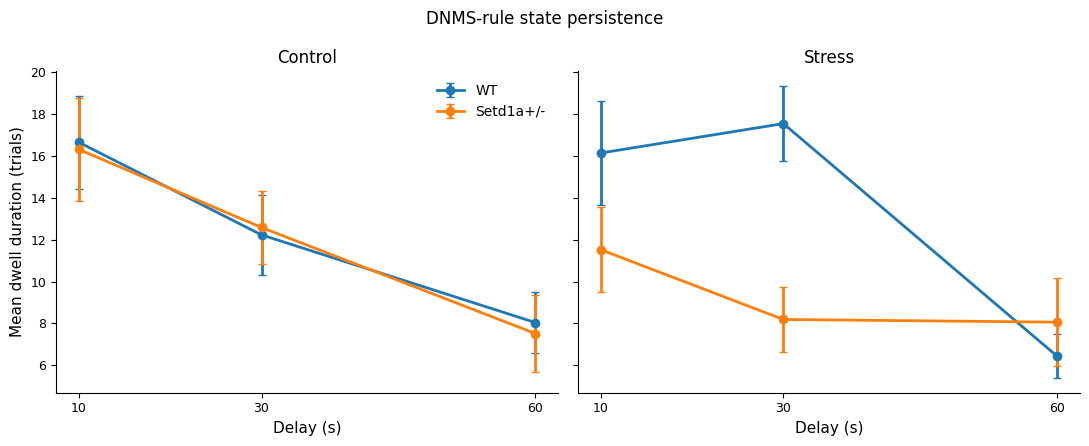

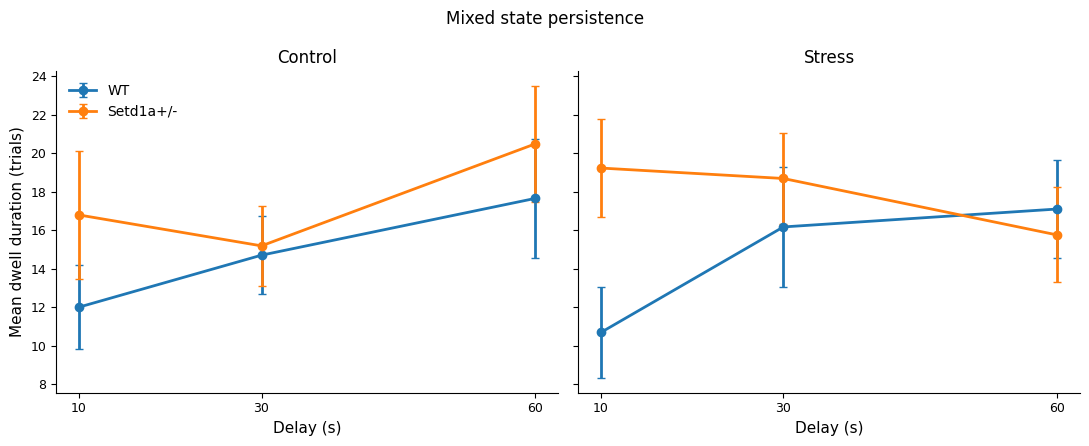

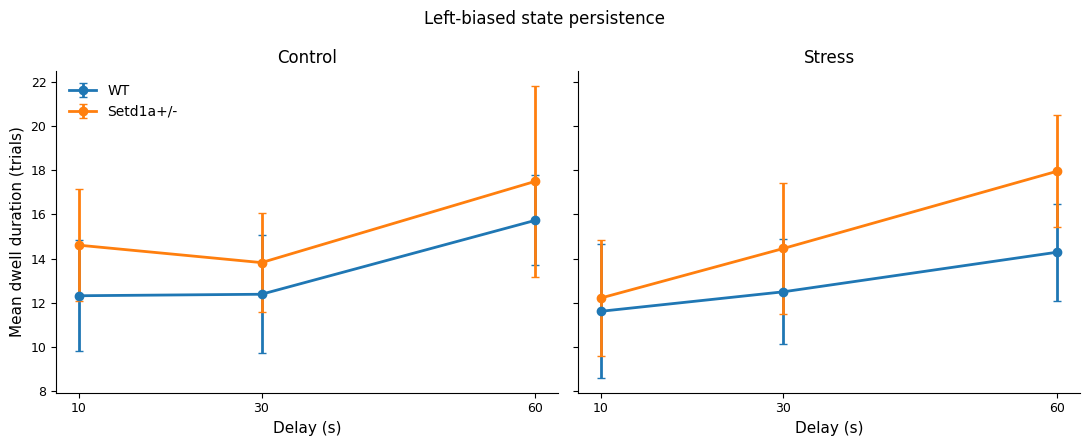

In [ ]:
# ============================================================
# STEP 4C
# DWELL-TIME FIGURES
#
# One figure per state
# Control / Stress
# WT vs Setd1a across 10 / 30 / 60 s
# ============================================================

for state in [
    "Engaged",
    "Mixed",
    "Biased"
]:

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(11, 4.5),
        sharey=True
    )

    for ax, stress in zip(
        axes,
        ["Control", "Stress"]
    ):

        temp = group_dwell[
            (group_dwell["state"] == state)
            &
            (group_dwell["stress"] == stress)
        ]


        for genotype in [
            "WT",
            "Setd1a+/-"
        ]:

            s = (
                temp[
                    temp["genotype"] == genotype
                ]
                .sort_values("delay_s")
            )


            ax.errorbar(
                s["delay_s"],
                s["mean_dwell"],
                yerr=s["sem_dwell"],
                marker="o",
                linewidth=2,
                capsize=3,
                label=genotype
            )


        ax.set_title(stress)

        ax.set_xticks(
            [10, 30, 60]
        )

        ax.set_xlabel(
            "Delay (s)"
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)


    axes[0].set_ylabel(
        "Mean dwell duration (trials)"
    )

    axes[0].legend(
        frameon=False
    )


    fig.suptitle(
        f"{DISPLAY_STATE[state]} state persistence"
    )

    fig.tight_layout()


    plt.savefig(
        OUT_DYN /
        f"Dwell_{DISPLAY_STATE[state].replace(' ', '_')}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

In [ ]:
# ============================================================
# STEP 5A
# MIXED-STATE PERSISTENCE:
# LONGEST MIXED RUN PER SESSION
# ============================================================

# Mixed runs only
mixed_runs = runs[
    runs["state"] == "Mixed"
].copy()


# Longest mixed run for sessions where Mixed occurred
mixed_longest_present = (
    mixed_runs
    .groupby("session_id")["dwell_trials"]
    .max()
    .rename("longest_mixed_run")
    .reset_index()
)


# Start with ALL usable sessions
all_sessions = (
    plot_df[
        [
            "mouse_id",
            "session_id",
            "genotype",
            "stress",
            "delay_s"
        ]
    ]
    .drop_duplicates()
)


mixed_session = (
    all_sessions
    .merge(
        mixed_longest_present,
        on="session_id",
        how="left"
    )
)


# Sessions with no Mixed = zero
mixed_session[
    "longest_mixed_run"
] = (
    mixed_session[
        "longest_mixed_run"
    ]
    .fillna(0)
)


# Number of Mixed trials per session
mixed_counts = (
    plot_df
    .assign(
        is_mixed=(
            plot_df["state_simple"]
            == "Mixed"
        ).astype(int)
    )
    .groupby("session_id")["is_mixed"]
    .sum()
    .rename("n_mixed_trials")
    .reset_index()
)


mixed_session = mixed_session.merge(
    mixed_counts,
    on="session_id",
    how="left"
)


mixed_session["mixed_occupancy_pct"] = (
    100
    * mixed_session["n_mixed_trials"]
    / 30
)


# ------------------------------------------------------------
# Mouse-level
# ------------------------------------------------------------

mouse_mixed_persistence = (
    mixed_session
    .groupby(
        [
            "mouse_id",
            "genotype",
            "stress",
            "delay_s"
        ]
    )
    .agg(
        longest_mixed_run=(
            "longest_mixed_run",
            "mean"
        ),
        mixed_occupancy_pct=(
            "mixed_occupancy_pct",
            "mean"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# Group-level
# ------------------------------------------------------------

group_mixed_persistence = (
    mouse_mixed_persistence
    .groupby(
        [
            "genotype",
            "stress",
            "delay_s"
        ]
    )
    .agg(
        mean_longest_run=(
            "longest_mixed_run",
            "mean"
        ),
        sem_longest_run=(
            "longest_mixed_run",
            "sem"
        ),
        mean_mixed_occupancy=(
            "mixed_occupancy_pct",
            "mean"
        ),
        sem_mixed_occupancy=(
            "mixed_occupancy_pct",
            "sem"
        ),
        n_mice=(
            "mouse_id",
            "nunique"
        )
    )
    .reset_index()
)


display(group_mixed_persistence)


mixed_session.to_csv(
    OUT_DYN / "session_mixed_persistence.csv",
    index=False
)

mouse_mixed_persistence.to_csv(
    OUT_DYN / "mouse_mixed_persistence.csv",
    index=False
)

,genotype,stress,delay_s,mean_longest_run,sem_longest_run,mean_mixed_occupancy,sem_mixed_occupancy,n_mice
0,Setd1a+/-,Control,10,6.533333,2.325489,22.333333,7.897578,10
1,Setd1a+/-,Control,30,8.866667,1.541364,30.111111,5.368327,10
2,Setd1a+/-,Control,60,13.833333,2.891559,46.111111,9.638529,10
3,Setd1a+/-,Stress,10,11.666667,2.180415,39.907407,7.382270,12
4,Setd1a+/-,Stress,30,10.972222,2.636655,37.129630,8.838725,12
5,Setd1a+/-,Stress,60,10.305556,2.796540,35.000000,9.189468,12
6,WT,Control,10,7.333333,2.242834,24.444444,7.476112,12
7,WT,Control,30,9.097222,2.476188,30.509259,8.259906,12
8,WT,Control,60,12.152778,2.980115,40.509259,9.933717,12
9,WT,Stress,10,6.333333,1.783765,22.020202,6.218646,11


In [ ]:
# ============================================================
# STEP 5B
# MIXED SELF-TRANSITION PROBABILITY
#
# P(next state = Mixed | current state = Mixed)
# ============================================================

transition_df = (
    seq_df
    .sort_values(
        [
            "session_id",
            "trial_position"
        ]
    )
    .copy()
)


transition_df["next_state"] = (
    transition_df
    .groupby("session_id")["state_simple"]
    .shift(-1)
)


# Exclude Trial 30
mixed_source = transition_df[
    (transition_df["state_simple"] == "Mixed")
    &
    transition_df["next_state"].notna()
].copy()


mixed_source["mixed_to_mixed"] = (
    mixed_source["next_state"]
    == "Mixed"
).astype(int)


# ------------------------------------------------------------
# Mouse-level probability
# ------------------------------------------------------------

mouse_mixed_self = (
    mixed_source
    .groupby(
        [
            "mouse_id",
            "genotype",
            "stress",
            "delay_s"
        ]
    )
    .agg(
        mixed_self_prob=(
            "mixed_to_mixed",
            "mean"
        ),
        n_mixed_transitions=(
            "mixed_to_mixed",
            "size"
        )
    )
    .reset_index()
)


mouse_mixed_self[
    "mixed_self_pct"
] = (
    mouse_mixed_self[
        "mixed_self_prob"
    ]
    * 100
)


group_mixed_self = (
    mouse_mixed_self
    .groupby(
        [
            "genotype",
            "stress",
            "delay_s"
        ]
    )
    .agg(
        mean_self_pct=(
            "mixed_self_pct",
            "mean"
        ),
        sem_self_pct=(
            "mixed_self_pct",
            "sem"
        ),
        n_mice=(
            "mouse_id",
            "nunique"
        )
    )
    .reset_index()
)


display(group_mixed_self)


mouse_mixed_self.to_csv(
    OUT_DYN / "mouse_mixed_self_transition.csv",
    index=False
)

,genotype,stress,delay_s,mean_self_pct,sem_self_pct,n_mice
0,Setd1a+/-,Control,10,96.759259,2.723230,6
1,Setd1a+/-,Control,30,93.460332,3.187538,10
2,Setd1a+/-,Control,60,95.998469,3.132802,9
3,Setd1a+/-,Stress,10,98.449781,0.560329,10
4,Setd1a+/-,Stress,30,97.403794,1.026606,10
5,Setd1a+/-,Stress,60,94.465867,1.462576,10
6,WT,Control,10,99.811676,0.188324,9
7,WT,Control,30,96.316093,1.373201,10
8,WT,Control,60,85.480518,9.040184,11
9,WT,Stress,10,91.979798,5.612072,9


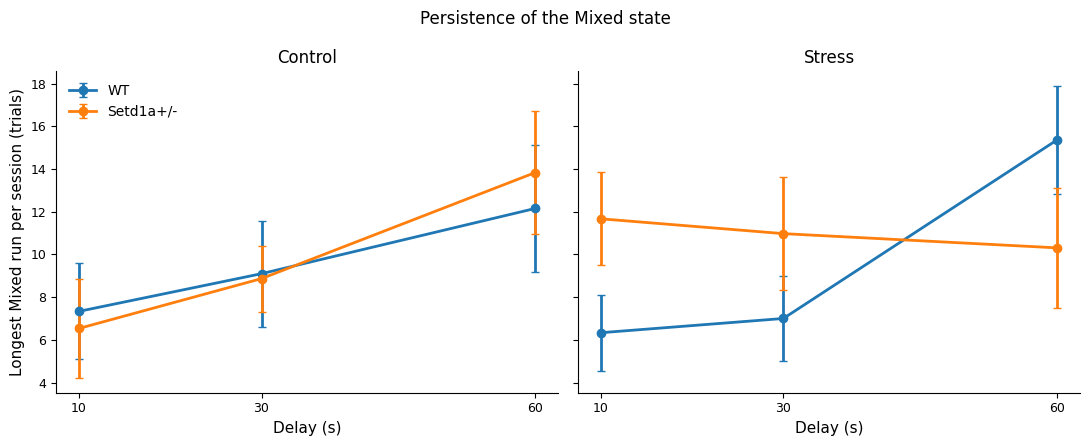

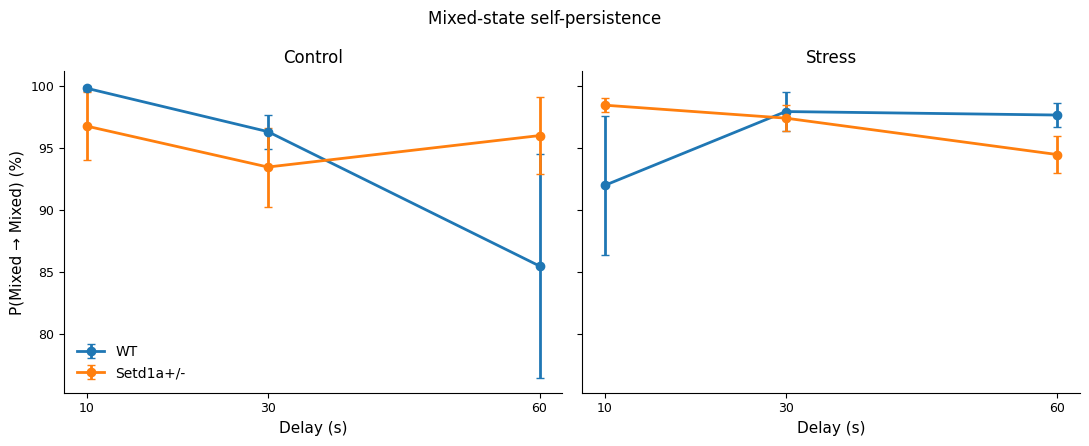

In [ ]:
# ============================================================
# STEP 5C
# MIXED PERSISTENCE FIGURES
# ============================================================


# ------------------------------------------------------------
# Figure A: longest Mixed run
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
    sharey=True
)


for ax, stress in zip(
    axes,
    ["Control", "Stress"]
):

    temp = group_mixed_persistence[
        group_mixed_persistence["stress"]
        == stress
    ]


    for genotype in [
        "WT",
        "Setd1a+/-"
    ]:

        s = (
            temp[
                temp["genotype"]
                == genotype
            ]
            .sort_values("delay_s")
        )


        ax.errorbar(
            s["delay_s"],
            s["mean_longest_run"],
            yerr=s["sem_longest_run"],
            marker="o",
            linewidth=2,
            capsize=3,
            label=genotype
        )


    ax.set_title(stress)

    ax.set_xticks(
        [10, 30, 60]
    )

    ax.set_xlabel(
        "Delay (s)"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


axes[0].set_ylabel(
    "Longest Mixed run per session (trials)"
)

axes[0].legend(
    frameon=False
)

fig.suptitle(
    "Persistence of the Mixed state"
)

fig.tight_layout()

plt.savefig(
    OUT_DYN /
    "Mixed_longest_run.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# ------------------------------------------------------------
# Figure B: P(Mixed -> Mixed)
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
    sharey=True
)


for ax, stress in zip(
    axes,
    ["Control", "Stress"]
):

    temp = group_mixed_self[
        group_mixed_self["stress"]
        == stress
    ]


    for genotype in [
        "WT",
        "Setd1a+/-"
    ]:

        s = (
            temp[
                temp["genotype"]
                == genotype
            ]
            .sort_values("delay_s")
        )


        ax.errorbar(
            s["delay_s"],
            s["mean_self_pct"],
            yerr=s["sem_self_pct"],
            marker="o",
            linewidth=2,
            capsize=3,
            label=genotype
        )


    ax.set_title(stress)

    ax.set_xticks(
        [10, 30, 60]
    )

    ax.set_xlabel(
        "Delay (s)"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


axes[0].set_ylabel(
    "P(Mixed → Mixed) (%)"
)

axes[0].legend(
    frameon=False
)

fig.suptitle(
    "Mixed-state self-persistence"
)

fig.tight_layout()

plt.savefig(
    OUT_DYN /
    "Mixed_self_transition_probability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# STEP 6A
# MIXED-RUN CONTEXT ANALYSIS
#
# Question:
# Is Mixed a bridge between DNMS-rule and Left-biased,
# or does it behave as a stable alternative state?
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DYN = Path(
    "/content/state_dynamics_results/switch_dwell_analysis"
)
OUT_DYN.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 1. Sort continuous state runs within session
# ------------------------------------------------------------

runs_context = (
    runs
    .sort_values(
        [
            "session_id",
            "run_id"
        ]
    )
    .copy()
)


# Previous and next RUN state
runs_context["previous_run_state"] = (
    runs_context
    .groupby("session_id")["state"]
    .shift(1)
)

runs_context["next_run_state"] = (
    runs_context
    .groupby("session_id")["state"]
    .shift(-1)
)


# ------------------------------------------------------------
# 2. Keep only Mixed runs
# ------------------------------------------------------------

mixed_context = (
    runs_context[
        runs_context["state"] == "Mixed"
    ]
    .copy()
)


# ------------------------------------------------------------
# 3. Classify context
# ------------------------------------------------------------

def classify_mixed_context(row):

    prev_s = row["previous_run_state"]
    next_s = row["next_run_state"]

    # Whole session = Mixed
    if pd.isna(prev_s) and pd.isna(next_s):
        return "Full-session Mixed"

    # Session begins in Mixed
    if pd.isna(prev_s):
        return "Session-start Mixed"

    # Session ends in Mixed
    if pd.isna(next_s):
        return "Session-end Mixed"

    # True bridge between the two different outer states
    if prev_s == "Engaged" and next_s == "Biased":
        return "DNMS → Mixed → Left"

    if prev_s == "Biased" and next_s == "Engaged":
        return "Left → Mixed → DNMS"

    # Return to same state
    if prev_s == "Engaged" and next_s == "Engaged":
        return "DNMS → Mixed → DNMS"

    if prev_s == "Biased" and next_s == "Biased":
        return "Left → Mixed → Left"

    return "Other"


mixed_context["context"] = (
    mixed_context
    .apply(
        classify_mixed_context,
        axis=1
    )
)


# ------------------------------------------------------------
# 4. Add useful broader categories
# ------------------------------------------------------------

mixed_context["bridge"] = (
    mixed_context["context"]
    .isin(
        [
            "DNMS → Mixed → Left",
            "Left → Mixed → DNMS"
        ]
    )
)


mixed_context["internal_run"] = (
    mixed_context["previous_run_state"].notna()
    &
    mixed_context["next_run_state"].notna()
)


mixed_context["boundary_run"] = (
    ~mixed_context["internal_run"]
)


# ------------------------------------------------------------
# 5. Display
# ------------------------------------------------------------

print("Number of Mixed runs:", len(mixed_context))

print("\nMixed contexts:")
print(
    mixed_context["context"]
    .value_counts()
)

display(
    mixed_context[
        [
            "mouse_id",
            "session_id",
            "genotype",
            "stress",
            "delay_s",
            "start_trial",
            "end_trial",
            "dwell_trials",
            "previous_run_state",
            "next_run_state",
            "context"
        ]
    ].head(30)
)


# ------------------------------------------------------------
# 6. Save exact Mixed episodes
#
# This file will later be useful for video matching.
# ------------------------------------------------------------

mixed_context.to_csv(
    OUT_DYN /
    "mixed_run_context_all_events.csv",
    index=False
)

Number of Mixed runs: 241

Mixed contexts:
context
Session-end Mixed      152
DNMS → Mixed → DNMS     27
DNMS → Mixed → Left     27
Full-session Mixed      18
Left → Mixed → Left      9
Session-start Mixed      7
Left → Mixed → DNMS      1
Name: count, dtype: int64


,mouse_id,session_id,genotype,stress,delay_s,start_trial,end_trial,dwell_trials,previous_run_state,next_run_state,context
1,Sd101,Sd101_Testing1-10_360,Setd1a+/-,Stress,10,10,30,21,Engaged,NaN,Session-end Mixed
3,Sd101,Sd101_Testing1-30_363,Setd1a+/-,Stress,30,11,30,20,Engaged,NaN,Session-end Mixed
6,Sd101,Sd101_Testing2-10_361,Setd1a+/-,Stress,10,2,8,7,Engaged,Engaged,DNMS → Mixed → DNMS
8,Sd101,Sd101_Testing2-10_361,Setd1a+/-,Stress,10,29,30,2,Engaged,NaN,Session-end Mixed
9,Sd101,Sd101_Testing2-30_364,Setd1a+/-,Stress,30,1,30,30,NaN,NaN,Full-session Mixed
16,Sd101,Sd101_Testing3-30_365,Setd1a+/-,Stress,30,2,30,29,Biased,NaN,Session-end Mixed
18,Sd101,Sd101_Testing3-60_368,Setd1a+/-,Stress,60,16,23,8,Engaged,Biased,DNMS → Mixed → Left
22,Sd104,Sd104_Testing1-30_372,Setd1a+/-,Control,30,2,13,12,Engaged,Engaged,DNMS → Mixed → DNMS
25,Sd104,Sd104_Testing1-60_375,Setd1a+/-,Control,60,3,30,28,Engaged,NaN,Session-end Mixed
31,Sd104,Sd104_Testing2-30_373,Setd1a+/-,Control,30,27,30,4,Biased,NaN,Session-end Mixed


In [ ]:
# ============================================================
# STEP 6B
# BRIDGE PROBABILITY AMONG INTERNAL MIXED RUNS
#
# Bridge:
# DNMS -> Mixed -> Left
# Left -> Mixed -> DNMS
# ============================================================

internal_mixed = (
    mixed_context[
        mixed_context["internal_run"]
    ]
    .copy()
)


# ------------------------------------------------------------
# Mouse-level
# ------------------------------------------------------------

mouse_bridge = (
    internal_mixed
    .groupby(
        [
            "mouse_id",
            "genotype",
            "stress",
            "delay_s"
        ]
    )
    .agg(
        n_internal_mixed=("context", "size"),
        n_bridge=("bridge", "sum")
    )
    .reset_index()
)


mouse_bridge["bridge_pct"] = (
    100
    *
    mouse_bridge["n_bridge"]
    /
    mouse_bridge["n_internal_mixed"]
)


# ------------------------------------------------------------
# Group-level
# ------------------------------------------------------------

group_bridge = (
    mouse_bridge
    .groupby(
        [
            "genotype",
            "stress",
            "delay_s"
        ]
    )
    .agg(
        mean_bridge_pct=("bridge_pct", "mean"),
        sem_bridge_pct=("bridge_pct", "sem"),
        n_mice=("mouse_id", "nunique")
    )
    .reset_index()
)


print("\nBridge probability:")
display(group_bridge)


mouse_bridge.to_csv(
    OUT_DYN /
    "mouse_level_mixed_bridge_probability.csv",
    index=False
)

group_bridge.to_csv(
    OUT_DYN /
    "group_level_mixed_bridge_probability.csv",
    index=False
)


Bridge probability:


,genotype,stress,delay_s,mean_bridge_pct,sem_bridge_pct,n_mice
0,Setd1a+/-,Control,10,0.000000,0.000000,2
1,Setd1a+/-,Control,30,20.000000,20.000000,5
2,Setd1a+/-,Control,60,25.000000,25.000000,2
3,Setd1a+/-,Stress,10,30.000000,20.000000,5
4,Setd1a+/-,Stress,30,70.000000,20.000000,5
5,Setd1a+/-,Stress,60,47.619048,19.047619,7
6,WT,Control,10,100.000000,NaN,1
7,WT,Control,30,50.000000,22.360680,6
8,WT,Control,60,44.444444,20.487877,6
9,WT,Stress,10,33.333333,33.333333,3


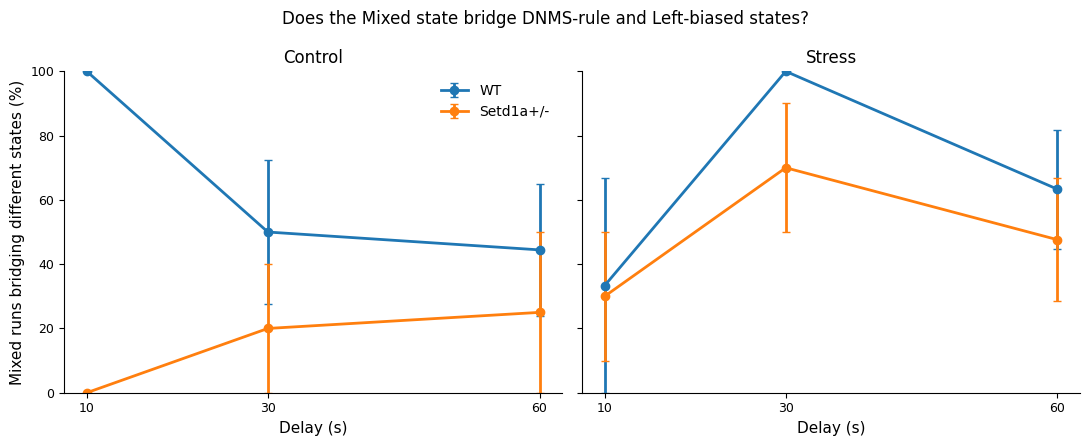

In [ ]:
# ============================================================
# STEP 6C
# PLOT: HOW OFTEN IS MIXED A TRUE BRIDGE?
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
    sharey=True
)


for ax, stress in zip(
    axes,
    ["Control", "Stress"]
):

    temp = group_bridge[
        group_bridge["stress"] == stress
    ]


    for genotype in [
        "WT",
        "Setd1a+/-"
    ]:

        s = (
            temp[
                temp["genotype"] == genotype
            ]
            .sort_values("delay_s")
        )


        ax.errorbar(
            s["delay_s"],
            s["mean_bridge_pct"],
            yerr=s["sem_bridge_pct"],
            marker="o",
            linewidth=2,
            capsize=3,
            label=genotype
        )


    ax.set_title(stress)

    ax.set_xticks(
        [10, 30, 60]
    )

    ax.set_xlabel(
        "Delay (s)"
    )

    ax.set_ylim(
        0,
        100
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


axes[0].set_ylabel(
    "Mixed runs bridging different states (%)"
)

axes[0].legend(
    frameon=False
)

fig.suptitle(
    "Does the Mixed state bridge DNMS-rule and Left-biased states?"
)

fig.tight_layout()

plt.savefig(
    OUT_DYN /
    "Mixed_bridge_probability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# STEP 6D
# CONTEXT DISTRIBUTION OF MIXED RUNS
# ============================================================

CONTEXT_ORDER = [
    "DNMS → Mixed → Left",
    "Left → Mixed → DNMS",
    "DNMS → Mixed → DNMS",
    "Left → Mixed → Left",
    "Session-start Mixed",
    "Session-end Mixed",
    "Full-session Mixed"
]


# ------------------------------------------------------------
# Count within mouse first
# ------------------------------------------------------------

mouse_context_rows = []


for (
    genotype,
    stress,
    mouse,
    delay
), g in (

    mixed_context
    .groupby(
        [
            "genotype",
            "stress",
            "mouse_id",
            "delay_s"
        ]
    )
):

    counts = (
        g["context"]
        .value_counts(normalize=True)
        * 100
    )

    for context in CONTEXT_ORDER:

        mouse_context_rows.append(
            {
                "genotype": genotype,
                "stress": stress,
                "mouse_id": mouse,
                "delay_s": delay,
                "context": context,
                "pct": counts.get(context, 0)
            }
        )


mouse_context = pd.DataFrame(
    mouse_context_rows
)


group_context = (
    mouse_context
    .groupby(
        [
            "genotype",
            "stress",
            "delay_s",
            "context"
        ]
    )["pct"]
    .agg(
        mean="mean",
        sem="sem",
        n_mice="count"
    )
    .reset_index()
)


display(group_context)


mouse_context.to_csv(
    OUT_DYN /
    "mouse_level_mixed_context_distribution.csv",
    index=False
)

group_context.to_csv(
    OUT_DYN /
    "group_level_mixed_context_distribution.csv",
    index=False
)

,genotype,stress,delay_s,context,mean,sem,n_mice
0,Setd1a+/-,Control,10,DNMS → Mixed → DNMS,20.833333,16.351181,6
1,Setd1a+/-,Control,10,DNMS → Mixed → Left,0.000000,0.000000,6
2,Setd1a+/-,Control,10,Full-session Mixed,16.666667,10.540926,6
3,Setd1a+/-,Control,10,Left → Mixed → DNMS,0.000000,0.000000,6
4,Setd1a+/-,Control,10,Left → Mixed → Left,0.000000,0.000000,6
...,...,...,...,...,...,...,...
79,WT,Stress,60,Full-session Mixed,3.030303,3.030303,11
80,WT,Stress,60,Left → Mixed → DNMS,0.000000,0.000000,11
81,WT,Stress,60,Left → Mixed → Left,3.030303,3.030303,11
82,WT,Stress,60,Session-end Mixed,70.303030,8.108538,11


In [ ]:
# ============================================================
# STEP 6E
# SIMPLIFIED MIXED-RUN ROLE
# ============================================================

def simplify_role(context):

    if context in [
        "DNMS → Mixed → Left",
        "Left → Mixed → DNMS"
    ]:
        return "Bridge"

    if context in [
        "DNMS → Mixed → DNMS",
        "Left → Mixed → Left"
    ]:
        return "Return to same state"

    if context in [
        "Session-start Mixed",
        "Session-end Mixed",
        "Full-session Mixed"
    ]:
        return "Boundary / persistent"

    return "Other"


mixed_context["mixed_role"] = (
    mixed_context["context"]
    .apply(simplify_role)
)


print(
    mixed_context["mixed_role"]
    .value_counts()
)


# ------------------------------------------------------------
# Mouse-balanced role percentages
# ------------------------------------------------------------

role_rows = []


for (
    genotype,
    stress,
    mouse,
    delay
), g in (

    mixed_context
    .groupby(
        [
            "genotype",
            "stress",
            "mouse_id",
            "delay_s"
        ]
    )
):

    props = (
        g["mixed_role"]
        .value_counts(normalize=True)
        * 100
    )


    for role in [
        "Bridge",
        "Return to same state",
        "Boundary / persistent"
    ]:

        role_rows.append(
            {
                "genotype": genotype,
                "stress": stress,
                "mouse_id": mouse,
                "delay_s": delay,
                "mixed_role": role,
                "pct": props.get(role, 0)
            }
        )


mouse_role = pd.DataFrame(
    role_rows
)


group_role = (
    mouse_role
    .groupby(
        [
            "genotype",
            "stress",
            "delay_s",
            "mixed_role"
        ]
    )["pct"]
    .agg(
        mean="mean",
        sem="sem",
        n_mice="count"
    )
    .reset_index()
)


display(group_role)


mouse_role.to_csv(
    OUT_DYN /
    "mouse_level_mixed_role.csv",
    index=False
)

group_role.to_csv(
    OUT_DYN /
    "group_level_mixed_role.csv",
    index=False
)

mixed_role
Boundary / persistent    177
Return to same state      36
Bridge                    28
Name: count, dtype: int64


,genotype,stress,delay_s,mixed_role,mean,sem,n_mice
0,Setd1a+/-,Control,10,Boundary / persistent,79.166667,16.351181,6
1,Setd1a+/-,Control,10,Bridge,0.000000,0.000000,6
2,Setd1a+/-,Control,10,Return to same state,20.833333,16.351181,6
3,Setd1a+/-,Control,30,Boundary / persistent,68.333333,12.777778,10
4,Setd1a+/-,Control,30,Bridge,3.333333,3.333333,10
5,Setd1a+/-,Control,30,Return to same state,28.333333,13.158577,10
6,Setd1a+/-,Control,60,Boundary / persistent,83.333333,11.785113,9
7,Setd1a+/-,Control,60,Bridge,5.555556,5.555556,9
8,Setd1a+/-,Control,60,Return to same state,11.111111,7.349309,9
9,Setd1a+/-,Stress,10,Boundary / persistent,80.303030,7.391704,11


In [ ]:
# ============================================================
# SAVE ALL REMAINING SUMMARY TABLES
# ============================================================

if "group_mixed_persistence" in globals():

    group_mixed_persistence.to_csv(
        OUT_DYN /
        "group_mixed_persistence.csv",
        index=False
    )


if "group_mixed_self" in globals():

    group_mixed_self.to_csv(
        OUT_DYN /
        "group_mixed_self_transition.csv",
        index=False
    )


if "runs" in globals():

    runs.to_csv(
        OUT_DYN /
        "all_state_runs.csv",
        index=False
    )


print("Saved all summary tables to:")
print(OUT_DYN)

Saved all summary tables to:
/content/state_dynamics_results/switch_dwell_analysis


In [ ]:
# ============================================================
# BACKUP EVERYTHING AS ZIP
# ============================================================

import shutil

SOURCE_DIR = "/content/state_dynamics_results"

ZIP_OUTPUT = shutil.make_archive(
    "/content/GLMHMM_state_dynamics_analysis",
    "zip",
    SOURCE_DIR
)

print("ZIP created:")
print(ZIP_OUTPUT)

ZIP created:
/content/GLMHMM_state_dynamics_analysis.zip


Number of sessions: 403


,mouse_id,session_id,genotype,stress,delay_s,ever_mixed,first_mixed_trial,terminal_state,terminal_mixed,terminal_mixed_onset,terminal_mixed_duration,first_mixed_persists_to_end,left_mixed_after_first_entry
0,Sd101,Sd101_Testing1-10_360,Setd1a+/-,Stress,10,True,10.0,Mixed,True,10.0,21.0,True,False
1,Sd101,Sd101_Testing1-30_363,Setd1a+/-,Stress,30,True,11.0,Mixed,True,11.0,20.0,True,False
2,Sd101,Sd101_Testing1-60_366,Setd1a+/-,Stress,60,False,NaN,Engaged,False,NaN,NaN,False,False
3,Sd101,Sd101_Testing2-10_361,Setd1a+/-,Stress,10,True,2.0,Mixed,True,29.0,2.0,False,True
4,Sd101,Sd101_Testing2-30_364,Setd1a+/-,Stress,30,True,1.0,Mixed,True,1.0,30.0,True,False
5,Sd101,Sd101_Testing2-60_367,Setd1a+/-,Stress,60,False,NaN,Biased,False,NaN,NaN,False,False
6,Sd101,Sd101_Testing3-10_362,Setd1a+/-,Stress,10,False,NaN,Engaged,False,NaN,NaN,False,False
7,Sd101,Sd101_Testing3-30_365,Setd1a+/-,Stress,30,True,2.0,Mixed,True,2.0,29.0,True,False
8,Sd101,Sd101_Testing3-60_368,Setd1a+/-,Stress,60,True,16.0,Biased,False,NaN,NaN,False,True
9,Sd104,Sd104_Testing1-10_369,Setd1a+/-,Control,10,False,NaN,Engaged,False,NaN,NaN,False,False



TERMINAL STATE COUNTS
terminal_state
Mixed      170
Biased     136
Engaged     97
Name: count, dtype: int64

Terminal states by genotype × stress × delay:


terminal_state             Biased  Engaged  Mixed
genotype  stress  delay_s                        
Setd1a+/- Control 10            8       12     10
                  30           11        9     10
                  60           11        3     16
          Stress  10            8       11     17
                  30           16        5     15
                  60           18        7     11
WT        Control 10            9       10     17
                  30           14        7     15
                  60           15        5     14
          Stress  10            4       15     14
                  30           14        8     11
                  60            8        5     20


GROUP SUMMARY


,genotype,stress,delay_s,mean_ever_mixed_pct,sem_ever_mixed_pct,mean_terminal_mixed_pct,sem_terminal_mixed_pct,mean_persist_after_first_pct,sem_persist_after_first_pct,mean_first_mixed_trial,sem_first_mixed_trial,mean_terminal_mixed_onset,sem_terminal_mixed_onset,mean_terminal_mixed_duration,sem_terminal_mixed_duration,n_mice
0,Setd1a+/-,Control,10,36.666667,11.600341,33.333333,12.171612,77.777778,16.480441,10.472222,2.084518,11.833333,2.965543,19.166667,2.965543,10
1,Setd1a+/-,Control,30,56.666667,7.114582,33.333333,9.938080,46.666667,14.010578,8.783333,1.671853,14.583333,2.107197,16.416667,2.107197,10
2,Setd1a+/-,Control,60,66.666667,9.938080,53.333333,11.331154,79.629630,11.712139,8.333333,2.081295,7.791667,2.000434,23.208333,2.000434,10
3,Setd1a+/-,Stress,10,58.333333,9.288674,47.222222,6.433202,75.757576,8.808753,8.681818,2.386775,10.681818,2.572824,20.318182,2.572824,12
4,Setd1a+/-,Stress,30,55.555556,9.475587,41.666667,10.952146,65.000000,13.017083,9.100000,2.016934,9.812500,3.062419,21.187500,3.062419,12
5,Setd1a+/-,Stress,60,58.333333,10.952146,30.555556,11.205408,36.666667,13.333333,8.050000,2.037314,8.638889,3.160056,22.361111,3.160056,12
6,WT,Control,10,50.000000,10.460765,47.222222,9.585986,96.666667,3.333333,18.516667,2.431589,18.716667,2.323000,12.283333,2.323000,12
7,WT,Control,30,54.166667,10.283236,43.055556,10.944137,61.666667,12.435016,11.433333,1.853292,15.062500,2.531143,15.937500,2.531143,12
8,WT,Control,60,63.888889,9.363887,38.888889,12.866403,50.000000,15.075567,8.257576,1.871957,7.722222,3.408233,23.277778,3.408233,12
9,WT,Stress,10,51.515152,9.389051,42.424242,10.141334,73.333333,13.877773,16.750000,2.509150,18.562500,2.600545,12.437500,2.600545,11



Terminal-state composition:


,genotype,stress,delay_s,terminal_state,mean,sem,n_mice
0,Setd1a+/-,Control,10,Biased,26.666667,8.314794,10
1,Setd1a+/-,Control,10,Engaged,40.000000,12.957671,10
2,Setd1a+/-,Control,10,Mixed,33.333333,12.171612,10
3,Setd1a+/-,Control,30,Biased,36.666667,10.482201,10
4,Setd1a+/-,Control,30,Engaged,30.000000,10.482201,10
5,Setd1a+/-,Control,30,Mixed,33.333333,9.938080,10
6,Setd1a+/-,Control,60,Biased,36.666667,10.482201,10
7,Setd1a+/-,Control,60,Engaged,10.000000,7.114582,10
8,Setd1a+/-,Control,60,Mixed,53.333333,11.331154,10
9,Setd1a+/-,Stress,10,Biased,22.222222,9.475587,12


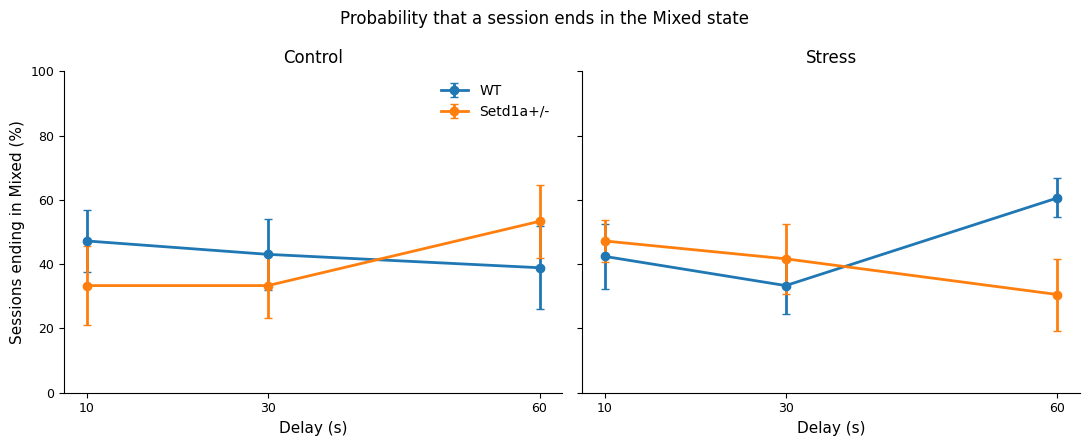

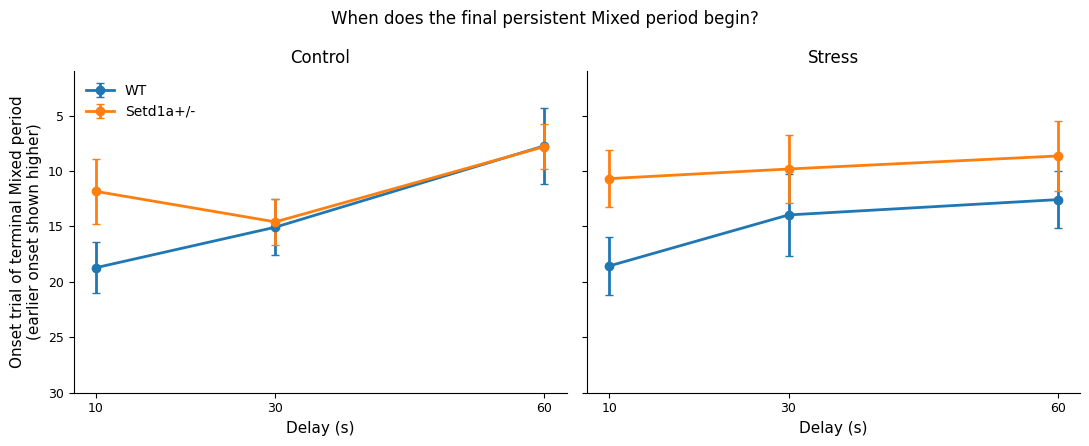

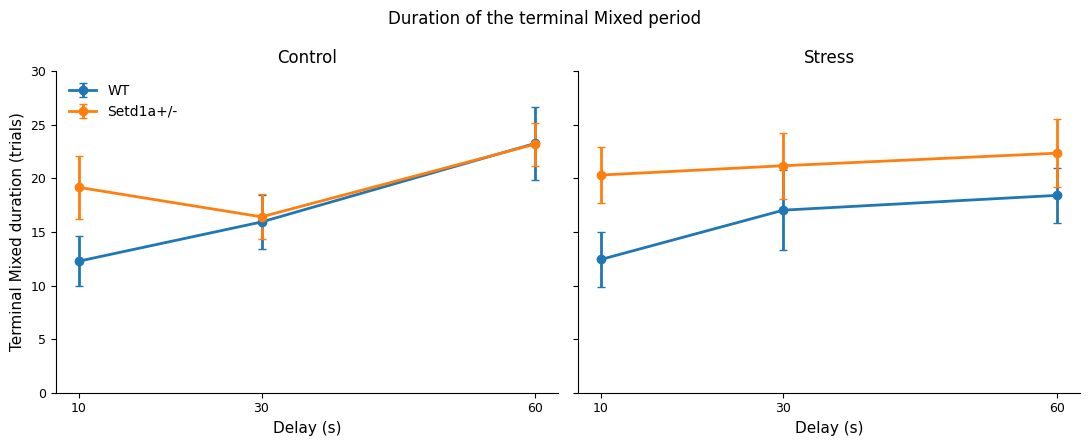

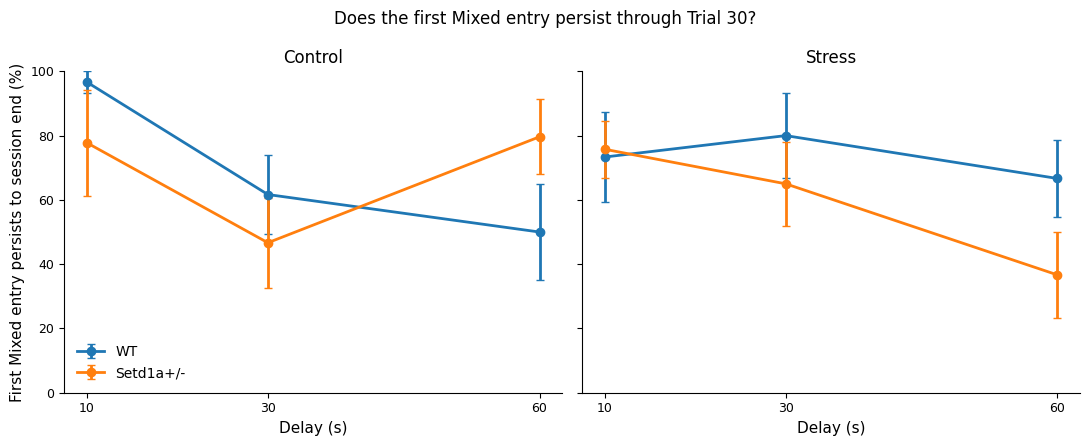

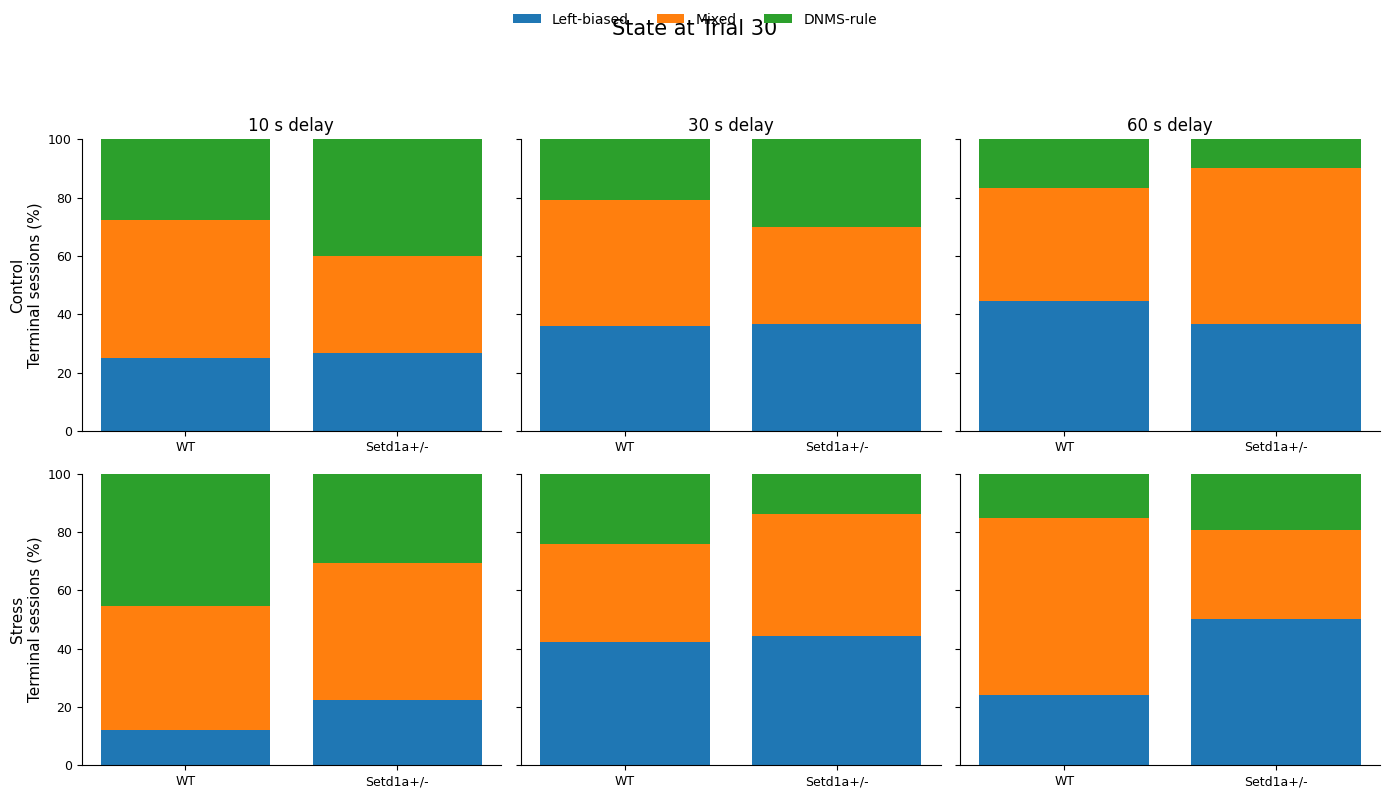


STEP 7 COMPLETE

Files saved to:
/content/state_dynamics_results/switch_dwell_analysis


In [ ]:
# ============================================================
# STEP 7
# MIXED ONSET + TERMINAL-STATE ANALYSIS
#
# Questions:
#
# 1. Does a session ever enter Mixed?
# 2. When does Mixed first appear?
# 3. What state is the mouse in at Trial 30?
# 4. How often does the session END in Mixed?
# 5. If the session ends in Mixed, when did the final
#    continuous Mixed period begin?
# 6. How long is that terminal Mixed period?
# 7. Once Mixed first appears, does it sometimes remain
#    Mixed all the way to the end of the session?
#
# Uses:
# plot_df = clean 403-session, 30-trial positional dataset
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 0. OUTPUT DIRECTORY
# ============================================================

OUT_DYN = Path(
    "/content/state_dynamics_results/switch_dwell_analysis"
)

OUT_DYN.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 1. MAKE ONE SESSION-LEVEL TABLE
# ============================================================

session_rows = []


for session_id, s in (
    plot_df
    .sort_values(
        [
            "session_id",
            "trial_position"
        ]
    )
    .groupby("session_id")
):

    s = (
        s
        .sort_values("trial_position")
        .reset_index(drop=True)
    )

    states = s["state_simple"].tolist()
    trials = s["trial_position"].tolist()

    # --------------------------------------
    # Does Mixed appear anywhere?
    # --------------------------------------

    mixed_positions = [
        trial
        for trial, state
        in zip(trials, states)
        if state == "Mixed"
    ]

    ever_mixed = (
        len(mixed_positions) > 0
    )


    # --------------------------------------
    # First Mixed onset
    # --------------------------------------

    if ever_mixed:

        first_mixed_trial = min(
            mixed_positions
        )

    else:

        first_mixed_trial = np.nan


    # --------------------------------------
    # Terminal state = Trial 30 state
    # --------------------------------------

    terminal_state = states[-1]

    terminal_mixed = (
        terminal_state == "Mixed"
    )


    # --------------------------------------
    # If terminal state is Mixed:
    #
    # find beginning of FINAL continuous
    # Mixed block
    # --------------------------------------

    if terminal_mixed:

        terminal_start_index = (
            len(states) - 1
        )

        while (
            terminal_start_index > 0
            and
            states[
                terminal_start_index - 1
            ]
            == "Mixed"
        ):

            terminal_start_index -= 1


        terminal_mixed_onset = (
            trials[
                terminal_start_index
            ]
        )

        terminal_mixed_duration = (
            30
            -
            terminal_mixed_onset
            +
            1
        )

    else:

        terminal_mixed_onset = np.nan
        terminal_mixed_duration = np.nan


    # --------------------------------------
    # Strong persistence metric:
    #
    # Once the FIRST Mixed trial occurs,
    # are ALL remaining trials Mixed?
    #
    # Example:
    #
    # DNMS DNMS Mixed Mixed Mixed ... Trial30
    # -> YES
    #
    # DNMS Mixed DNMS ...
    # -> NO
    # --------------------------------------

    if ever_mixed:

        first_idx = states.index(
            "Mixed"
        )

        states_after_first_mixed = (
            states[first_idx:]
        )

        first_mixed_persists_to_end = (
            all(
                state == "Mixed"
                for state
                in states_after_first_mixed
            )
        )

    else:

        first_mixed_persists_to_end = False


    # --------------------------------------
    # Did mouse leave Mixed after
    # first entering it?
    # --------------------------------------

    if ever_mixed:

        left_mixed_after_first_entry = (
            not first_mixed_persists_to_end
        )

    else:

        left_mixed_after_first_entry = False


    # --------------------------------------
    # Store session-level results
    # --------------------------------------

    session_rows.append(
        {
            "mouse_id":
                s.loc[0, "mouse_id"],

            "session_id":
                session_id,

            "genotype":
                s.loc[0, "genotype"],

            "stress":
                s.loc[0, "stress"],

            "delay_s":
                s.loc[0, "delay_s"],

            "ever_mixed":
                ever_mixed,

            "first_mixed_trial":
                first_mixed_trial,

            "terminal_state":
                terminal_state,

            "terminal_mixed":
                terminal_mixed,

            "terminal_mixed_onset":
                terminal_mixed_onset,

            "terminal_mixed_duration":
                terminal_mixed_duration,

            "first_mixed_persists_to_end":
                first_mixed_persists_to_end,

            "left_mixed_after_first_entry":
                left_mixed_after_first_entry
        }
    )


session_terminal = pd.DataFrame(
    session_rows
)


print(
    "Number of sessions:",
    len(session_terminal)
)

display(
    session_terminal.head(20)
)


# ============================================================
# 2. BASIC TERMINAL-STATE COUNTS
# ============================================================

print("\n==============================")
print("TERMINAL STATE COUNTS")
print("==============================")

print(
    session_terminal[
        "terminal_state"
    ]
    .value_counts()
)


print("\nTerminal states by genotype × stress × delay:")

display(
    pd.crosstab(
        [
            session_terminal["genotype"],
            session_terminal["stress"],
            session_terminal["delay_s"]
        ],
        session_terminal["terminal_state"]
    )
)


# ============================================================
# 3. MOUSE-LEVEL SUMMARY
#
# IMPORTANT:
# Average sessions within mouse FIRST.
# ============================================================

mouse_rows = []


for (
    genotype,
    stress,
    mouse,
    delay
), g in (

    session_terminal
    .groupby(
        [
            "genotype",
            "stress",
            "mouse_id",
            "delay_s"
        ]
    )
):

    # --------------------------------------
    # Probability session ever enters Mixed
    # --------------------------------------

    ever_mixed_pct = (
        100
        *
        g["ever_mixed"]
        .mean()
    )


    # --------------------------------------
    # Probability session ENDS in Mixed
    # --------------------------------------

    terminal_mixed_pct = (
        100
        *
        g["terminal_mixed"]
        .mean()
    )


    # --------------------------------------
    # Probability first Mixed persists
    # all the way to end
    #
    # Conditional on sessions with Mixed
    # --------------------------------------

    g_mixed = g[
        g["ever_mixed"]
    ]

    if len(g_mixed) > 0:

        persistent_after_first_pct = (
            100
            *
            g_mixed[
                "first_mixed_persists_to_end"
            ]
            .mean()
        )

        mean_first_mixed_trial = (
            g_mixed[
                "first_mixed_trial"
            ]
            .mean()
        )

    else:

        persistent_after_first_pct = np.nan
        mean_first_mixed_trial = np.nan


    # --------------------------------------
    # Terminal-Mixed sessions only
    # --------------------------------------

    g_terminal = g[
        g["terminal_mixed"]
    ]

    if len(g_terminal) > 0:

        mean_terminal_mixed_onset = (
            g_terminal[
                "terminal_mixed_onset"
            ]
            .mean()
        )

        mean_terminal_mixed_duration = (
            g_terminal[
                "terminal_mixed_duration"
            ]
            .mean()
        )

    else:

        mean_terminal_mixed_onset = np.nan
        mean_terminal_mixed_duration = np.nan


    mouse_rows.append(
        {
            "genotype":
                genotype,

            "stress":
                stress,

            "mouse_id":
                mouse,

            "delay_s":
                delay,

            "n_sessions":
                len(g),

            "ever_mixed_pct":
                ever_mixed_pct,

            "terminal_mixed_pct":
                terminal_mixed_pct,

            "persistent_after_first_mixed_pct":
                persistent_after_first_pct,

            "mean_first_mixed_trial":
                mean_first_mixed_trial,

            "mean_terminal_mixed_onset":
                mean_terminal_mixed_onset,

            "mean_terminal_mixed_duration":
                mean_terminal_mixed_duration
        }
    )


mouse_terminal = pd.DataFrame(
    mouse_rows
)


# ============================================================
# 4. GROUP SUMMARY ACROSS MICE
# ============================================================

group_terminal = (
    mouse_terminal
    .groupby(
        [
            "genotype",
            "stress",
            "delay_s"
        ]
    )
    .agg(
        mean_ever_mixed_pct=(
            "ever_mixed_pct",
            "mean"
        ),

        sem_ever_mixed_pct=(
            "ever_mixed_pct",
            "sem"
        ),

        mean_terminal_mixed_pct=(
            "terminal_mixed_pct",
            "mean"
        ),

        sem_terminal_mixed_pct=(
            "terminal_mixed_pct",
            "sem"
        ),

        mean_persist_after_first_pct=(
            "persistent_after_first_mixed_pct",
            "mean"
        ),

        sem_persist_after_first_pct=(
            "persistent_after_first_mixed_pct",
            "sem"
        ),

        mean_first_mixed_trial=(
            "mean_first_mixed_trial",
            "mean"
        ),

        sem_first_mixed_trial=(
            "mean_first_mixed_trial",
            "sem"
        ),

        mean_terminal_mixed_onset=(
            "mean_terminal_mixed_onset",
            "mean"
        ),

        sem_terminal_mixed_onset=(
            "mean_terminal_mixed_onset",
            "sem"
        ),

        mean_terminal_mixed_duration=(
            "mean_terminal_mixed_duration",
            "mean"
        ),

        sem_terminal_mixed_duration=(
            "mean_terminal_mixed_duration",
            "sem"
        ),

        n_mice=(
            "mouse_id",
            "nunique"
        )
    )
    .reset_index()
)


print("\n==============================")
print("GROUP SUMMARY")
print("==============================")

display(
    group_terminal
)


# ============================================================
# 5. TERMINAL STATE COMPOSITION
#
# Mouse-balanced:
#
# For each mouse:
# % sessions ending in
# - DNMS-rule
# - Mixed
# - Left-biased
# ============================================================

TERMINAL_STATES = [
    "Engaged",
    "Mixed",
    "Biased"
]


terminal_composition_rows = []


for (
    genotype,
    stress,
    mouse,
    delay
), g in (

    session_terminal
    .groupby(
        [
            "genotype",
            "stress",
            "mouse_id",
            "delay_s"
        ]
    )
):

    props = (
        g["terminal_state"]
        .value_counts(
            normalize=True
        )
        * 100
    )


    for state in TERMINAL_STATES:

        terminal_composition_rows.append(
            {
                "genotype":
                    genotype,

                "stress":
                    stress,

                "mouse_id":
                    mouse,

                "delay_s":
                    delay,

                "terminal_state":
                    state,

                "pct":
                    props.get(
                        state,
                        0
                    )
            }
        )


mouse_terminal_composition = pd.DataFrame(
    terminal_composition_rows
)


group_terminal_composition = (
    mouse_terminal_composition
    .groupby(
        [
            "genotype",
            "stress",
            "delay_s",
            "terminal_state"
        ]
    )["pct"]
    .agg(
        mean="mean",
        sem="sem",
        n_mice="count"
    )
    .reset_index()
)


print("\nTerminal-state composition:")

display(
    group_terminal_composition
)


# ============================================================
# 6. FIGURE A
# PROBABILITY SESSION ENDS IN MIXED
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
    sharey=True
)


for ax, stress in zip(
    axes,
    ["Control", "Stress"]
):

    temp = group_terminal[
        group_terminal[
            "stress"
        ]
        == stress
    ]


    for genotype in [
        "WT",
        "Setd1a+/-"
    ]:

        s = (
            temp[
                temp["genotype"]
                == genotype
            ]
            .sort_values(
                "delay_s"
            )
        )


        ax.errorbar(
            s["delay_s"],
            s["mean_terminal_mixed_pct"],
            yerr=s["sem_terminal_mixed_pct"],
            marker="o",
            linewidth=2,
            capsize=3,
            label=genotype
        )


    ax.set_title(
        stress
    )

    ax.set_xticks(
        [10, 30, 60]
    )

    ax.set_xlabel(
        "Delay (s)"
    )

    ax.set_ylim(
        0,
        100
    )

    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)


axes[0].set_ylabel(
    "Sessions ending in Mixed (%)"
)

axes[0].legend(
    frameon=False
)


fig.suptitle(
    "Probability that a session ends in the Mixed state"
)

fig.tight_layout()


plt.savefig(
    OUT_DYN /
    "Terminal_Mixed_probability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. FIGURE B
# WHEN DOES THE TERMINAL MIXED PERIOD BEGIN?
#
# Only sessions that END in Mixed
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
    sharey=True
)


for ax, stress in zip(
    axes,
    ["Control", "Stress"]
):

    temp = group_terminal[
        group_terminal[
            "stress"
        ]
        == stress
    ]


    for genotype in [
        "WT",
        "Setd1a+/-"
    ]:

        s = (
            temp[
                temp["genotype"]
                == genotype
            ]
            .sort_values(
                "delay_s"
            )
        )


        ax.errorbar(
            s["delay_s"],
            s[
                "mean_terminal_mixed_onset"
            ],
            yerr=s[
                "sem_terminal_mixed_onset"
            ],
            marker="o",
            linewidth=2,
            capsize=3,
            label=genotype
        )


    ax.set_title(
        stress
    )

    ax.set_xticks(
        [10, 30, 60]
    )

    ax.set_xlabel(
        "Delay (s)"
    )

    ax.set_ylim(
        1,
        30
    )

    ax.invert_yaxis()

    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)


axes[0].set_ylabel(
    "Onset trial of terminal Mixed period\n(earlier onset shown higher)"
)

axes[0].legend(
    frameon=False
)


fig.suptitle(
    "When does the final persistent Mixed period begin?"
)

fig.tight_layout()


plt.savefig(
    OUT_DYN /
    "Terminal_Mixed_onset.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. FIGURE C
# HOW LONG DOES TERMINAL MIXED LAST?
#
# Only sessions that END in Mixed
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
    sharey=True
)


for ax, stress in zip(
    axes,
    ["Control", "Stress"]
):

    temp = group_terminal[
        group_terminal[
            "stress"
        ]
        == stress
    ]


    for genotype in [
        "WT",
        "Setd1a+/-"
    ]:

        s = (
            temp[
                temp["genotype"]
                == genotype
            ]
            .sort_values(
                "delay_s"
            )
        )


        ax.errorbar(
            s["delay_s"],
            s[
                "mean_terminal_mixed_duration"
            ],
            yerr=s[
                "sem_terminal_mixed_duration"
            ],
            marker="o",
            linewidth=2,
            capsize=3,
            label=genotype
        )


    ax.set_title(
        stress
    )

    ax.set_xticks(
        [10, 30, 60]
    )

    ax.set_xlabel(
        "Delay (s)"
    )

    ax.set_ylim(
        0,
        30
    )

    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)


axes[0].set_ylabel(
    "Terminal Mixed duration (trials)"
)

axes[0].legend(
    frameon=False
)


fig.suptitle(
    "Duration of the terminal Mixed period"
)

fig.tight_layout()


plt.savefig(
    OUT_DYN /
    "Terminal_Mixed_duration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. FIGURE D
#
# ONCE MIXED FIRST APPEARS,
# HOW OFTEN DOES IT REMAIN UNTIL TRIAL 30?
#
# Conditional on sessions that contain Mixed.
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4.5),
    sharey=True
)


for ax, stress in zip(
    axes,
    ["Control", "Stress"]
):

    temp = group_terminal[
        group_terminal[
            "stress"
        ]
        == stress
    ]


    for genotype in [
        "WT",
        "Setd1a+/-"
    ]:

        s = (
            temp[
                temp["genotype"]
                == genotype
            ]
            .sort_values(
                "delay_s"
            )
        )


        ax.errorbar(
            s["delay_s"],
            s[
                "mean_persist_after_first_pct"
            ],
            yerr=s[
                "sem_persist_after_first_pct"
            ],
            marker="o",
            linewidth=2,
            capsize=3,
            label=genotype
        )


    ax.set_title(
        stress
    )

    ax.set_xticks(
        [10, 30, 60]
    )

    ax.set_xlabel(
        "Delay (s)"
    )

    ax.set_ylim(
        0,
        100
    )

    ax.spines[
        "top"
    ].set_visible(False)

    ax.spines[
        "right"
    ].set_visible(False)


axes[0].set_ylabel(
    "First Mixed entry persists to session end (%)"
)

axes[0].legend(
    frameon=False
)


fig.suptitle(
    "Does the first Mixed entry persist through Trial 30?"
)

fig.tight_layout()


plt.savefig(
    OUT_DYN /
    "First_Mixed_persists_to_end.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 10. FIGURE E
# TERMINAL STATE COMPOSITION
#
# Two rows:
# Control / Stress
#
# Three columns:
# 10 / 30 / 60 s
#
# Each panel:
# two bars = WT / Setd1a
# stacked states = Left / Mixed / DNMS-rule
# ============================================================

STATE_DISPLAY = {
    "Biased": "Left-biased",
    "Mixed": "Mixed",
    "Engaged": "DNMS-rule"
}


fig, axes = plt.subplots(
    2,
    3,
    figsize=(14, 8),
    sharey=True
)


for row_i, stress in enumerate(
    ["Control", "Stress"]
):

    for col_i, delay in enumerate(
        [10, 30, 60]
    ):

        ax = axes[
            row_i,
            col_i
        ]


        temp = (
            group_terminal_composition[
                (
                    group_terminal_composition[
                        "stress"
                    ]
                    == stress
                )
                &
                (
                    group_terminal_composition[
                        "delay_s"
                    ]
                    == delay
                )
            ]
        )


        x = np.arange(2)

        bottom = np.zeros(2)


        for state in [
            "Biased",
            "Mixed",
            "Engaged"
        ]:

            values = []

            for genotype in [
                "WT",
                "Setd1a+/-"
            ]:

                r = temp[
                    (
                        temp[
                            "genotype"
                        ]
                        == genotype
                    )
                    &
                    (
                        temp[
                            "terminal_state"
                        ]
                        == state
                    )
                ]

                if len(r):

                    values.append(
                        r[
                            "mean"
                        ].iloc[0]
                    )

                else:

                    values.append(0)


            values = np.array(
                values
            )


            ax.bar(
                x,
                values,
                bottom=bottom,
                label=STATE_DISPLAY[
                    state
                ]
            )


            bottom += values


        if row_i == 0:

            ax.set_title(
                f"{delay} s delay"
            )


        ax.set_xticks(
            x
        )

        ax.set_xticklabels(
            [
                "WT",
                "Setd1a+/-"
            ]
        )

        ax.set_ylim(
            0,
            100
        )


        if col_i == 0:

            ax.set_ylabel(
                f"{stress}\nTerminal sessions (%)"
            )


        ax.spines[
            "top"
        ].set_visible(False)

        ax.spines[
            "right"
        ].set_visible(False)


handles, labels = (
    axes[0, 0]
    .get_legend_handles_labels()
)


fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False
)


fig.suptitle(
    "State at Trial 30",
    fontsize=15
)


fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.92
    ]
)


plt.savefig(
    OUT_DYN /
    "Terminal_state_composition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. SAVE ALL TABLES
# ============================================================

session_terminal.to_csv(
    OUT_DYN /
    "session_level_mixed_onset_terminal_state.csv",
    index=False
)

mouse_terminal.to_csv(
    OUT_DYN /
    "mouse_level_mixed_onset_terminal_state.csv",
    index=False
)

group_terminal.to_csv(
    OUT_DYN /
    "group_level_mixed_onset_terminal_state.csv",
    index=False
)

mouse_terminal_composition.to_csv(
    OUT_DYN /
    "mouse_level_terminal_state_composition.csv",
    index=False
)

group_terminal_composition.to_csv(
    OUT_DYN /
    "group_level_terminal_state_composition.csv",
    index=False
)


print("\n================================")
print("STEP 7 COMPLETE")
print("================================")

print("\nFiles saved to:")
print(OUT_DYN)

In [ ]:
# ============================================================
# COMPLETE BACKUP
# Package ALL GLM-HMM state-dynamics analysis outputs
# ============================================================

from pathlib import Path
import shutil
import os
from datetime import datetime

# ------------------------------------------------------------
# 1. Locations
# ------------------------------------------------------------

CONTENT = Path("/content")

ANALYSIS_DIR = (
    CONTENT /
    "state_dynamics_results"
)

ORIGINAL_GLM_DIR = (
    CONTENT /
    "glmhmm_saved_results" /
    "results"
)

BACKUP_DIR = (
    CONTENT /
    "GLMHMM_state_dynamics_COMPLETE_20260909"
)

ZIP_BASE = (
    CONTENT /
    "GLMHMM_state_dynamics_COMPLETE_20260909"
)


# ------------------------------------------------------------
# 2. Start clean
# ------------------------------------------------------------

if BACKUP_DIR.exists():
    shutil.rmtree(BACKUP_DIR)

BACKUP_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 3. Copy ALL newly generated state-dynamics outputs
# ------------------------------------------------------------

if ANALYSIS_DIR.exists():

    shutil.copytree(
        ANALYSIS_DIR,
        BACKUP_DIR / "state_dynamics_results"
    )

    print("Copied state-dynamics results.")

else:

    print(
        "WARNING: state_dynamics_results folder not found."
    )


# ------------------------------------------------------------
# 4. Copy original frozen GLM-HMM results
#
# Includes:
# all_trials_with_frozen_reference_states.csv
# frozen model if present
# Figure 1-5 outputs
# etc.
# ------------------------------------------------------------

if ORIGINAL_GLM_DIR.exists():

    shutil.copytree(
        ORIGINAL_GLM_DIR,
        BACKUP_DIR / "original_glmhmm_results"
    )

    print("Copied original GLM-HMM results.")

else:

    print(
        "WARNING: original GLM-HMM results folder not found."
    )


# ------------------------------------------------------------
# 5. Copy the two original raw input CSVs
# ------------------------------------------------------------

INPUT_DIR = (
    BACKUP_DIR /
    "original_inputs"
)

INPUT_DIR.mkdir(
    exist_ok=True
)


input_patterns = [
    "working_memory_glmhmm_alex_model_ready*.csv",
    "mouse_metadata_REQUIRED*.csv"
]


for pattern in input_patterns:

    matches = list(
        CONTENT.glob(pattern)
    )

    for file_path in matches:

        shutil.copy2(
            file_path,
            INPUT_DIR / file_path.name
        )

        print(
            "Copied input:",
            file_path.name
        )


# ------------------------------------------------------------
# 6. Copy final September GLM-HMM source ZIP if still present
# ------------------------------------------------------------

SOURCE_ARCHIVE_DIR = (
    BACKUP_DIR /
    "source_archive"
)

SOURCE_ARCHIVE_DIR.mkdir(
    exist_ok=True
)


final_zips = list(
    CONTENT.glob(
        "results-20260903*.zip"
    )
)


for z in final_zips:

    shutil.copy2(
        z,
        SOURCE_ARCHIVE_DIR / z.name
    )

    print(
        "Copied source ZIP:",
        z.name
    )


# ------------------------------------------------------------
# 7. Write README
# ------------------------------------------------------------

README = BACKUP_DIR / "README.txt"

readme_text = """
GLM-HMM STATE DYNAMICS ANALYSIS
===============================

Created: September 9, 2026

ANALYSIS OVERVIEW
-----------------
Reference model:
- WT-Control frozen GLM-HMM
- K = 3
- Delay was NOT used as a model predictor.
- Delay (10 / 30 / 60 s) was used only after state inference
  for stratified analyses.

Working state interpretation:
- State 1 = Left-biased
- State 2 = Mixed DNMS/right-leaning
- State 3 = DNMS-rule

POSITIONAL ANALYSIS DATA
------------------------
- 45 mice
- 403 usable 30-trial sessions
- 12,090 trials
- Two abnormal-length sessions were excluded only from
  Trial 1-30 positional analyses.
- Original GLM-HMM data were not altered.

STATE-DYNAMICS ANALYSES
-----------------------
1. Trial-by-trial state raster
2. Trial-position state occupancy
3. State-switch rate
4. State dwell duration
5. Mixed-state longest run
6. Mixed self-persistence
7. Mixed-run transition context
8. Mixed bridge analysis
9. Mixed onset
10. Terminal Mixed probability
11. Terminal Mixed duration
12. Terminal state composition

CURRENT DESCRIPTIVE INTERPRETATION
----------------------------------
- DNMS-rule occupancy generally declines as sessions progress,
  especially at longer delays.
- Mixed states frequently persist for long continuous periods.
- Most Mixed runs are boundary/persistent rather than brief
  bridges between other states.
- Under Stress at 60 s, WT mice more often end sessions in
  the Mixed state, whereas Setd1a+/- mice more often end in
  the Left-biased state.
- These findings are descriptive until formal statistical
  testing is completed.

IMPORTANT
---------
Do not interpret these descriptive group differences as
statistically significant until formal repeated-measures
analyses are performed.
"""

README.write_text(
    readme_text,
    encoding="utf-8"
)

print("README created.")


# ------------------------------------------------------------
# 8. Make file manifest
# ------------------------------------------------------------

all_files = sorted(
    [
        p
        for p in BACKUP_DIR.rglob("*")
        if p.is_file()
    ]
)


manifest_lines = [
    "GLM-HMM COMPLETE ANALYSIS FILE MANIFEST",
    "========================================",
    ""
]


for p in all_files:

    relative = p.relative_to(
        BACKUP_DIR
    )

    size_mb = (
        p.stat().st_size
        /
        1024
        /
        1024
    )

    manifest_lines.append(
        f"{relative}    [{size_mb:.3f} MB]"
    )


MANIFEST = (
    BACKUP_DIR /
    "MANIFEST.txt"
)

MANIFEST.write_text(
    "\n".join(
        manifest_lines
    ),
    encoding="utf-8"
)


print(
    f"Manifest created with {len(all_files)} files."
)


# ------------------------------------------------------------
# 9. Show final folder structure
# ------------------------------------------------------------

print("\n===================================")
print("FILES INCLUDED")
print("===================================")

for p in sorted(
    BACKUP_DIR.rglob("*")
):

    if p.is_file():

        print(
            p.relative_to(
                BACKUP_DIR
            )
        )


# ------------------------------------------------------------
# 10. Create ZIP
# ------------------------------------------------------------

zip_existing = Path(
    str(ZIP_BASE) + ".zip"
)

if zip_existing.exists():
    zip_existing.unlink()


ZIP_PATH = shutil.make_archive(
    str(ZIP_BASE),
    "zip",
    root_dir=BACKUP_DIR
)


print("\n===================================")
print("BACKUP COMPLETE")
print("===================================")

print(
    "ZIP:",
    ZIP_PATH
)

print(
    "Size:",
    round(
        Path(ZIP_PATH).stat().st_size
        / 1024
        / 1024,
        2
    ),
    "MB"
)


# ------------------------------------------------------------
# 11. Download
# ------------------------------------------------------------

from google.colab import files

files.download(
    ZIP_PATH
)

Copied state-dynamics results.
Copied original GLM-HMM results.
Copied input: working_memory_glmhmm_alex_model_ready.csv
Copied input: mouse_metadata_REQUIRED.csv
Copied source ZIP: results-20260903T171510Z-1-001 (1).zip
README created.
Manifest created with 79 files.

FILES INCLUDED
MANIFEST.txt
README.txt
original_glmhmm_results/Figure_1_WTcontrol_selected_model_performance.png
original_glmhmm_results/Figure_2_optimal_number_of_states.png
original_glmhmm_results/Figure_3_state_weights_and_ranks.png
original_glmhmm_results/Figure_4_state_occupancy_group_by_delay.png
original_glmhmm_results/Figure_5_state_performance_group_by_delay.png
original_glmhmm_results/WTcontrol_80_20_cv_all_K.csv
original_glmhmm_results/WTcontrol_80_20_cv_checkpoint.csv
original_glmhmm_results/all_trials_with_frozen_reference_states.csv
original_glmhmm_results/analysis_QC.json
original_glmhmm_results/analysis_input_with_verified_mouse_metadata.csv
original_glmhmm_results/figure1_selected_K_train_test_performanc

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
from pathlib import Path
import pandas as pd

print("=== Colab에 있는 CSV 파일 ===")
csv_files = [
    p for p in Path("/content").rglob("*.csv")
    if "drive" not in p.parts and "sample_data" not in p.parts
]
for p in csv_files[:80]:
    print(p)
if not csv_files:
    print("CSV 파일 없음")

print("\n=== 메모리에 남아 있는 DataFrame ===")
frames = [
    (name, obj)
    for name, obj in list(globals().items())
    if isinstance(obj, pd.DataFrame) and not name.startswith("_")
]
for name, obj in frames:
    print(f"\n{name}: {obj.shape}")
    print("Columns:", obj.columns.tolist())
if not frames:
    print("DataFrame 없음")

=== Colab에 있는 CSV 파일 ===
CSV 파일 없음

=== 메모리에 남아 있는 DataFrame ===
DataFrame 없음


In [4]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

root = Path("/content/drive/MyDrive")

# 이전에 기록된 결과 CSV와 백업 ZIP 검색
names = {
    "clean_30trial_state_dynamics.csv",
    "GLMHMM_state_dynamics_COMPLETE_20260909.zip",
}

matches = [
    p for p in root.rglob("*")
    if p.is_file() and (
        p.name in names
        or (
            p.suffix.lower() == ".csv"
            and any(word in p.name.lower()
                    for word in ["state", "decoded", "frozen"])
        )
    )
]

print("\n=== 발견한 파일 ===")
for p in matches:
    print(p)

if not matches:
    print("관련 파일을 찾지 못했습니다.")

Mounted at /content/drive

=== 발견한 파일 ===
/content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/results/figure2_optimal_state_selection.csv
/content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/results/figure3_state_weight_ranks.csv
/content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/results/all_trials_with_frozen_reference_states.csv
/content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/results/figure4_mouse_level_state_occupancy.csv
/content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/results/figure5_mouse_level_state_accuracy.csv
/content/drive/MyDrive/DNMS_GLMHMM_Final/results_final/crossvalidated_decoded_trials_K4.csv
/content/drive/MyDrive/DNMS_GLMHMM_Final/results_final/K4_state_choice_curves_by_delay.csv
/content/drive/MyDrive/DNMS_GLMHMM_Final/results_final/K4_state_summary.csv
/content/drive/MyDrive/DNMS_GLMHMM_Final/results_final/K4_state_occupancy_by_delay.csv
/content/drive/MyDrive/DNMS_GLMHMM_Final/results_final_backup/crossvalidated_decoded_trials_K4.csv
/content/drive/MyDrive/DNMS_

In [5]:
from pathlib import Path
import pandas as pd
from IPython.display import display

result_dir = Path(
    "/content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/results"
)

# 1. 기존 state가 할당된 trial 데이터
raster_df = pd.read_csv(
    result_dir / "all_trials_with_frozen_reference_states.csv"
)

print("=== 데이터 크기 ===")
print(f"{len(raster_df):,} rows × {len(raster_df.columns)} columns")

print("\n=== 열 이름 ===")
print(raster_df.columns.tolist())

print("\n=== 처음 5행 ===")
display(raster_df.head())

# 2. State 및 그룹 변수의 실제 값 확인
print("\n=== State / genotype / stress / delay 값 ===")
for col in raster_df.columns:
    name = col.lower()
    if (
        any(word in name for word in
            ["state", "genotype", "stress", "condition", "delay"])
        and raster_df[col].nunique(dropna=False) <= 20
    ):
        print(f"{col}: {raster_df[col].unique().tolist()}")

# 3. 저장된 weight 정보로 state 번호의 의미 확인
print("\n=== 저장된 state weight ranks ===")
weight_ranks = pd.read_csv(result_dir / "figure3_state_weight_ranks.csv")
display(weight_ranks.head(30))

=== 데이터 크기 ===
12,150 rows × 37 columns

=== 열 이름 ===
['mouse_id', 'session_id', 'session_index', 'testing_label', 'testing_num', 'trial_in_session', 'sample_side', 'choice', 'sample_right', 'choice_right', 'correct_side_right', 'correct', 'trial_correct', 'delay_s', 'session_date', 'model_output_choice_right', 'model_x_correct_side_signed', 'model_x_prev_choice_signed', 'model_x_prev_reward_signed', 'model_x_intercept', 'model_predictor_set', 'delay_role', 'metadata_status', 'genotype', 'stress', 'group', 'model_role', 'sample_signed', 'choice_signed', 'correct_side_signed', 'reward_signed', 'prev_choice_signed', 'prev_reward_signed', 'intercept', 'state_raw', 'state', 'state_probability']

=== 처음 5행 ===


,mouse_id,session_id,session_index,testing_label,testing_num,trial_in_session,sample_side,choice,sample_right,choice_right,...,sample_signed,choice_signed,correct_side_signed,reward_signed,prev_choice_signed,prev_reward_signed,intercept,state_raw,state,state_probability
0,Sd101,Sd101_Testing1-10_360,360,Testing1-10,1,0,right,right,1,1,...,1.0,1.0,-1.0,-1.0,0.0,0.0,1.0,2,S3: DNMS-rule (rule-following),0.759062
1,Sd101,Sd101_Testing1-10_360,360,Testing1-10,1,1,right,left,1,0,...,1.0,-1.0,-1.0,1.0,1.0,-1.0,1.0,2,S3: DNMS-rule (rule-following),0.730824
2,Sd101,Sd101_Testing1-10_360,360,Testing1-10,1,2,right,left,1,0,...,1.0,-1.0,-1.0,1.0,-1.0,1.0,1.0,2,S3: DNMS-rule (rule-following),0.694628
3,Sd101,Sd101_Testing1-10_360,360,Testing1-10,1,3,left,right,0,1,...,-1.0,1.0,1.0,1.0,-1.0,1.0,1.0,2,S3: DNMS-rule (rule-following),0.641082
4,Sd101,Sd101_Testing1-10_360,360,Testing1-10,1,4,left,left,0,0,...,-1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,2,S3: DNMS-rule (rule-following),0.566928



=== State / genotype / stress / delay 값 ===
delay_s: [10, 30, 60]
delay_role: ['POSTHOC_ONLY']
genotype: ['Setd1a+/-', 'WT']
stress: ['Stress', 'Control']
state_raw: [2, 1, 0]
state: ['S3: DNMS-rule (rule-following)', 'S2: side-bias (right)', 'S1: side-bias (left)']

=== 저장된 state weight ranks ===


,raw_state,state,rank_1,rank_2,model_x_correct_side_signed,model_x_prev_choice_signed,model_x_prev_reward_signed,model_x_intercept
0,0,S1: side-bias (left),side-bias,DNMS-rule,0.666174,-0.347774,-0.303270,-1.342213
1,1,S2: side-bias (right),side-bias,DNMS-rule,0.655690,0.022718,0.115263,0.792729
2,2,S3: DNMS-rule (rule-following),DNMS-rule,side-bias,1.577949,-0.132092,-0.128285,-0.163366


In [6]:
from google.colab import files

# 방금 다운로드한 GLMHMM_Raster_Direct.py 선택
uploaded = files.upload()
scripts = [name for name in uploaded if name.endswith(".py")]

if len(scripts) != 1:
    raise ValueError("GLMHMM_Raster_Direct.py 파일 하나만 올려주세요.")

# 파일을 불러오되 바로 실행하지 않음
raster_code = {"__name__": "raster_module"}
exec(
    compile(uploaded[scripts[0]].decode("utf-8-sig"),
            scripts[0], "exec"),
    raster_code
)

# 원하는 조건
raster_code["DELAY"] = 30              # 10 / 30 / 60
raster_code["CONDITION"] = "Stress"    # "Control" / "Stress"

# 그림 생성
raster_code["main"]()

Saving GLMHMM_Raster_Direct.py to GLMHMM_Raster_Direct.py


ValueError: Inconsistent session metadata: Sd169_Testing1-60_258

In [7]:
import pandas as pd

csv_path = (
    "/content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/"
    "results/all_trials_with_frozen_reference_states.csv"
)
df_check = pd.read_csv(csv_path)

target = "Sd169_Testing1-60_258"
session = df_check.loc[df_check["session_id"].eq(target)].copy()

print(f"=== 해당 세션: {len(session)}행 ===")
for col in ["mouse_id", "genotype", "stress", "delay_s"]:
    print(f"\n{col}:")
    print(session[col].value_counts(dropna=False).to_string())

print("\n=== CSV에 저장된 순서대로 trial 확인 ===")
cols = [
    "mouse_id", "session_id", "trial_in_session",
    "testing_label", "genotype", "stress", "delay_s", "state"
]
print(session[cols].to_string(index=False))

print("\n=== 같은 문제가 있는 전체 세션 ===")
counts = (
    df_check.groupby(["mouse_id", "session_id"], dropna=False)
    [["genotype", "stress", "delay_s"]]
    .nunique(dropna=False)
)
bad = counts.loc[counts.gt(1).any(axis=1)]
print(f"총 {len(bad)}개 세션")
print(bad.to_string())

=== 해당 세션: 30행 ===

mouse_id:
mouse_id
Sd169    30

genotype:
genotype
WT    30

stress:
stress
Control    30

delay_s:
delay_s
60    29
30     1

=== CSV에 저장된 순서대로 trial 확인 ===
mouse_id            session_id  trial_in_session testing_label genotype  stress  delay_s                          state
   Sd169 Sd169_Testing1-60_258                 0   Testing1-60       WT Control       30 S3: DNMS-rule (rule-following)
   Sd169 Sd169_Testing1-60_258                 1   Testing1-60       WT Control       60 S3: DNMS-rule (rule-following)
   Sd169 Sd169_Testing1-60_258                 2   Testing1-60       WT Control       60 S3: DNMS-rule (rule-following)
   Sd169 Sd169_Testing1-60_258                 3   Testing1-60       WT Control       60 S3: DNMS-rule (rule-following)
   Sd169 Sd169_Testing1-60_258                 4   Testing1-60       WT Control       60 S3: DNMS-rule (rule-following)
   Sd169 Sd169_Testing1-60_258                 5   Testing1-60       WT Control       60 S3: DNMS-rule

Raster에서 제외: Sd169_Testing1-60_258 (30 trials; 세션 내 delay 불일치)
원본 CSV와 저장된 state는 변경하지 않습니다.
All complete sessions: 402; trials: 12060
action
Kept: consecutive trial labels                                                401
Excluded from positional plot: not 30 rows                                      2
Kept: irregular increasing labels; positions reconstructed from file order      1
excluded_inconsistent_delay                                                     1

Saved to: /content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/clear_individual_rasters/20260910_033344_522919


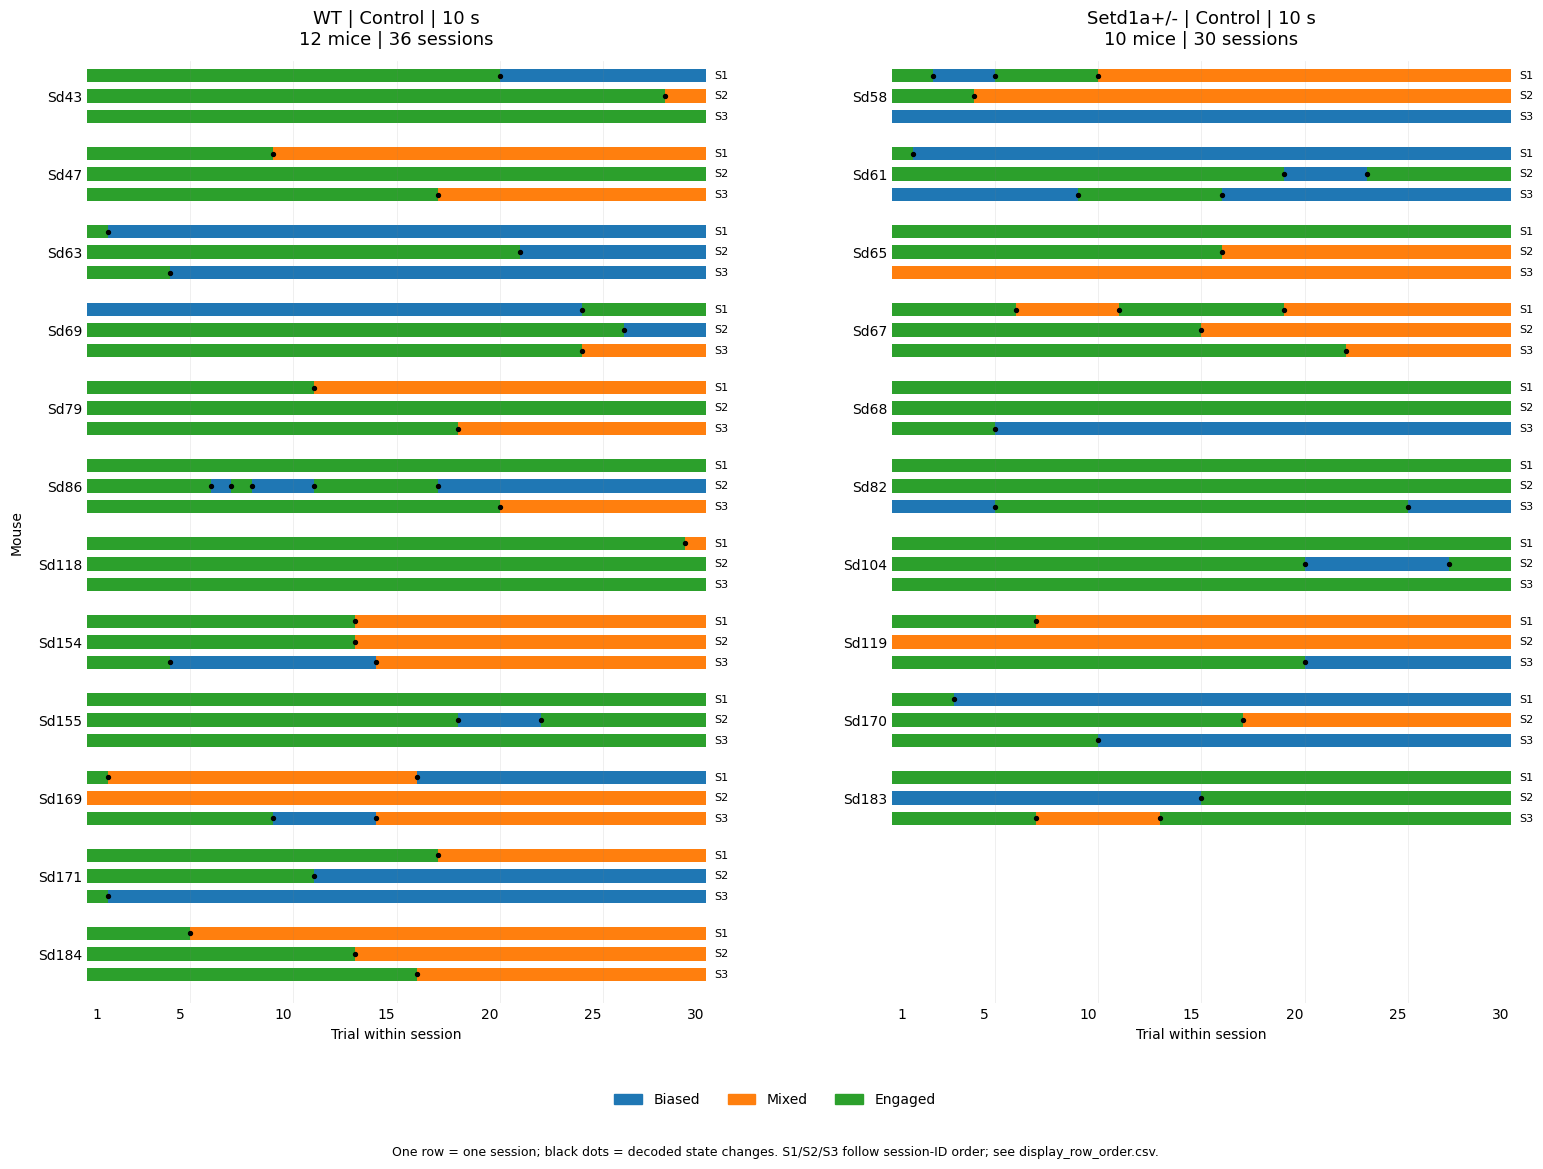

In [8]:
# 앞서 파일을 업로드하고 실행한 런타임에서 그대로 실행하세요.
# 기존 prepare 함수를 보관하여, 이 셀을 반복 실행해도 중복 적용되지 않게 합니다.
if "_original_prepare" not in raster_code:
    raster_code["_original_prepare"] = raster_code["prepare"]

original_prepare = raster_code["_original_prepare"]

def prepare_for_raster(df):
    excluded = (
        df["mouse_id"].eq("Sd169")
        & df["session_id"].eq("Sd169_Testing1-60_258")
    )

    print(
        f"Raster에서 제외: Sd169_Testing1-60_258 "
        f"({int(excluded.sum())} trials; 세션 내 delay 불일치)"
    )
    print("원본 CSV와 저장된 state는 변경하지 않습니다.")

    clean, audit = original_prepare(df.loc[~excluded].copy())

    # 제외 이유를 기존 session_QC.csv에도 기록
    if excluded.any():
        import pandas as pd
        audit = pd.concat([
            audit,
            pd.DataFrame([{
                "mouse_id": "Sd169",
                "session_id": "Sd169_Testing1-60_258",
                "n_trials": int(excluded.sum()),
                "action": "excluded_inconsistent_delay",
                "reason": "First trial: 30 s; remaining 29 trials: 60 s"
            }])
        ], ignore_index=True)

    return clean, audit

raster_code["prepare"] = prepare_for_raster

# 처음 보여주신 그림과 같은 조건
raster_code["DELAY"] = 10
raster_code["CONDITION"] = "Control"

raster_code["main"]()


=== Control | 30s delay ===
Raster에서 제외: Sd169_Testing1-60_258 (30 trials; 세션 내 delay 불일치)
원본 CSV와 저장된 state는 변경하지 않습니다.
All complete sessions: 402; trials: 12060
action
Kept: consecutive trial labels                                                401
Excluded from positional plot: not 30 rows                                      2
Kept: irregular increasing labels; positions reconstructed from file order      1
excluded_inconsistent_delay                                                     1

Saved to: /content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/clear_individual_rasters/20260910_033449_628222


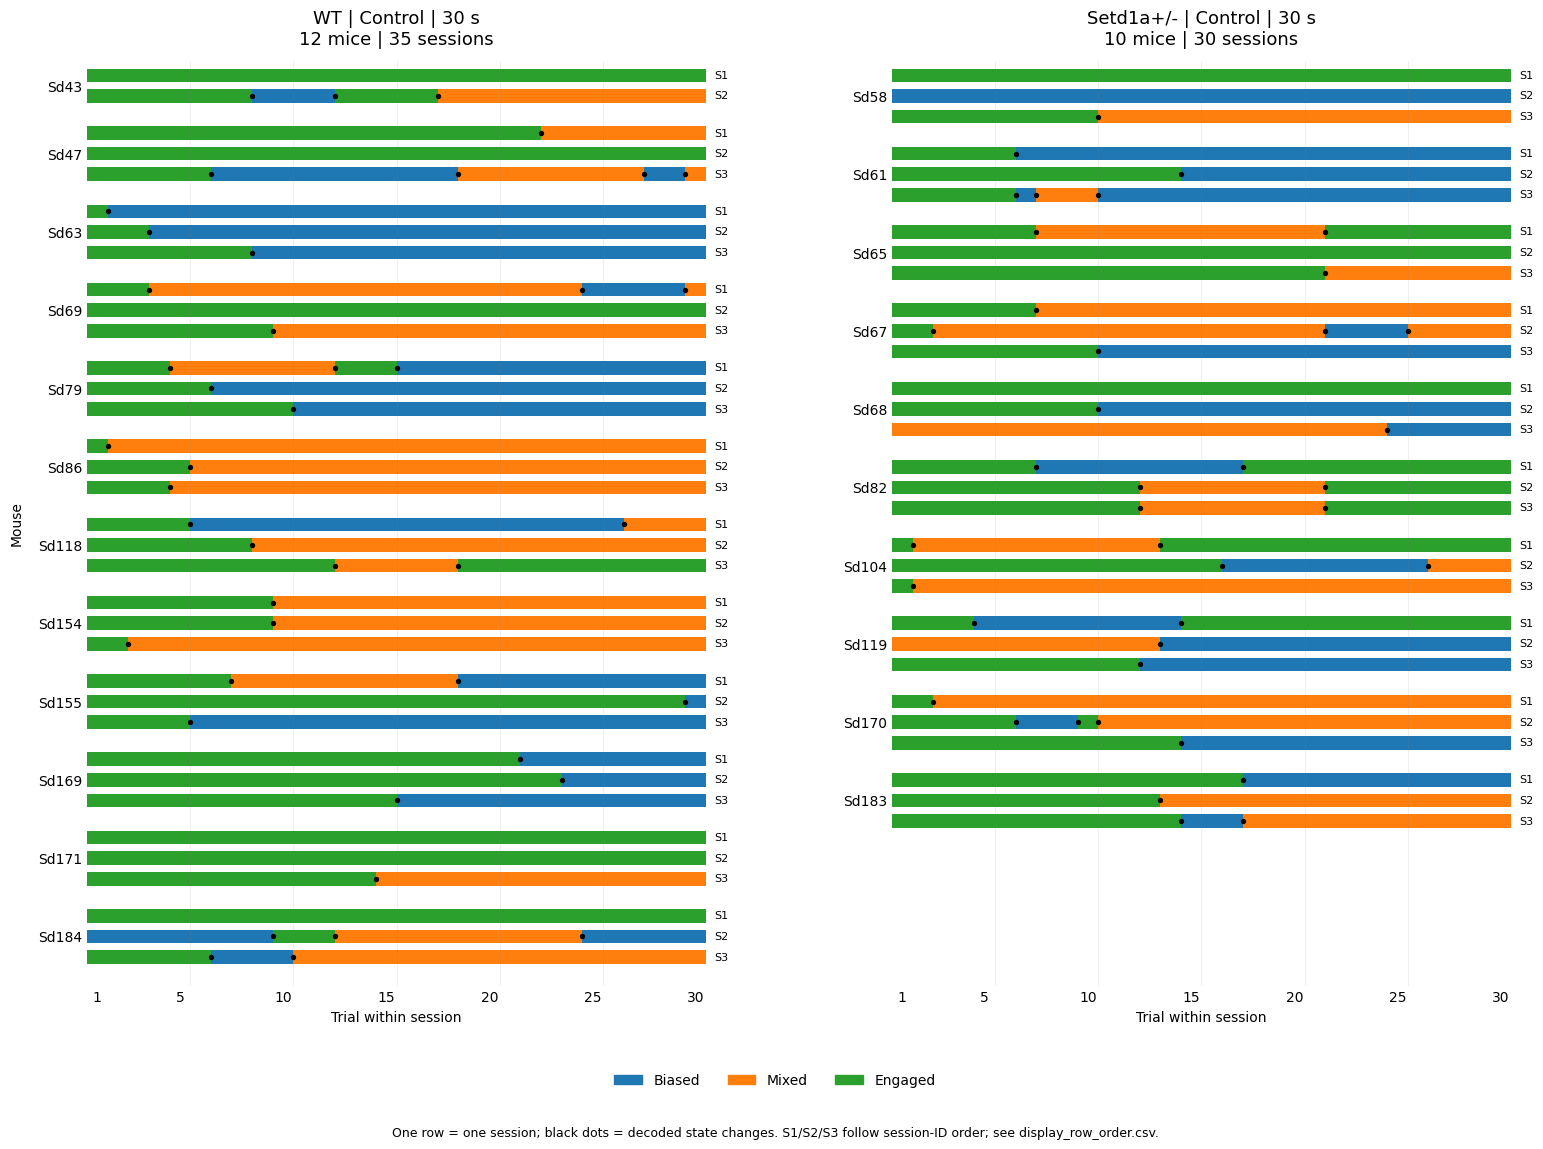


=== Control | 60s delay ===
Raster에서 제외: Sd169_Testing1-60_258 (30 trials; 세션 내 delay 불일치)
원본 CSV와 저장된 state는 변경하지 않습니다.
All complete sessions: 402; trials: 12060
action
Kept: consecutive trial labels                                                401
Excluded from positional plot: not 30 rows                                      2
Kept: irregular increasing labels; positions reconstructed from file order      1
excluded_inconsistent_delay                                                     1

Saved to: /content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/clear_individual_rasters/20260910_033456_708983


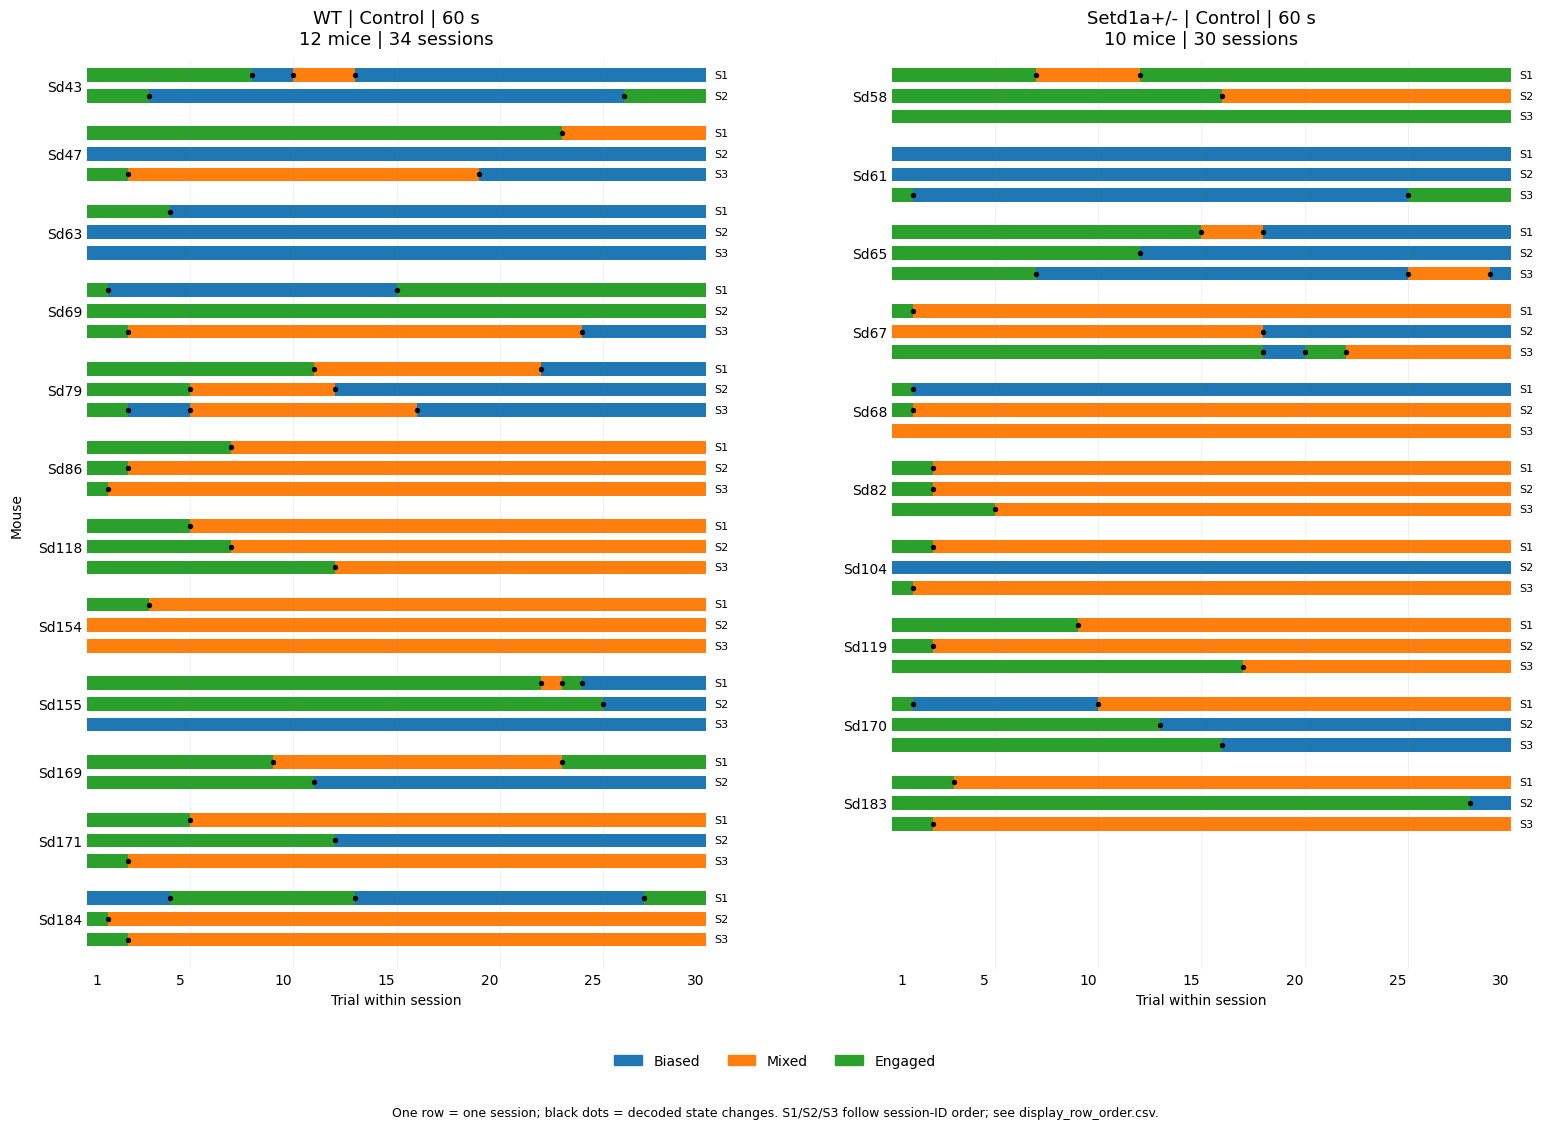

In [9]:
# 앞서 실행한 raster_code와 세션 제외 설정을 그대로 사용
raster_code["CONDITION"] = "Control"

for delay in [30, 60]:
    raster_code["DELAY"] = delay
    print(f"\n=== Control | {delay}s delay ===")
    raster_code["main"]()


=== Control | 30s delay ===
Raster에서 제외: Sd169_Testing1-60_258 (30 trials; 세션 내 delay 불일치)
원본 CSV와 저장된 state는 변경하지 않습니다.
All complete sessions: 402; trials: 12060
action
Kept: consecutive trial labels                                                401
Excluded from positional plot: not 30 rows                                      2
Kept: irregular increasing labels; positions reconstructed from file order      1
excluded_inconsistent_delay                                                     1

Saved to: /content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/clear_individual_rasters/20260910_033526_478144


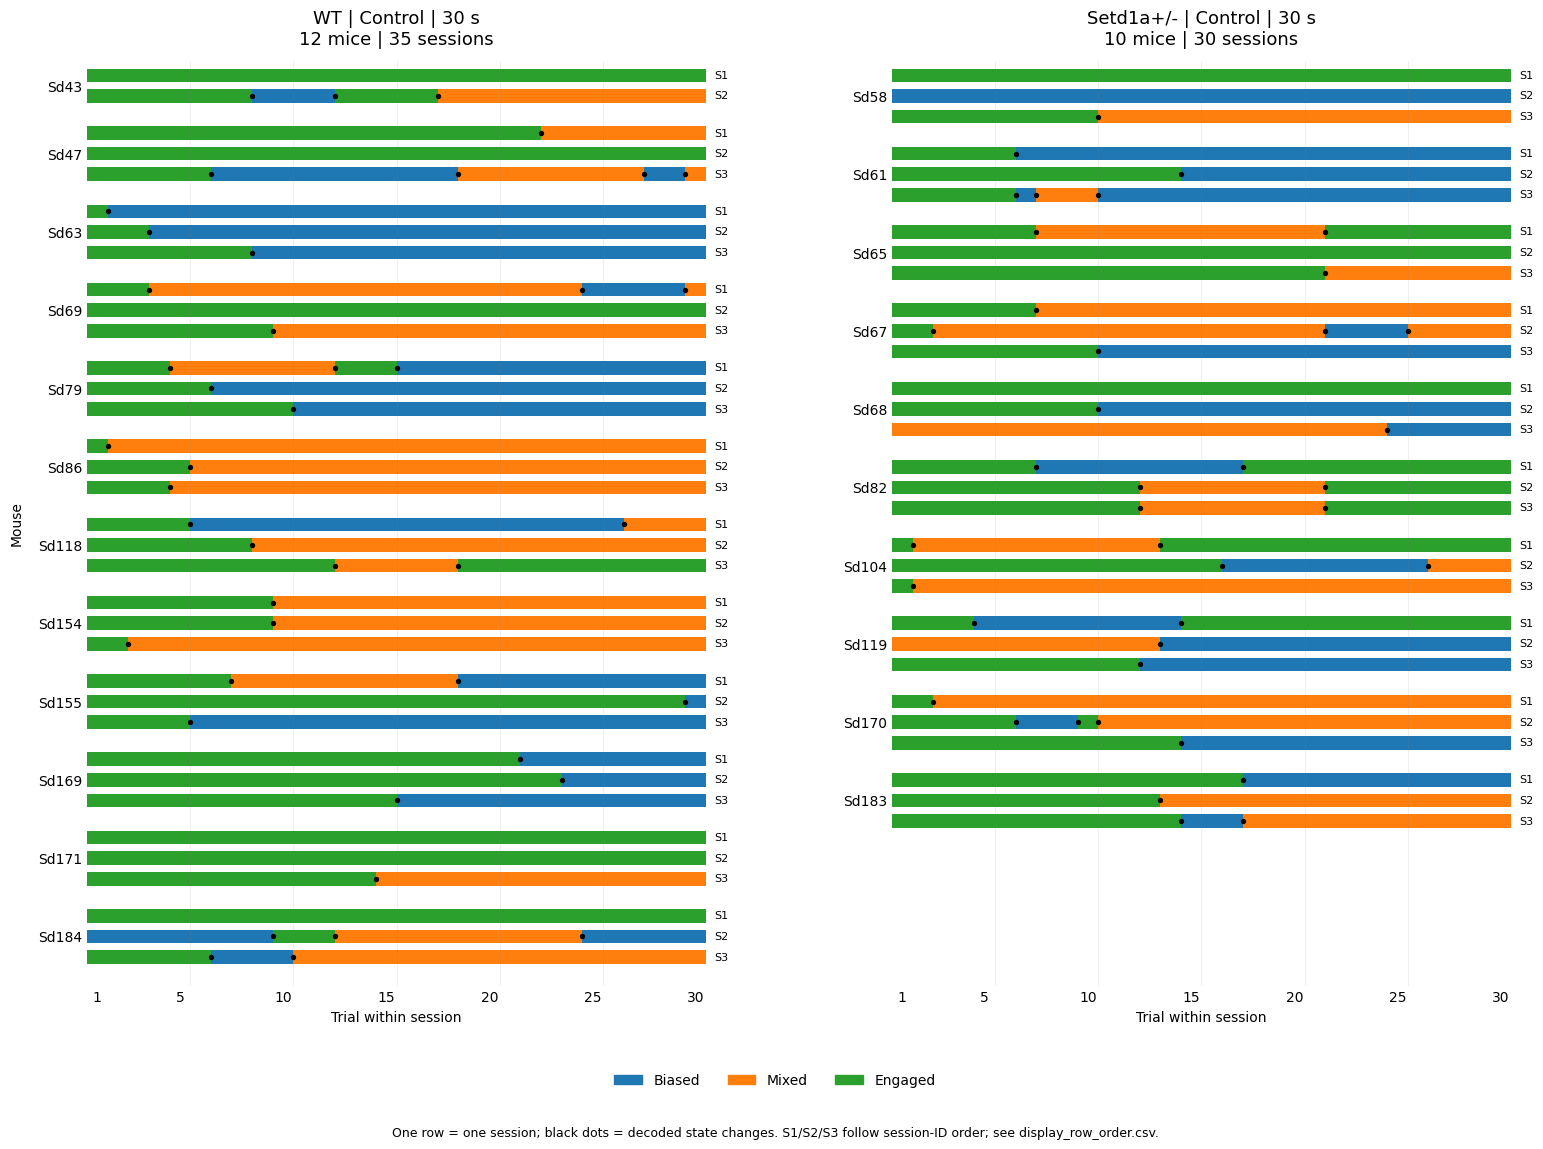


=== Control | 60s delay ===
Raster에서 제외: Sd169_Testing1-60_258 (30 trials; 세션 내 delay 불일치)
원본 CSV와 저장된 state는 변경하지 않습니다.
All complete sessions: 402; trials: 12060
action
Kept: consecutive trial labels                                                401
Excluded from positional plot: not 30 rows                                      2
Kept: irregular increasing labels; positions reconstructed from file order      1
excluded_inconsistent_delay                                                     1

Saved to: /content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/clear_individual_rasters/20260910_033530_967919


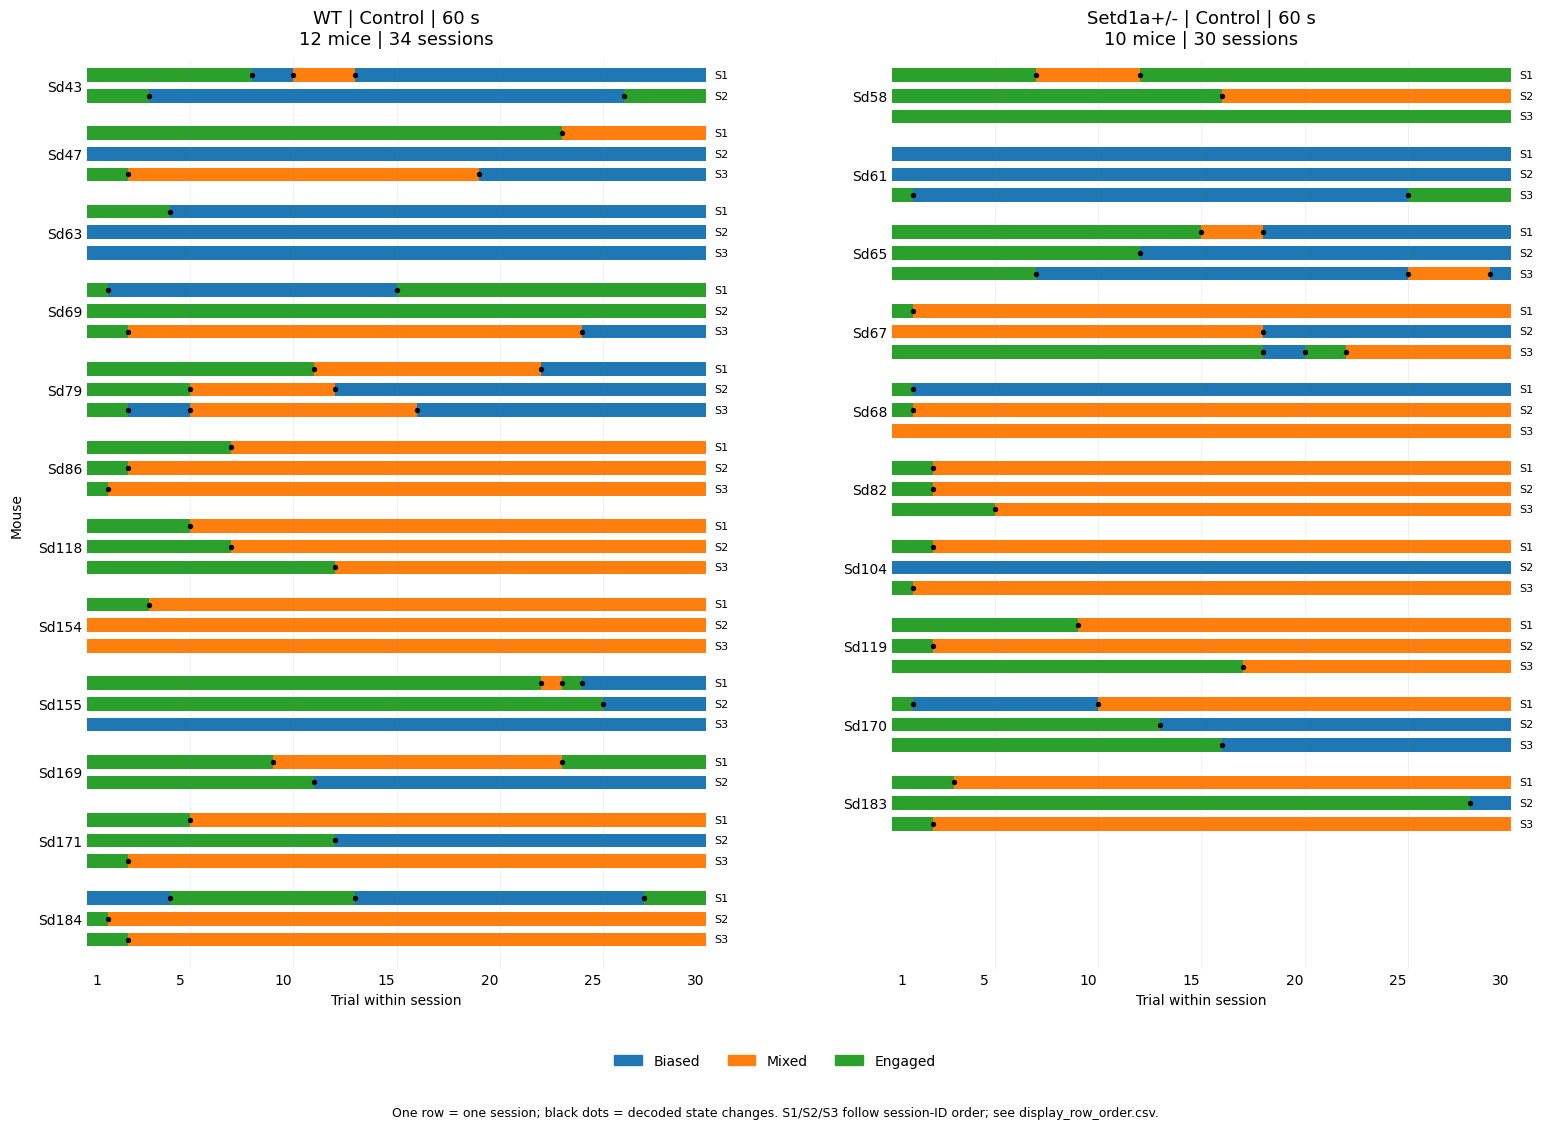


=== Stress | 30s delay ===
Raster에서 제외: Sd169_Testing1-60_258 (30 trials; 세션 내 delay 불일치)
원본 CSV와 저장된 state는 변경하지 않습니다.
All complete sessions: 402; trials: 12060
action
Kept: consecutive trial labels                                                401
Excluded from positional plot: not 30 rows                                      2
Kept: irregular increasing labels; positions reconstructed from file order      1
excluded_inconsistent_delay                                                     1

Saved to: /content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/clear_individual_rasters/20260910_033536_890701


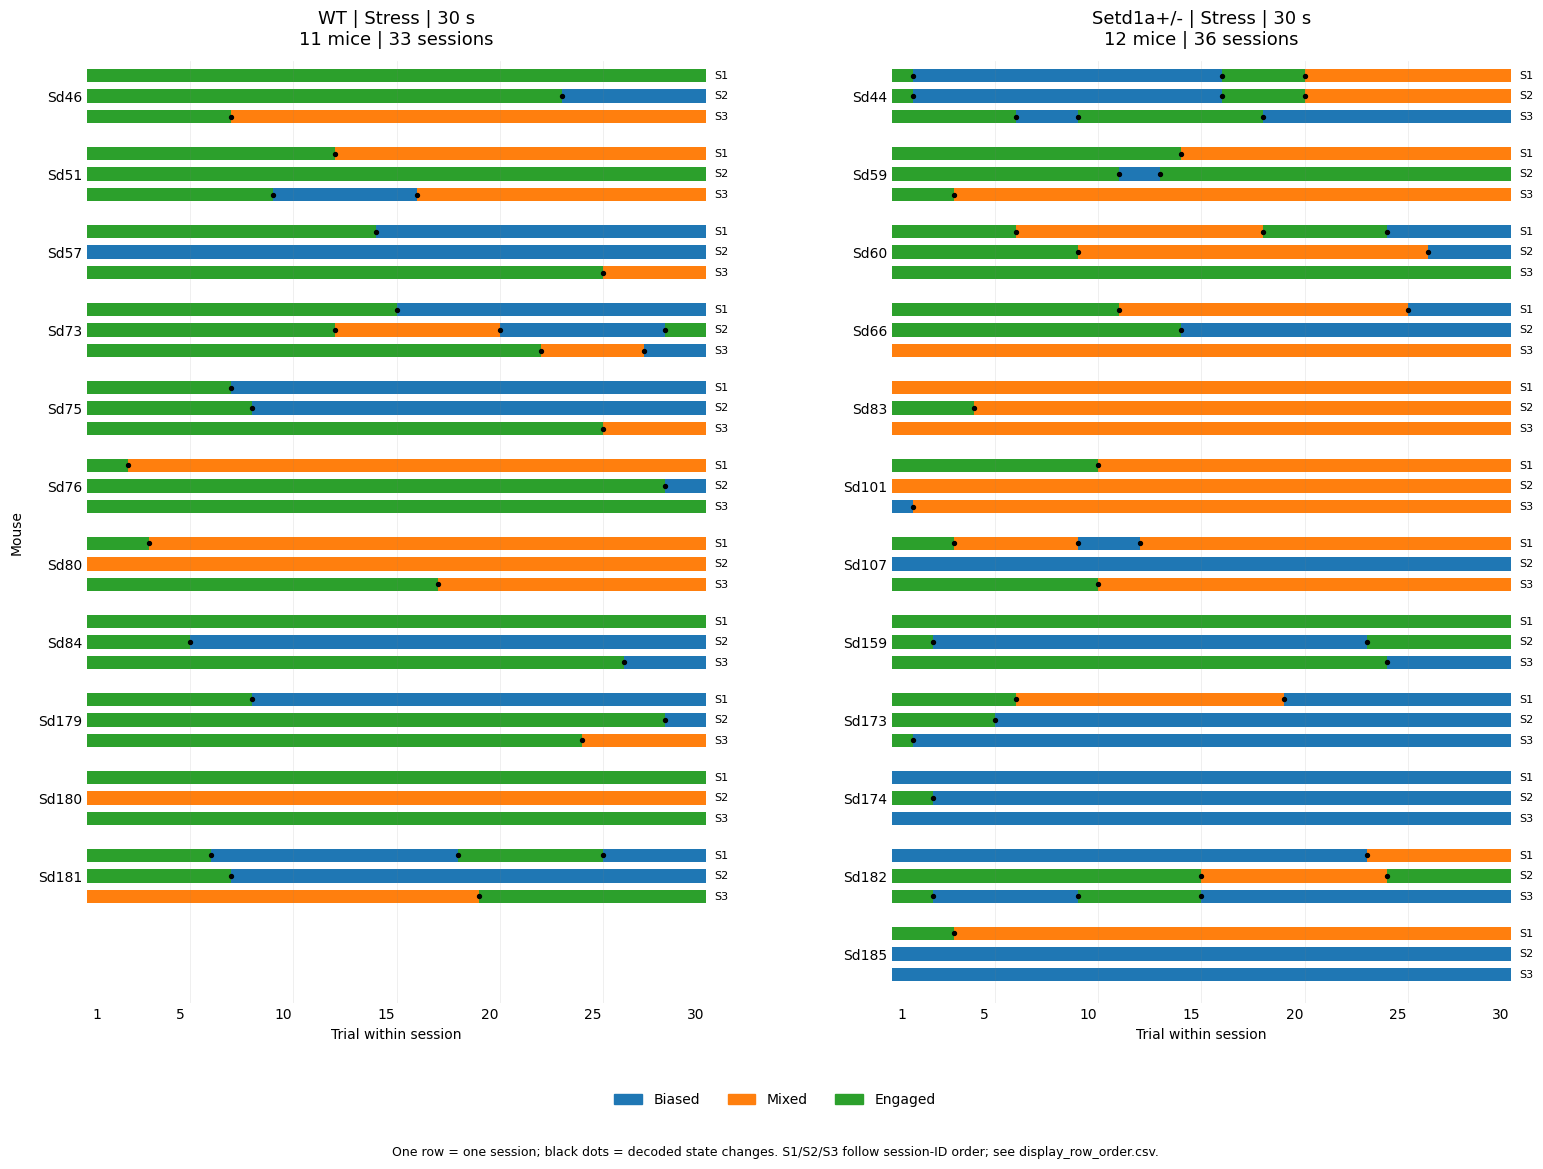


=== Stress | 60s delay ===
Raster에서 제외: Sd169_Testing1-60_258 (30 trials; 세션 내 delay 불일치)
원본 CSV와 저장된 state는 변경하지 않습니다.
All complete sessions: 402; trials: 12060
action
Kept: consecutive trial labels                                                401
Excluded from positional plot: not 30 rows                                      2
Kept: irregular increasing labels; positions reconstructed from file order      1
excluded_inconsistent_delay                                                     1

Saved to: /content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/clear_individual_rasters/20260910_033541_729924


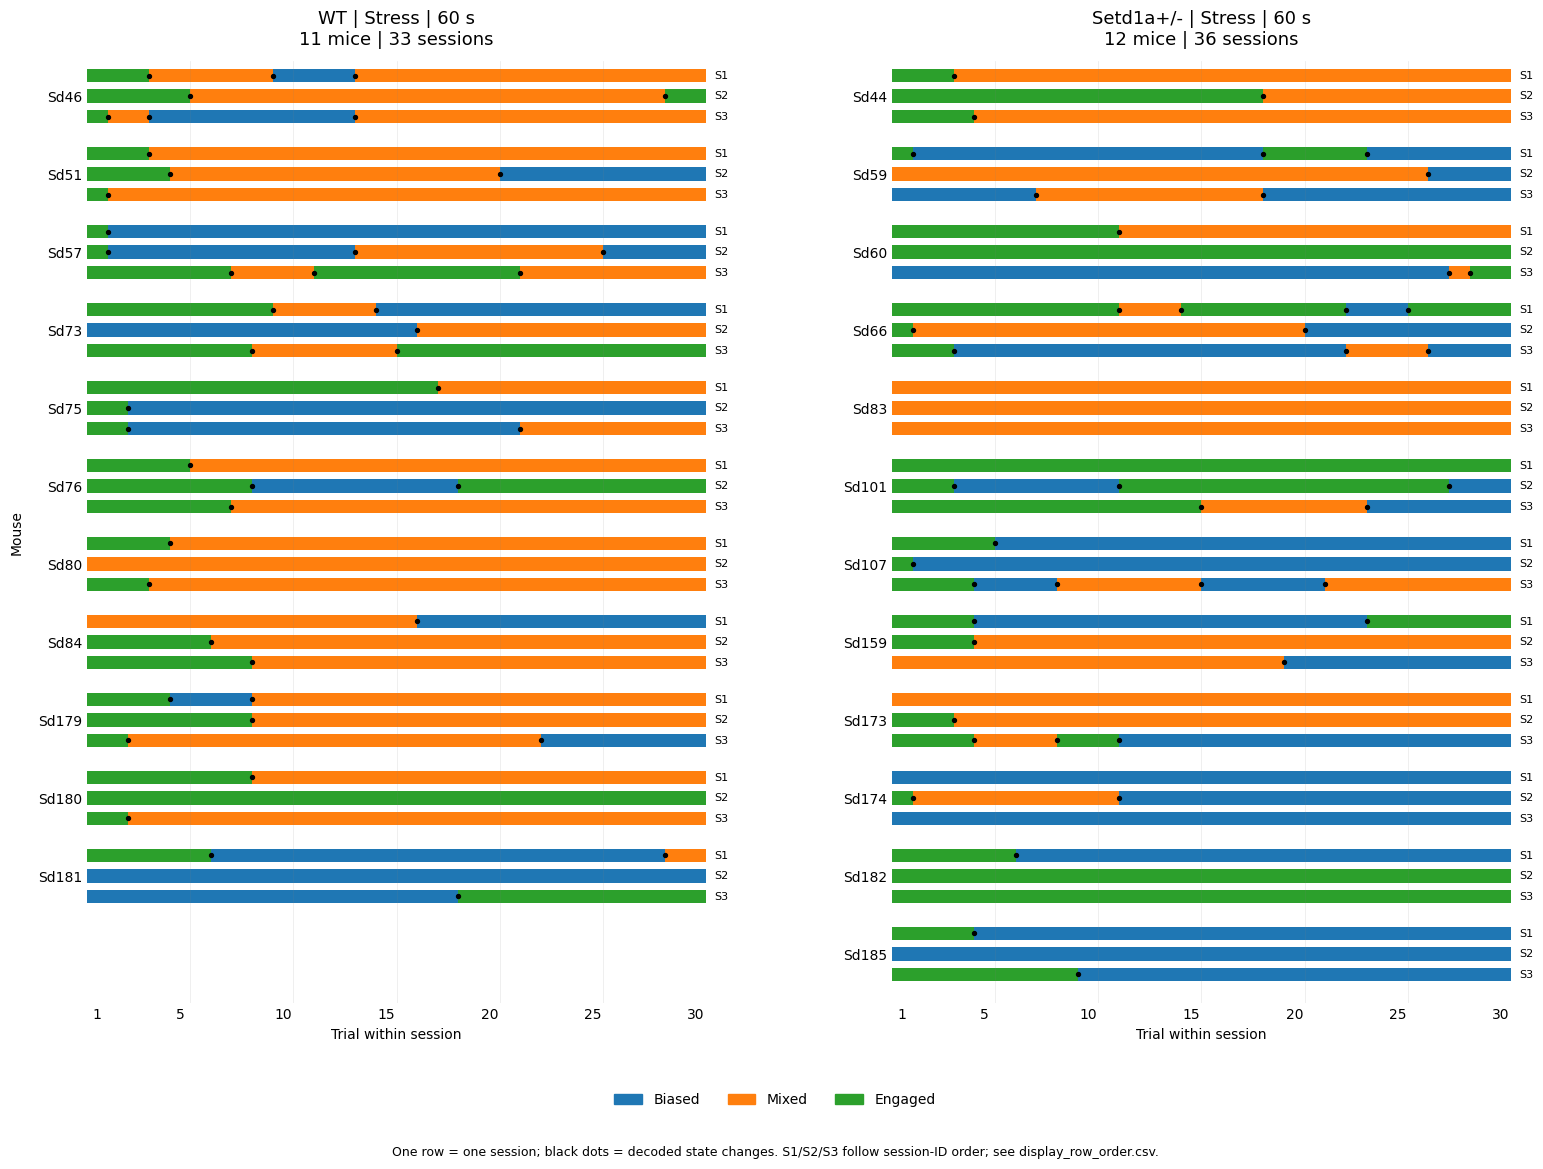

In [10]:
for condition in ["Control", "Stress"]:
    for delay in [30, 60]:
        raster_code["CONDITION"] = condition
        raster_code["DELAY"] = delay
        print(f"\n=== {condition} | {delay}s delay ===")
        raster_code["main"]()


=== Control | 10s | WT & Setd1a+/- ===
Raster에서 제외: Sd169_Testing1-60_258 (30 trials; 세션 내 delay 불일치)
원본 CSV와 저장된 state는 변경하지 않습니다.
All complete sessions: 402; trials: 12060
action
Kept: consecutive trial labels                                                401
Excluded from positional plot: not 30 rows                                      2
Kept: irregular increasing labels; positions reconstructed from file order      1
excluded_inconsistent_delay                                                     1

Saved to: /content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/clear_individual_rasters/20260910_033624_624463


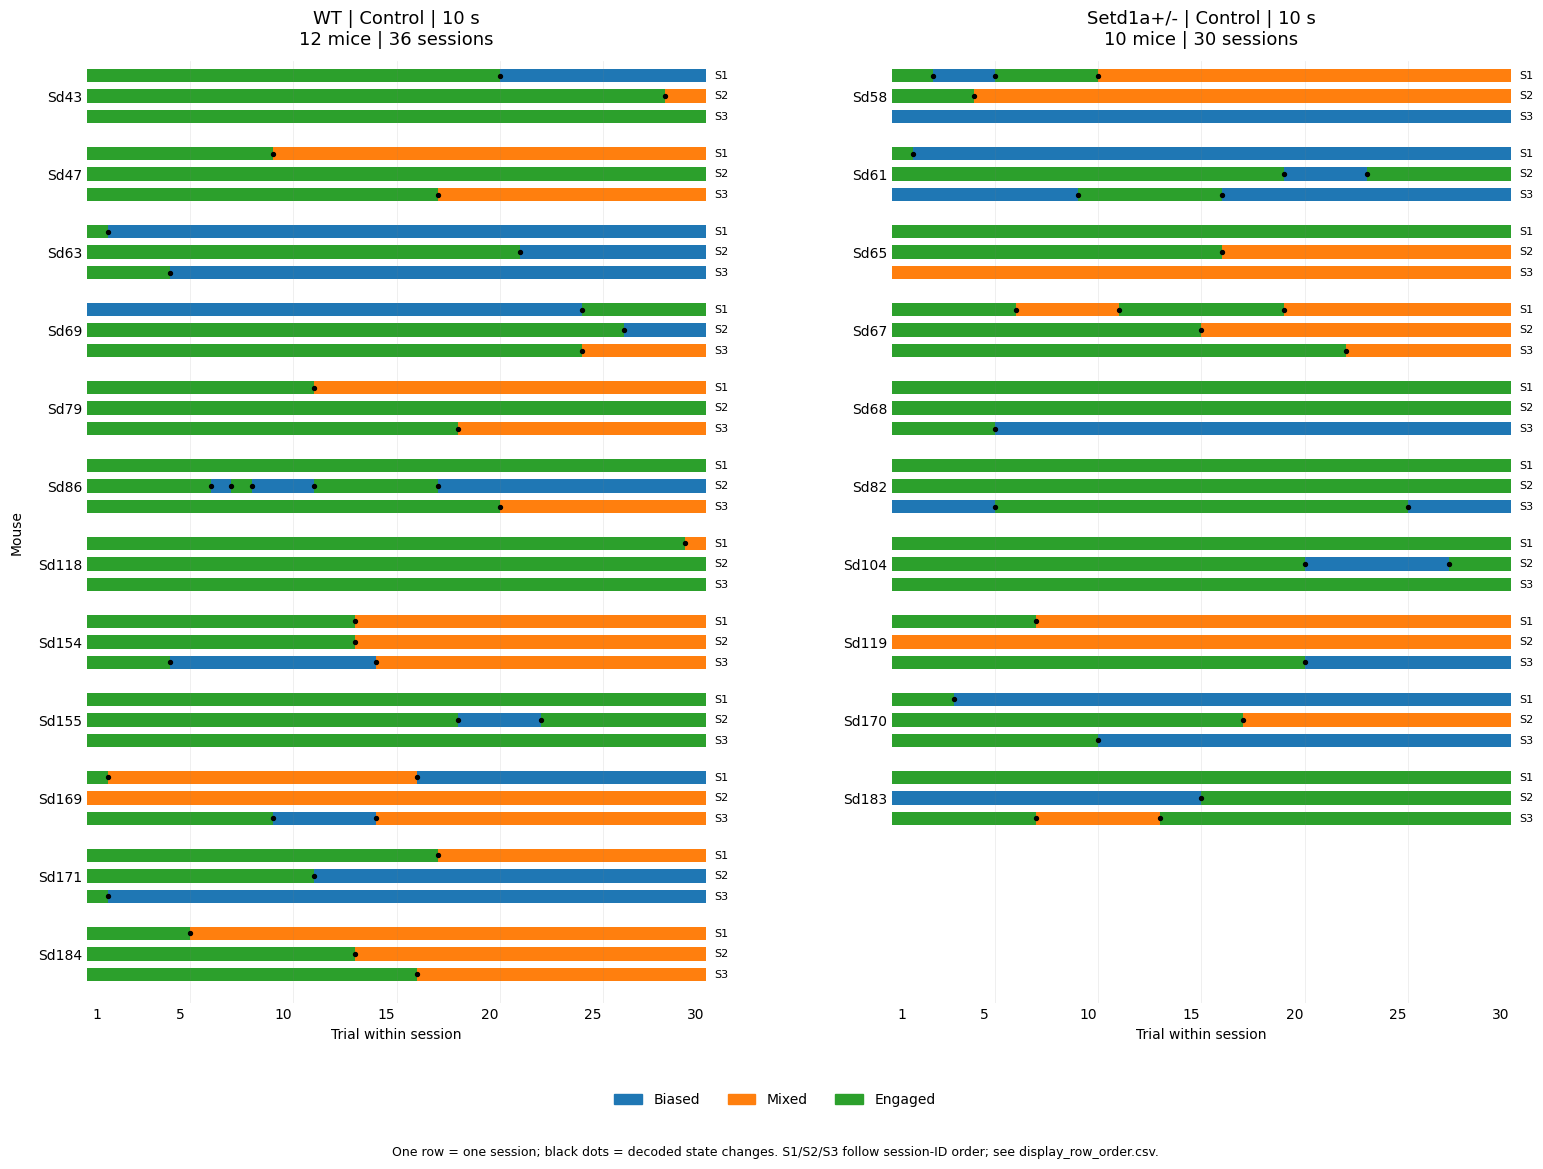


=== Control | 30s | WT & Setd1a+/- ===
Raster에서 제외: Sd169_Testing1-60_258 (30 trials; 세션 내 delay 불일치)
원본 CSV와 저장된 state는 변경하지 않습니다.
All complete sessions: 402; trials: 12060
action
Kept: consecutive trial labels                                                401
Excluded from positional plot: not 30 rows                                      2
Kept: irregular increasing labels; positions reconstructed from file order      1
excluded_inconsistent_delay                                                     1

Saved to: /content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/clear_individual_rasters/20260910_033631_258881


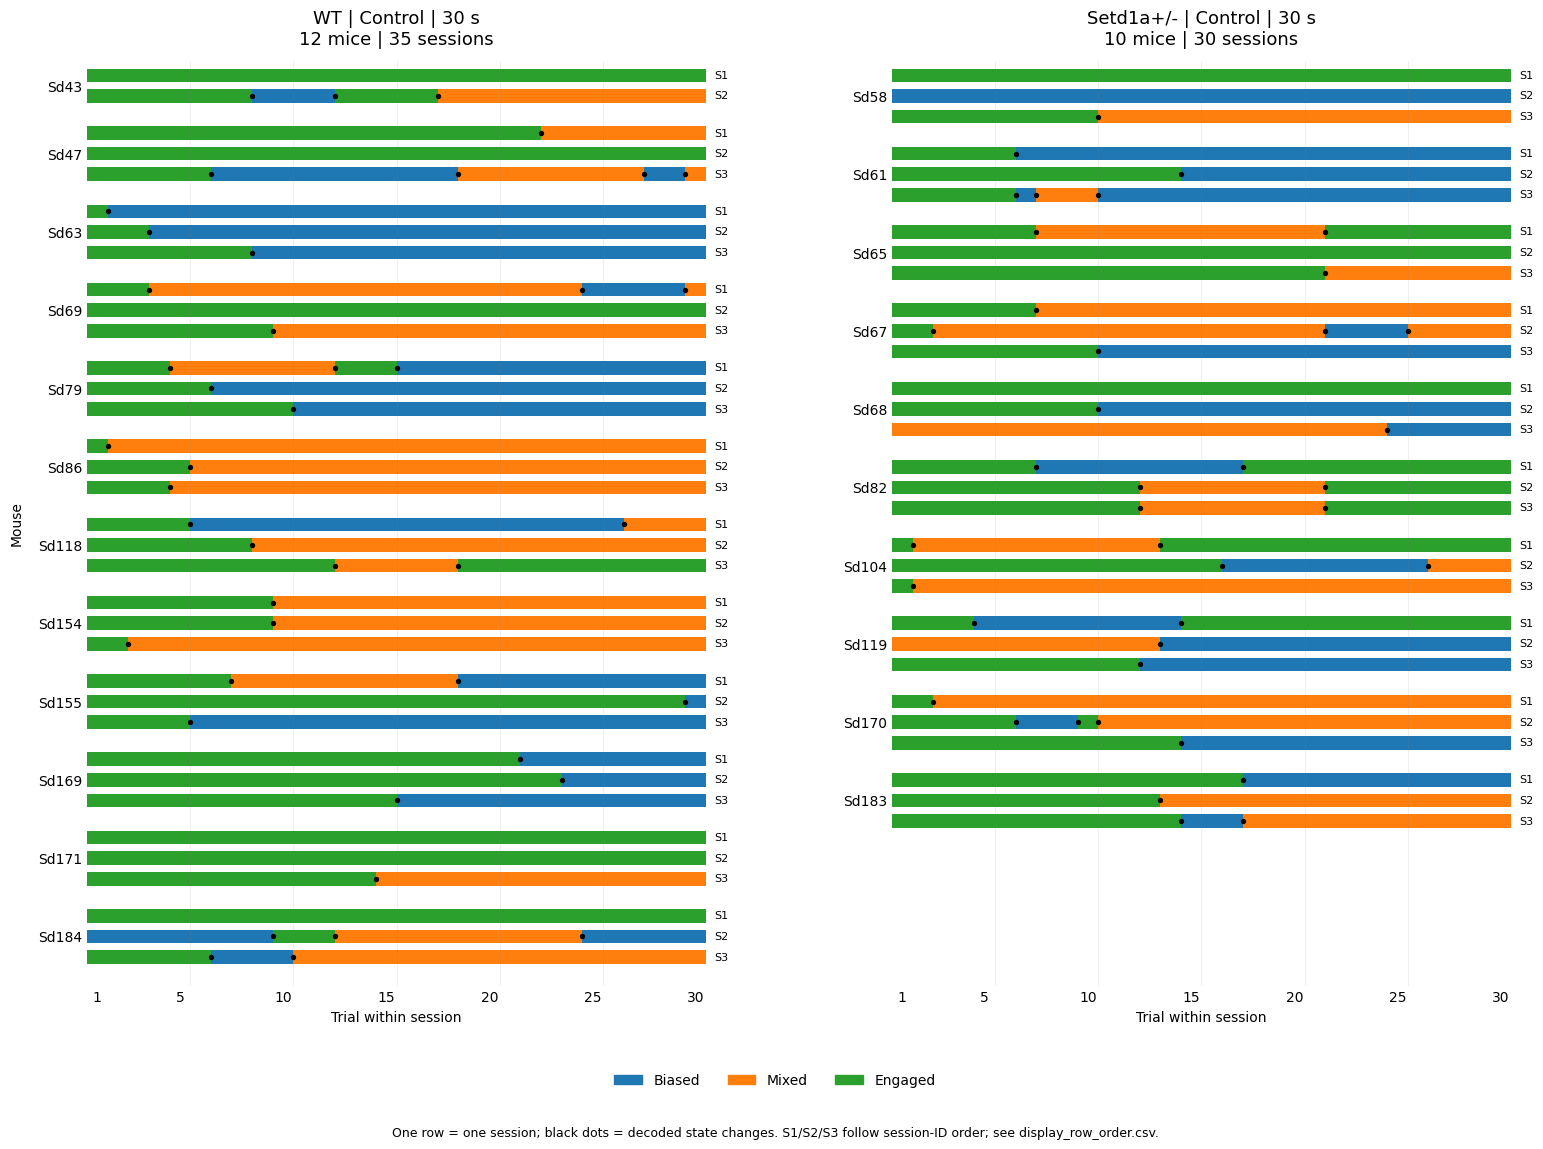


=== Control | 60s | WT & Setd1a+/- ===
Raster에서 제외: Sd169_Testing1-60_258 (30 trials; 세션 내 delay 불일치)
원본 CSV와 저장된 state는 변경하지 않습니다.
All complete sessions: 402; trials: 12060
action
Kept: consecutive trial labels                                                401
Excluded from positional plot: not 30 rows                                      2
Kept: irregular increasing labels; positions reconstructed from file order      1
excluded_inconsistent_delay                                                     1

Saved to: /content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/clear_individual_rasters/20260910_033635_765065


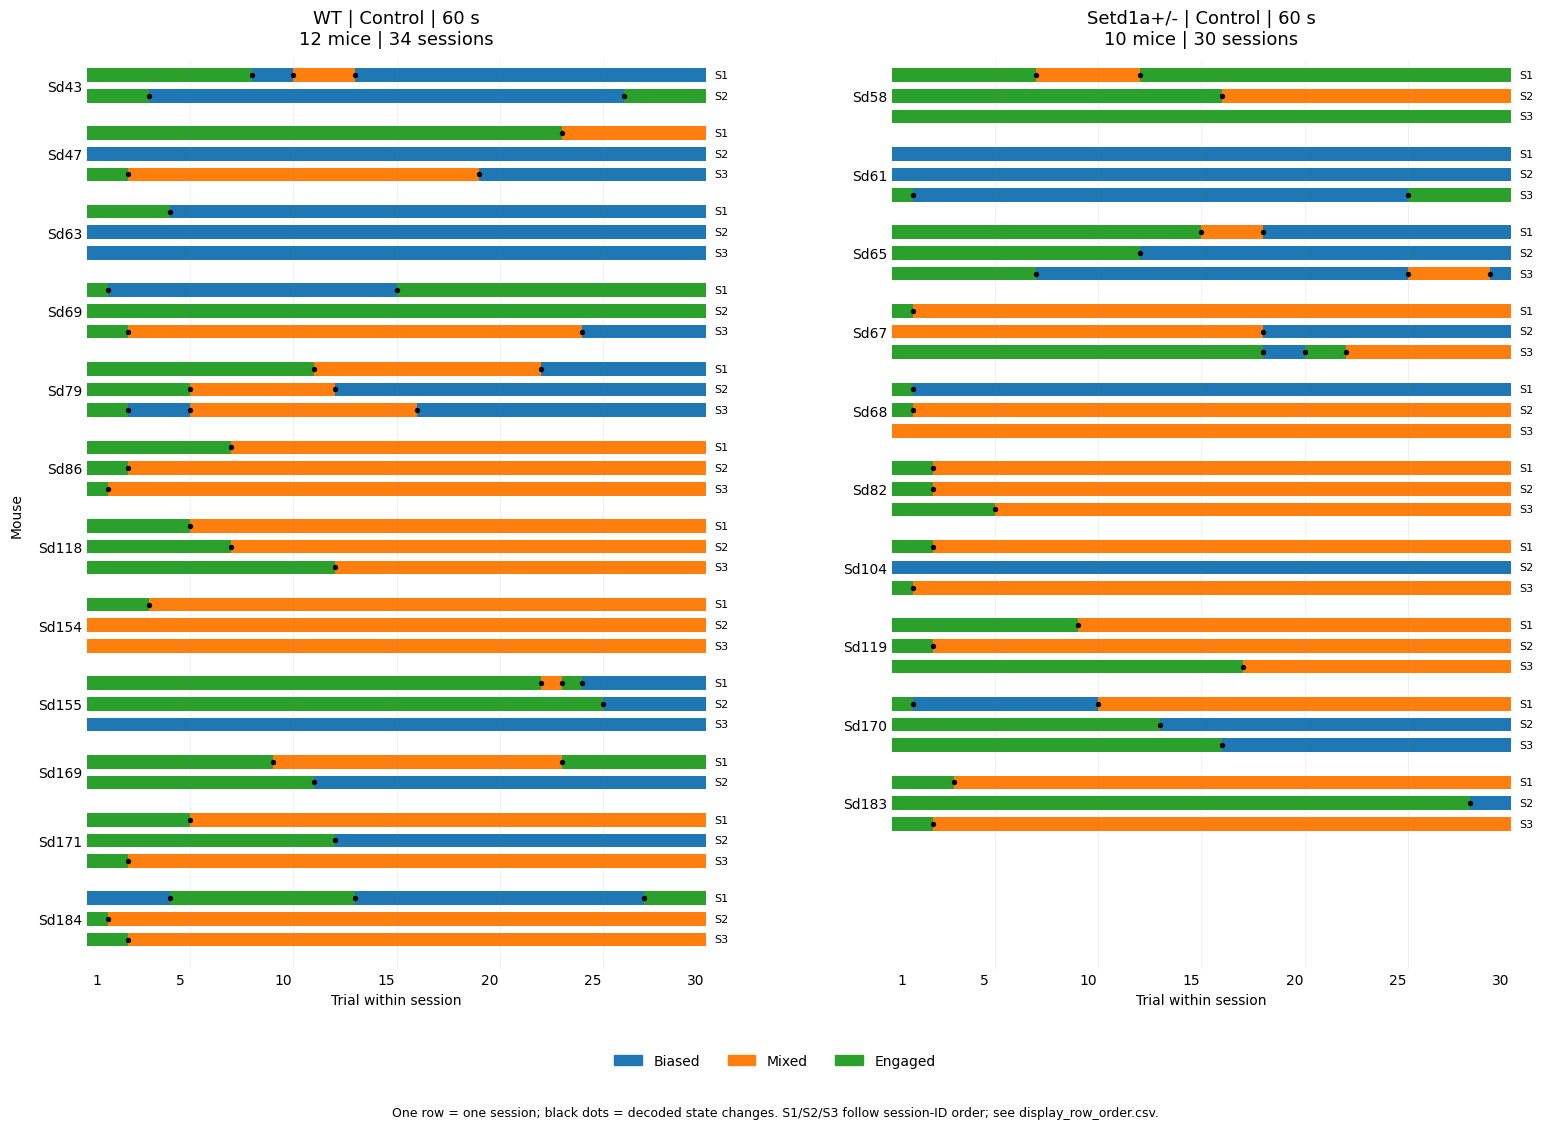


=== Stress | 10s | WT & Setd1a+/- ===
Raster에서 제외: Sd169_Testing1-60_258 (30 trials; 세션 내 delay 불일치)
원본 CSV와 저장된 state는 변경하지 않습니다.
All complete sessions: 402; trials: 12060
action
Kept: consecutive trial labels                                                401
Excluded from positional plot: not 30 rows                                      2
Kept: irregular increasing labels; positions reconstructed from file order      1
excluded_inconsistent_delay                                                     1

Saved to: /content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/clear_individual_rasters/20260910_033640_419134


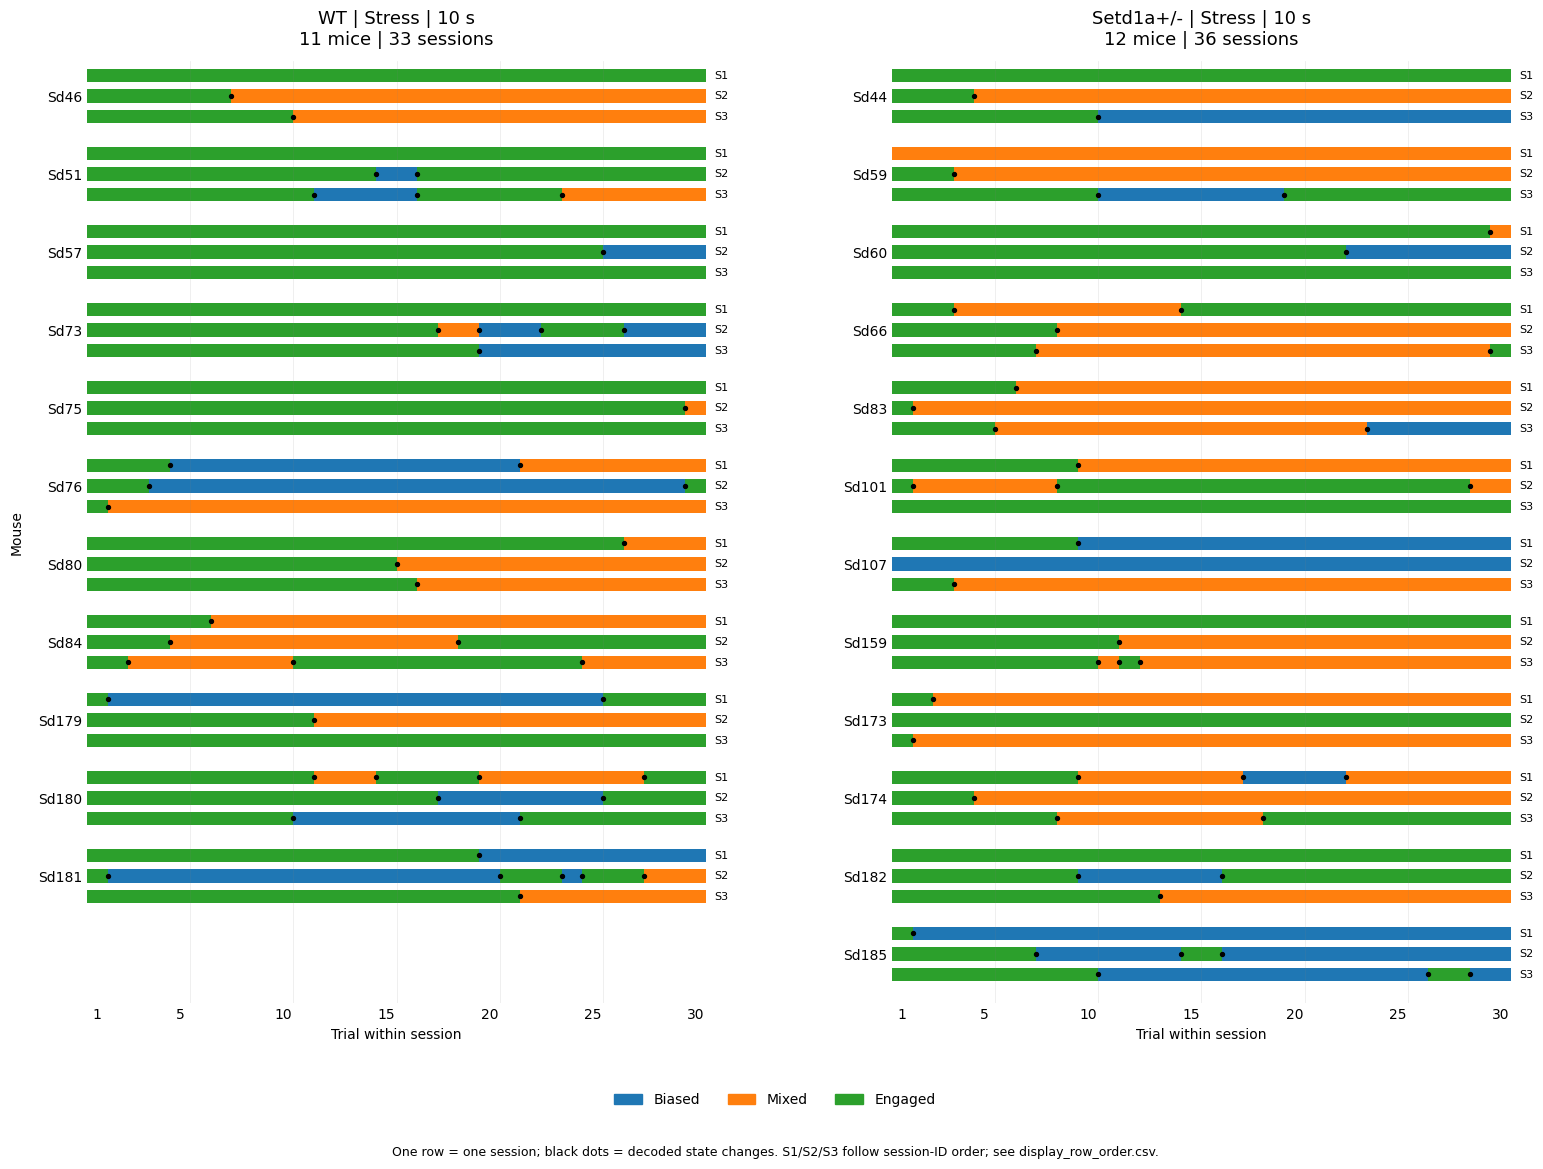


=== Stress | 30s | WT & Setd1a+/- ===
Raster에서 제외: Sd169_Testing1-60_258 (30 trials; 세션 내 delay 불일치)
원본 CSV와 저장된 state는 변경하지 않습니다.
All complete sessions: 402; trials: 12060
action
Kept: consecutive trial labels                                                401
Excluded from positional plot: not 30 rows                                      2
Kept: irregular increasing labels; positions reconstructed from file order      1
excluded_inconsistent_delay                                                     1

Saved to: /content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/clear_individual_rasters/20260910_033646_670418


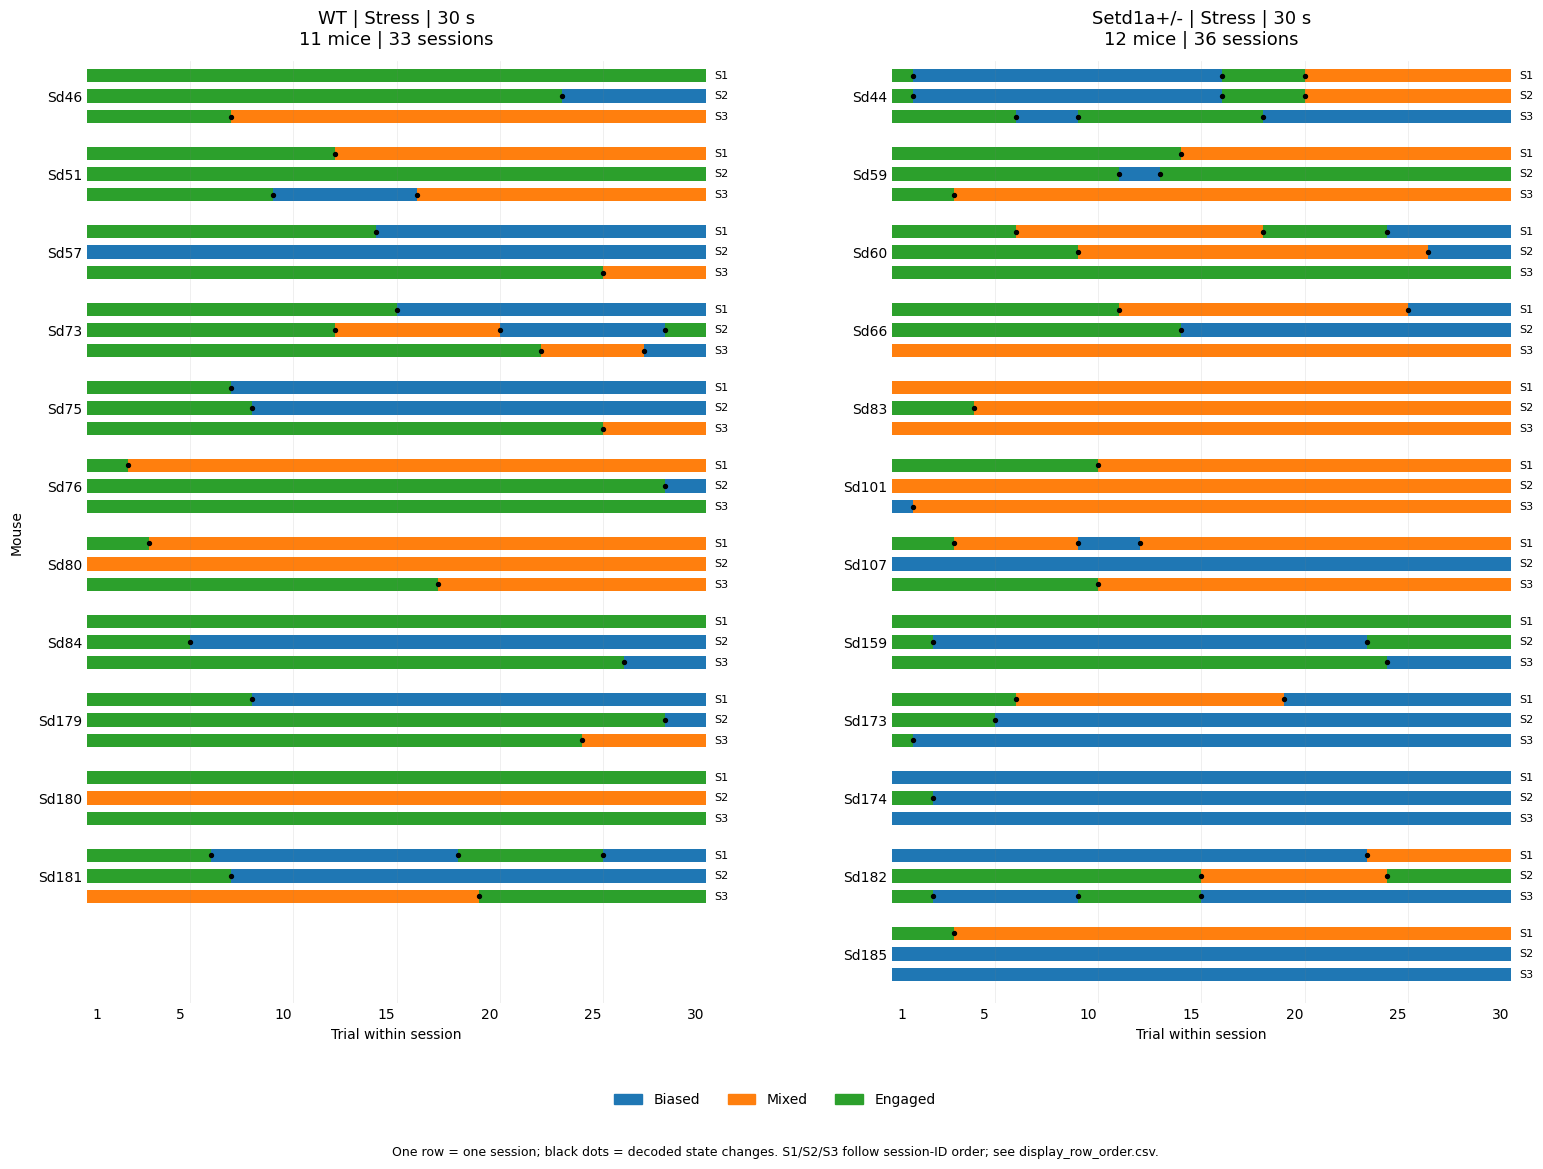


=== Stress | 60s | WT & Setd1a+/- ===
Raster에서 제외: Sd169_Testing1-60_258 (30 trials; 세션 내 delay 불일치)
원본 CSV와 저장된 state는 변경하지 않습니다.
All complete sessions: 402; trials: 12060
action
Kept: consecutive trial labels                                                401
Excluded from positional plot: not 30 rows                                      2
Kept: irregular increasing labels; positions reconstructed from file order      1
excluded_inconsistent_delay                                                     1

Saved to: /content/drive/MyDrive/DNMS_GLMHMM_WTcontrol_FINAL/clear_individual_rasters/20260910_033651_413810


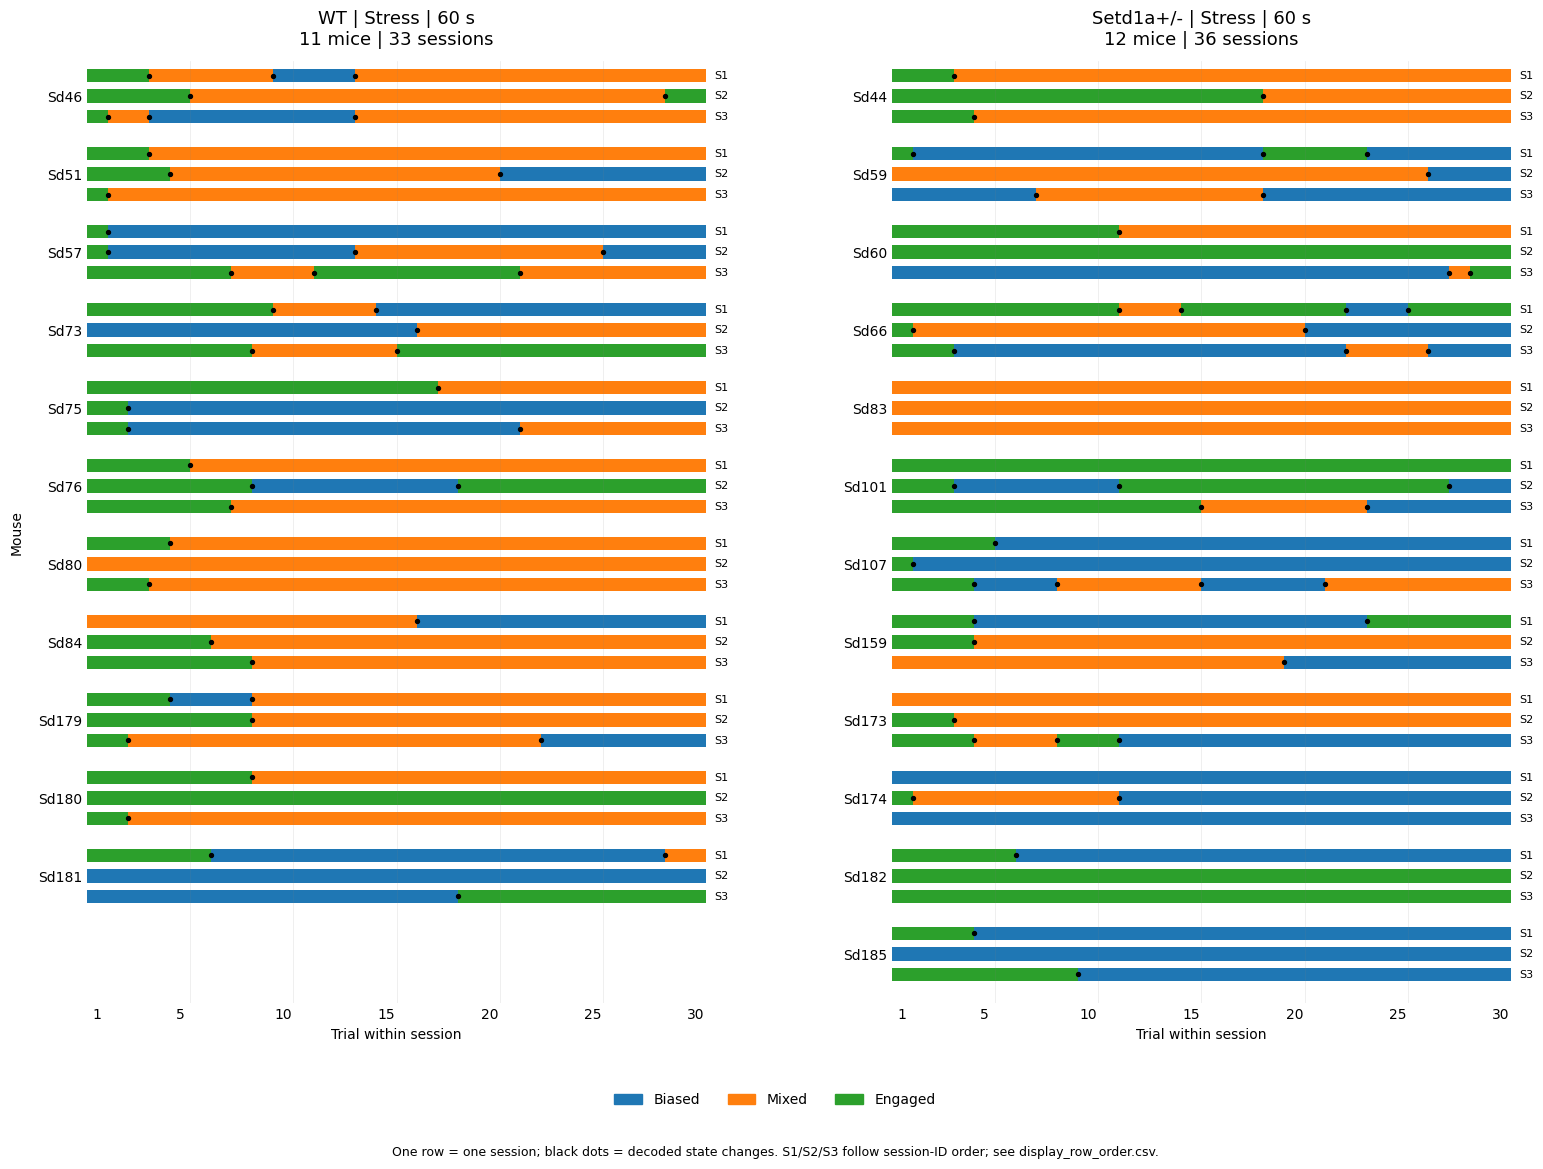

In [11]:
for condition in ["Control", "Stress"]:
    for delay in [10, 30, 60]:
        raster_code["CONDITION"] = condition
        raster_code["DELAY"] = delay
        print(f"\n=== {condition} | {delay}s | WT & Setd1a+/- ===")
        raster_code["main"]()